# Deep Learning PR 2

## Task 1: Data Loading, Cleaning & Exploratory Data Analysis

### Dataset
Adult Income Dataset (Census Income)

### Objective
The objective of this project is to predict whether an individual's annual income is:

- `<=50K` → Class 0
- `>50K` → Class 1

In this task, we will:
1. Load and inspect the dataset
2. Clean missing values
3. Remove redundant/non-predictive columns
4. Encode the target variable
5. Perform Exploratory Data Analysis (EDA)
6. One-hot encode categorical variables
7. Standardize numerical features
8. Create a stratified 80/20 train-test split

## Task 1.1 — Load and Inspect the Dataset

First, we import the required libraries and load `adult.csv`.

The PDF specifies that the dataset should contain approximately 48,842 records and 15 columns, including 14 input features and 1 target column.

We will inspect:
- Dataset shape
- Data types
- First five records

# Import required libraries


In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Seaborn style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


# Load the Adult Income dataset


In [3]:
# Load the Adult Income dataset

df = pd.read_csv("adult.csv")

print("Dataset loaded successfully!")
print()
print("Dataset Shape:", df.shape)

Dataset loaded successfully!

Dataset Shape: (48842, 15)


# Display data types


In [4]:
# Display data types

print("Data Types:")
print("=" * 60)

print(df.dtypes)

Data Types:
age                int64
workclass            str
fnlwgt             int64
education            str
educational-num    int64
marital-status       str
occupation           str
relationship         str
race                 str
gender               str
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country       str
income               str
dtype: object


# Display first five rows


In [5]:
# Display first five rows

print("First 5 Rows:")
print("=" * 60)

display(df.head())

First 5 Rows:


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


### Observation

The dataset contains both numerical and categorical variables.

Numerical features include:
- age
- fnlwgt
- education_num
- capital_gain
- capital_loss
- hours_per_week

Categorical features include:
- workclass
- education
- marital.status
- occupation
- relationship
- race
- sex
- native.country

The target variable is `income`.

The dataset contains missing values represented by `?`, which must be handled before model training.

# Check all column names


In [6]:
# Check all column names

print("Dataset Columns:")
print("=" * 60)

for i, column in enumerate(df.columns, start=1):
    print(f"{i:2d}. {column}")

Dataset Columns:
 1. age
 2. workclass
 3. fnlwgt
 4. education
 5. educational-num
 6. marital-status
 7. occupation
 8. relationship
 9. race
10. gender
11. capital-gain
12. capital-loss
13. hours-per-week
14. native-country
15. income


### Remove Extra Whitespace from Categorical Columns

The categorical columns may contain unwanted leading or trailing spaces.

We will remove these spaces from every object column using:

`str.strip()`

This makes categorical values consistent before replacing missing values.

# Strip whitespace 


In [7]:
# Strip whitespace from all object/string columns

object_columns = df.select_dtypes(include="object").columns

for col in object_columns:
    df[col] = df[col].str.strip()

print("Whitespace removed successfully from all object columns.")

Whitespace removed successfully from all object columns.


C:\Users\hp\AppData\Local\Temp\ipykernel_15792\3620009001.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_columns = df.select_dtypes(include="object").columns


## Task 1.2 — Handle Missing Values

In the Adult Income dataset, missing values are represented by `?`.

We will:

1. Replace `?` with `NaN`
2. Check the number of missing values
3. Drop rows containing missing values

The PDF specifies dropping rows rather than imputing them.

### Why drop instead of impute?

The missing values occur mainly in categorical columns such as:

- `workclass`
- `occupation`
- `native.country`

These columns contain many categories. Mode imputation could artificially increase the frequency of the most common category and distort the original distribution.

Therefore, for this assignment, rows containing missing values are removed.

# Replace '?' with NaN


In [8]:
# Replace '?' with NaN

df.replace("?", np.nan, inplace=True)

print("Replaced '?' with NaN.")

Replaced '?' with NaN.


# Check missing values in every column


In [9]:
# Check missing values in every column

missing_values = df.isnull().sum()

print("Missing Values Before Removing Rows:")
print("=" * 60)

display(missing_values[missing_values > 0])

Missing Values Before Removing Rows:


workclass         2799
occupation        2809
native-country     857
dtype: int64

# Calculate total number of missing values


In [10]:
# Calculate total number of missing values

total_missing = df.isnull().sum().sum()

print("Total Missing Values:", total_missing)

Total Missing Values: 6465


# Display percentage of missing values


In [11]:
# Display percentage of missing values

missing_percentage = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": missing_percentage.round(2)
})

display(missing_table[missing_table["Missing Count"] > 0])

,Missing Count,Missing Percentage
native-country,857,1.75
occupation,2809,5.75
workclass,2799,5.73


# Store the number of rows before dropping missing values


In [12]:
# Store the number of rows before dropping missing values

rows_before = df.shape[0]

# Drop rows containing any missing value

df.dropna(inplace=True)

# Store the number of rows after dropping missing values

rows_after = df.shape[0]

rows_removed = rows_before - rows_after

print("Rows before removing missing values :", rows_before)
print("Rows after removing missing values  :", rows_after)
print("Rows removed                       :", rows_removed)
print("New dataset shape                  :", df.shape)

Rows before removing missing values : 48842
Rows after removing missing values  : 45222
Rows removed                       : 3620
New dataset shape                  : (45222, 15)


# Verify that no missing values remain


In [13]:
# Verify that no missing values remain

print("Missing values after cleaning:")
print("=" * 60)

print(df.isnull().sum().sum())

Missing values after cleaning:
0


### Missing Value Cleaning — Conclusion

After replacing `?` with `NaN`, rows containing missing values were removed.

This follows the PR 2 requirement because the missing values are concentrated in categorical variables with many categories. Mode imputation could over-represent the most frequent category and change the original data distribution.

The cleaned dataset is now ready for feature selection and exploratory analysis.

## Task 1.3 — Drop Redundant Columns

We will remove two columns:

### `fnlwgt`
`fnlwgt` is the census sampling weight. It is not considered a predictive demographic feature for this project.

### `education`
The text-based education column is redundant because `education.num` already provides a numerical representation of education level.

Therefore:
- Drop `fnlwgt`
- Drop `education`
- Keep `education.num`

# Display shape before dropping columns


In [14]:
# Display shape before dropping columns

print("Shape before dropping columns:", df.shape)

print("\nColumns before dropping:")
print(df.columns.tolist())

Shape before dropping columns: (45222, 15)

Columns before dropping:
['age', 'workclass', 'fnlwgt', 'education', 'educational-num', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


# Drop redundant columns


In [15]:
# Drop redundant/non-predictive columns

df.drop(
    columns=["fnlwgt", "education"],
    inplace=True
)

print("Columns dropped successfully!")
print()
print("Shape after dropping columns:", df.shape)

Columns dropped successfully!

Shape after dropping columns: (45222, 13)


# Display remaining columns


In [16]:
# Display remaining columns

print("Remaining Columns:")
print("=" * 60)

for i, column in enumerate(df.columns, start=1):
    print(f"{i:2d}. {column}")

Remaining Columns:
 1. age
 2. workclass
 3. educational-num
 4. marital-status
 5. occupation
 6. relationship
 7. race
 8. gender
 9. capital-gain
10. capital-loss
11. hours-per-week
12. native-country
13. income


## Task 1.4 — Encode the Target Variable

The target variable is `income`.

Original values:

- `<=50K`
- `>50K`

For binary classification, we convert them into numerical labels:

- `<=50K` → `0`
- `>50K` → `1`

The Adult Income dataset is imbalanced, with approximately 75% of observations belonging to class 0 and 25% belonging to class 1.

Because of this imbalance, accuracy alone is not sufficient.

We will later focus on:
- Precision
- Recall
- F1-score

especially for class 1 (`>50K`).

# Check original target values


In [17]:
# Check original target values

print("Original income values:")
print("=" * 60)

print(df["income"].value_counts())

Original income values:
income
<=50K    34014
>50K     11208
Name: count, dtype: int64


# Encode target variable


In [18]:
# Encode target variable

df["income"] = (df["income"] == ">50K").astype(int)

print("Target encoding completed!")
print()
print("0 = <=50K")
print("1 = >50K")

Target encoding completed!

0 = <=50K
1 = >50K


# Check encoded target distribution


In [19]:
# Check encoded target distribution

print("Income Class Counts:")
print("=" * 60)

income_counts = df["income"].value_counts().sort_index()

display(income_counts)

Income Class Counts:


income
0    34014
1    11208
Name: count, dtype: int64

# Calculate class percentages


In [20]:
# Calculate class percentages

income_percentages = (
    df["income"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("Income Class Percentages:")
print("=" * 60)

display(income_percentages.round(2))

Income Class Percentages:


income
0    75.22
1    24.78
Name: proportion, dtype: float64

# Create a clean target distribution table


In [21]:
# Create a clean target distribution table

target_distribution = pd.DataFrame({
    "Class": [0, 1],
    "Income": ["<=50K", ">50K"],
    "Count": [
        (df["income"] == 0).sum(),
        (df["income"] == 1).sum()
    ],
    "Percentage": [
        (df["income"] == 0).mean() * 100,
        (df["income"] == 1).mean() * 100
    ]
})

target_distribution["Percentage"] = (
    target_distribution["Percentage"].round(2)
)

display(target_distribution)

,Class,Income,Count,Percentage
0,0,<=50K,34014,75.22
1,1,>50K,11208,24.78


# Plot income class distribution


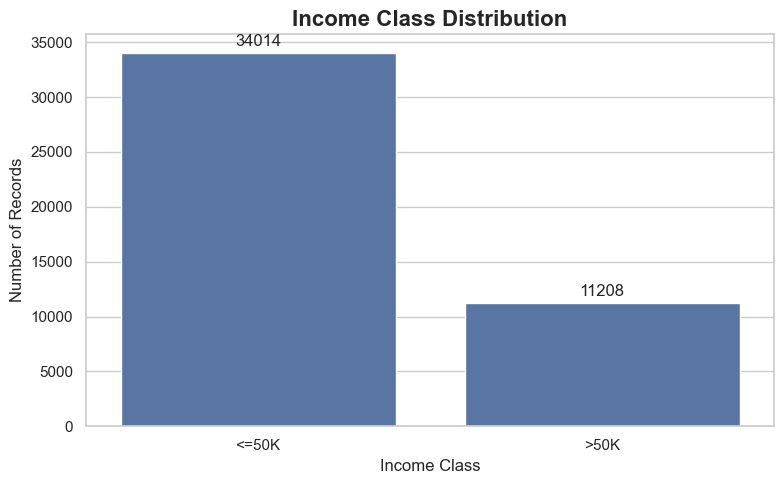

In [22]:
# Plot income class distribution

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="income"
)

plt.title(
    "Income Class Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Income Class")
plt.ylabel("Number of Records")

plt.xticks(
    [0, 1],
    ["<=50K", ">50K"]
)

# Add bar annotations
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=3
    )

plt.tight_layout()
plt.show()

### Income Class Distribution — Interpretation

The target variable is imbalanced.

Approximately three-fourths of the observations belong to class 0 (`<=50K`), while approximately one-fourth belong to class 1 (`>50K`).

Therefore, a model that predicts class 0 for almost every observation could achieve approximately 75% accuracy while performing poorly on the minority class.

For this reason, Precision, Recall and F1-score for class 1 (`>50K`) will be important evaluation metrics in the later ANN experiments.

## Task 1.5(a) — Age Distribution by Income

We use a histogram of `age` with `income` as the hue.

This helps us understand whether age distributions differ between people earning `<=50K` and those earning `>50K`.

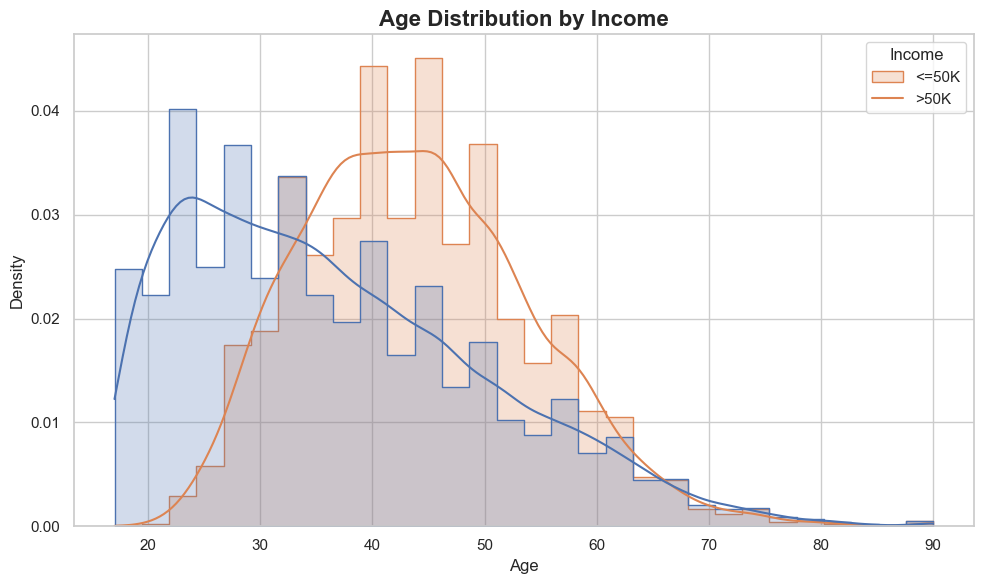

In [23]:
# Age distribution by income

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="age",
    hue="income",
    bins=30,
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)

plt.title(
    "Age Distribution by Income",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Age")
plt.ylabel("Density")

plt.legend(
    title="Income",
    labels=["<=50K", ">50K"]
)

plt.tight_layout()
plt.show()

### Age Plot Interpretation

The age distribution helps show how income varies across different age groups.

Individuals earning `>50K` generally appear more concentrated in middle and higher age ranges compared with the lower-income group.

This suggests that age can provide useful information to the ANN when predicting income.

## Task 1.5(b) — Hours per Week by Income

A boxplot is used to compare `hours.per.week` between the two income classes.

The boxplot allows us to compare:
- Median
- Interquartile range
- Spread
- Potential outliers

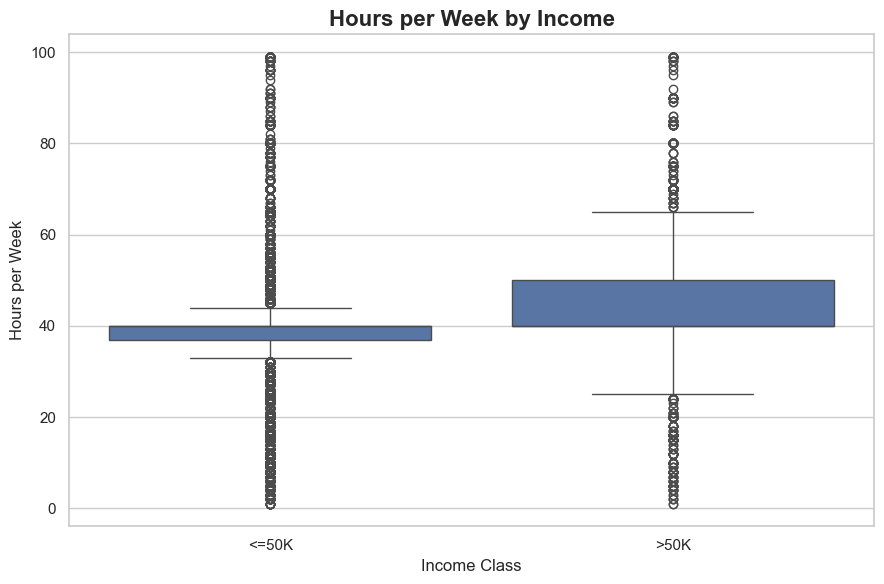

In [24]:
# Hours per week by income

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="income",
    y="hours-per-week"
)

plt.title(
    "Hours per Week by Income",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Income Class")
plt.ylabel("Hours per Week")

plt.xticks(
    [0, 1],
    ["<=50K", ">50K"]
)

plt.tight_layout()
plt.show()

### Hours per Week Plot Interpretation

The boxplot shows the distribution of weekly working hours for both income groups.

People earning `>50K` can show different working-hour patterns compared with people earning `<=50K`.

Therefore, `hours.per.week` can provide useful information for predicting income.

## Task 1.5(c) — Education Level by Income

We use a countplot of `education.num` grouped by `income`.

`education.num` is the numerical representation of education level.

This visualization helps identify whether higher education levels contain a larger proportion of individuals earning above $50K.

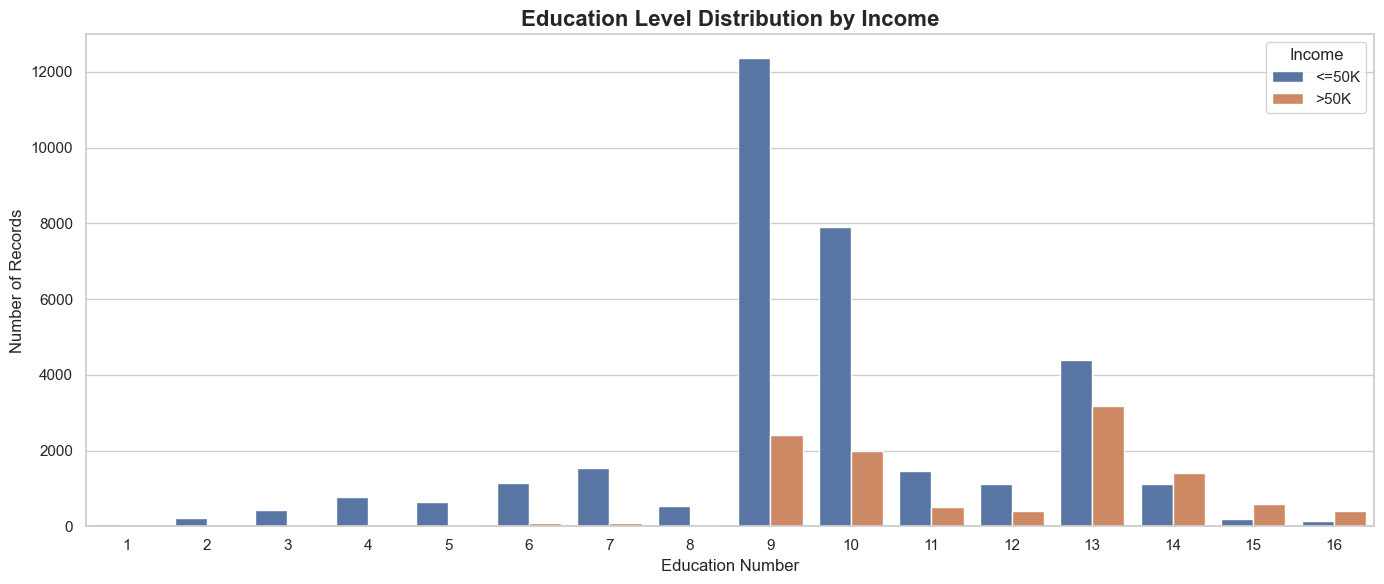

In [25]:
# Education level distribution by income

plt.figure(figsize=(14, 6))

ax = sns.countplot(
    data=df,
    x="educational-num",
    hue="income"
)

plt.title(
    "Education Level Distribution by Income",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Education Number")
plt.ylabel("Number of Records")

plt.legend(
    title="Income",
    labels=["<=50K", ">50K"]
)

plt.tight_layout()
plt.show()

### Education Plot Interpretation

Education level is an important predictor of income.

Higher `education.num` values tend to contain a larger proportion of observations belonging to the `>50K` class.

This supports retaining `educational-num` as a numerical feature for the ANN model.

The PDF specifically highlights higher education as an important pattern to examine during EDA.

## Task 1.5(d) — Correlation Heatmap

A correlation heatmap is used to examine relationships between the numerical variables.

At this stage, the categorical variables have not yet been one-hot encoded.

Therefore, the heatmap focuses on the numerical columns currently available in the cleaned dataset, including the encoded target `income`.

In [26]:
# Select numerical columns

numeric_eda = df.select_dtypes(include=np.number)

print("Numerical columns:")
print(numeric_eda.columns.tolist())

Numerical columns:
['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'income']


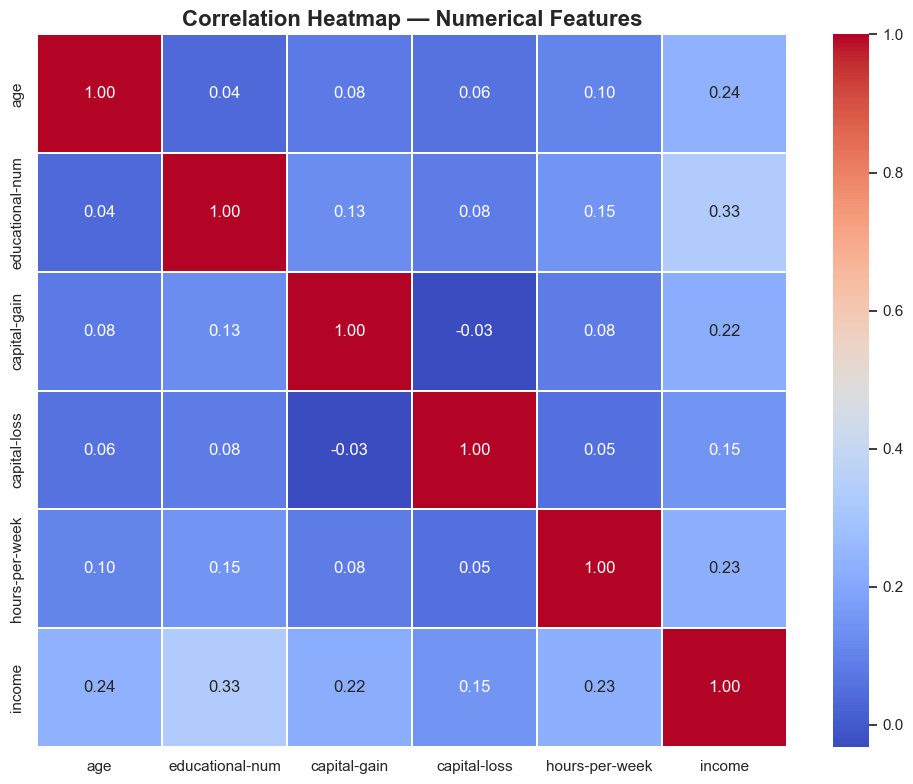

In [27]:
# Correlation heatmap

plt.figure(figsize=(10, 8))

sns.heatmap(
    numeric_eda.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.3
)

plt.title(
    "Correlation Heatmap — Numerical Features",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Correlation Heatmap Interpretation

The correlation heatmap shows the linear relationships between numerical variables.

`educational-num`, `age`, `hours-per-week`, `capital-gain` and `capital-loss` can have different levels of association with the income target.

A positive correlation with `income` indicates that higher values of that feature are associated with a greater tendency toward the `>50K` class.

Correlation does not prove causation. The ANN will later be able to learn non-linear relationships and interactions between features.

## Task 1.6 — Encode Categorical Variables, Scale Numerics and Split the Dataset

We now prepare the cleaned dataset for ANN training.

### Step 1 — Separate features and target

`X` will contain all input features.

`y` will contain the target `income`.

### Step 2 — One-Hot Encoding

Categorical variables are converted into numerical binary columns using:

`pd.get_dummies(drop_first=True)`

`drop_first=True` prevents unnecessary duplicate information.

### Step 3 — StandardScaler

The following numerical columns will be standardized:

- `age`
- `education.num`
- `capital.gain`
- `capital.loss`
- `hours.per.week`

The one-hot encoded binary columns will NOT be standardized.

### Step 4 — Train-Test Split

We use:

- Test size = 20%
- Random state = 42
- Stratification = `y`

Stratification ensures that the class distribution remains approximately the same in both training and testing datasets.

# Separate features and target


In [28]:
# Separate features and target

X = df.drop("income", axis=1).copy()
y = df["income"].copy()

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (45222, 12)
Target shape: (45222,)


# Identify categorical columns before one-hot encoding


In [29]:
# Identify categorical columns before one-hot encoding

categorical_columns = X.select_dtypes(
    include="object"
).columns.tolist()

print("Categorical Columns:")
print("=" * 60)

for col in categorical_columns:
    print(col)

Categorical Columns:
workclass
marital-status
occupation
relationship
race
gender
native-country


C:\Users\hp\AppData\Local\Temp\ipykernel_15792\971167143.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(


# One-hot encode categorical variables


In [30]:
# One-hot encode categorical variables

X = pd.get_dummies(
    X,
    drop_first=True
)

print("Shape after One-Hot Encoding:")
print(X.shape)

print()
print("Number of input features:", X.shape[1])

Shape after One-Hot Encoding:
(45222, 80)

Number of input features: 80


# Display first few rows after one-hot encoding


In [31]:
# Display first few rows after one-hot encoding

display(X.head())

,age,educational-num,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,marital-status_Married-spouse-absent,marital-status_Never-married,marital-status_Separated,marital-status_Widowed,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,gender_Male,native-country_Canada,native-country_China,native-country_Columbia,native-country_Cuba,native-country_Dominican-Republic,native-country_Ecuador,native-country_El-Salvador,native-country_England,native-country_France,native-country_Germany,native-country_Greece,native-country_Guatemala,native-country_Haiti,native-country_Holand-Netherlands,native-country_Honduras,native-country_Hong,native-country_Hungary,native-country_India,native-country_Iran,native-country_Ireland,native-country_Italy,native-country_Jamaica,native-country_Japan,native-country_Laos,native-country_Mexico,native-country_Nicaragua,native-country_Outlying-US(Guam-USVI-etc),native-country_Peru,native-country_Philippines,native-country_Poland,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,25,7,0,0,40,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
1,38,9,0,0,50,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2,28,12,0,0,40,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
3,44,10,7688,0,40,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
5,34,6,0,0,30,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,F

# Display data types after one-hot encoding


In [32]:
# Display data types after one-hot encoding

print("Data types after One-Hot Encoding:")
print("=" * 60)

display(X.dtypes.value_counts())

Data types after One-Hot Encoding:


bool     75
int64     5
Name: count, dtype: int64

# Train-test split with stratification


In [33]:
# Train-test split with stratification

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train-Test Split Completed!")
print("=" * 60)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

Train-Test Split Completed!
X_train shape: (36177, 80)
X_test shape : (9045, 80)
y_train shape: (36177,)
y_test shape : (9045,)


### Standardization of Numerical Features

We will standardize only the five numerical features:

- `age`
- `education_num`
- `capital-gain`
- `capital-loss`
- `hours-per-week`

The one-hot encoded categorical columns are already represented as binary values (0/1), so they are not standardized.

The scaler is fitted only on the training data and then applied to both training and testing data. This prevents information from the test set from influencing the preprocessing process.

# Numerical columns

In [34]:
# Numerical columns 

numeric_columns = [
    "age",
    "educational-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

print("Numerical columns to be scaled:")
print(numeric_columns)

Numerical columns to be scaled:
['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']


# Create StandardScaler


In [35]:
# Create StandardScaler

scaler = StandardScaler()

# Fit scaler only on training data
X_train[numeric_columns] = scaler.fit_transform(
    X_train[numeric_columns]
)

# Transform test data using the same scaler
X_test[numeric_columns] = scaler.transform(
    X_test[numeric_columns]
)

print("StandardScaler applied successfully!")
print()
print("Scaled numerical columns:")
print(numeric_columns)

StandardScaler applied successfully!

Scaled numerical columns:
['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']


# Verify mean and standard deviation of scaled training features


In [36]:
# Verify mean and standard deviation of scaled training features

scaling_check = pd.DataFrame({
    "Mean": X_train[numeric_columns].mean(),
    "Std": X_train[numeric_columns].std()
})

display(scaling_check)

,Mean,Std
age,-1.698923e-16,1.000014
educational-num,-3.393918e-16,1.000014
capital-gain,2.946110e-17,1.000014
capital-loss,-5.028027e-17,1.000014
hours-per-week,-2.521870e-16,1.000014


# Identify one-hot encoded columns


In [37]:
# Identify one-hot encoded columns

one_hot_columns = [
    col for col in X.columns
    if col not in numeric_columns
]

print("Number of numerical columns scaled:", len(numeric_columns))
print("Number of one-hot columns:", len(one_hot_columns))

print()
print("Example one-hot columns:")
print(one_hot_columns[:15])

Number of numerical columns scaled: 5
Number of one-hot columns: 75

Example one-hot columns:
['workclass_Local-gov', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Without-pay', 'marital-status_Married-AF-spouse', 'marital-status_Married-civ-spouse', 'marital-status_Married-spouse-absent', 'marital-status_Never-married', 'marital-status_Separated', 'marital-status_Widowed', 'occupation_Armed-Forces', 'occupation_Craft-repair', 'occupation_Exec-managerial']


# Final dataset shapes


In [38]:
# Final dataset shapes

print("=" * 60)
print("FINAL DATASET SHAPES")
print("=" * 60)

print("Original cleaned dataset :", df.shape)
print("Feature dataset X        :", X.shape)
print("Target dataset y         :", y.shape)

print()
print("Training Features        :", X_train.shape)
print("Testing Features         :", X_test.shape)

print()
print("Training Target          :", y_train.shape)
print("Testing Target           :", y_test.shape)

FINAL DATASET SHAPES
Original cleaned dataset : (45222, 13)
Feature dataset X        : (45222, 80)
Target dataset y         : (45222,)

Training Features        : (36177, 80)
Testing Features         : (9045, 80)

Training Target          : (36177,)
Testing Target           : (9045,)


# Check class distribution in complete dataset


In [39]:
# Check class distribution in complete dataset

overall_ratio = (
    y.value_counts(normalize=True)
    .sort_index()
    * 100
)

train_ratio = (
    y_train.value_counts(normalize=True)
    .sort_index()
    * 100
)

test_ratio = (
    y_test.value_counts(normalize=True)
    .sort_index()
    * 100
)

class_ratio_table = pd.DataFrame({
    "Overall (%)": overall_ratio,
    "Train (%)": train_ratio,
    "Test (%)": test_ratio
})

class_ratio_table.index = [
    "<=50K (Class 0)",
    ">50K (Class 1)"
]

display(class_ratio_table.round(2))

,Overall (%),Train (%),Test (%)
<=50K (Class 0),75.22,75.22,75.21
>50K (Class 1),24.78,24.78,24.79


# Display class counts for overall, train and test sets


In [40]:
# Display class counts for overall, train and test sets

class_count_table = pd.DataFrame({
    "Overall Count": y.value_counts().sort_index(),
    "Train Count": y_train.value_counts().sort_index(),
    "Test Count": y_test.value_counts().sort_index()
})

class_count_table.index = [
    "<=50K (Class 0)",
    ">50K (Class 1)"
]

display(class_count_table)

,Overall Count,Train Count,Test Count
<=50K (Class 0),34014,27211,6803
>50K (Class 1),11208,8966,2242


# Task 1 — Final Summary

Task 1 has completed the complete preprocessing and exploratory analysis pipeline for the Adult Income dataset.

### Dataset Cleaning
- Loaded `adult.csv`
- Removed whitespace from categorical columns
- Replaced `?` with `NaN`
- Removed rows containing missing values
- Dropped `fnlwgt`
- Dropped redundant `education`
- Kept `education.num`

### Target Encoding
- `<=50K` → 0
- `>50K` → 1

### EDA Completed
1. Age distribution by income
2. Hours per week by income
3. Education level by income
4. Numerical correlation heatmap

### Feature Engineering
- Categorical variables converted using One-Hot Encoding
- `drop_first=True` used
- Numerical columns standardized using StandardScaler
- One-hot binary columns were not standardized

### Data Split
- Training = 80%
- Testing = 20%
- `random_state=42`
- `stratify=y`

The variables created in this task are now ready for Task 2, where the baseline MLP/ANN architecture will be created.

# Task 2: MLP Architecture — Baseline ANN

## Objective

Build and train a baseline Multi-Layer Perceptron (MLP) neural network for binary income classification using the preprocessed Adult Income dataset.

### Task 2 Steps

1. Define a reusable `build_ann()` function.
2. Build the baseline ANN architecture.
3. Verify the total number of trainable parameters.
4. Explain why sigmoid is used in the output layer.
5. Train the baseline ANN for 50 epochs.
6. Plot training and validation loss and accuracy.
7. Evaluate the model using classification report and confusion matrix.
8. Explain why an MLP is suitable for structured tabular data.

## 2.1 Define the Reusable `build_ann()` Function

The `build_ann()` function is the foundation for the experiments in the remaining PR 2 tasks.

Instead of creating a new ANN manually for every experiment, we create one reusable function that allows us to change one configuration at a time.

The function accepts:

- `input_dim` — number of input features
- `hidden_units` — neurons in hidden layers
- `activation` — hidden-layer activation function
- `initializer` — weight initialization technique
- `use_batch_norm` — whether Batch Normalization is used
- `optimizer` — optimization algorithm
- `loss` — loss function

The function returns a compiled Keras Sequential model.

# Import TensorFlow and Keras


In [41]:
# Import TensorFlow and Keras

import tensorflow as tf
from tensorflow import keras

# Import evaluation metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("TensorFlow version:", tf.__version__)
print("TensorFlow and Keras imported successfully!")

TensorFlow version: 2.16.1
TensorFlow and Keras imported successfully!


# Verify that Task 1 variables are available


In [42]:
# Verify that Task 1 variables are available

print("Task 1 variables verification")
print("=" * 60)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

print()
print("Input dimension:", X_train.shape[1])

Task 1 variables verification
X_train shape: (36177, 80)
X_test shape : (9045, 80)
y_train shape: (36177,)
y_test shape : (9045,)

Input dimension: 80


# Reusable ANN builder function


In [43]:
# Reusable ANN builder function

def build_ann(
    input_dim,
    hidden_units=[128, 64],
    activation="relu",
    initializer="glorot_uniform",
    use_batch_norm=False,
    optimizer="adam",
    loss="binary_crossentropy"
):

    model = keras.Sequential()

    # Input + first hidden layer
    model.add(
        keras.layers.Dense(
            hidden_units[0],
            activation=activation,
            kernel_initializer=initializer,
            input_shape=(input_dim,)
        )
    )

    # Optional Batch Normalization
    if use_batch_norm:
        model.add(
            keras.layers.BatchNormalization()
        )

    # Remaining hidden layers
    for units in hidden_units[1:]:
        model.add(
            keras.layers.Dense(
                units,
                activation=activation,
                kernel_initializer=initializer
            )
        )

        if use_batch_norm:
            model.add(
                keras.layers.BatchNormalization()
            )

    # Output layer for binary classification
    model.add(
        keras.layers.Dense(
            1,
            activation="sigmoid"
        )
    )

    # Compile model
    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=["accuracy"]
    )

    return model


print("build_ann() function created successfully!")

build_ann() function created successfully!


## 2.2 Baseline ANN Architecture

The baseline ANN uses the following architecture:

Input Layer
→ Dense(128, ReLU)
→ Dense(64, ReLU)
→ Dense(1, Sigmoid)

### Configuration

- Hidden Layer 1: 128 neurons
- Hidden Layer 2: 64 neurons
- Hidden activation: ReLU
- Weight initializer: Glorot Uniform
- Output neurons: 1
- Output activation: Sigmoid
- Optimizer: Adam
- Loss: Binary Cross-Entropy
- Batch Normalization: Not used

This model will serve as the baseline for all subsequent experiments.

# Build the baseline ANN


In [44]:
# Build the baseline ANN

model_base = build_ann(
    input_dim=X_train.shape[1]
)

print("Baseline ANN created successfully!")

c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Baseline ANN created successfully!


# Display baseline ANN architecture


In [45]:
# Display baseline ANN architecture

model_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,689 (73.00 KB)

 Trainable params: 18,689 (73.00 KB)

 Non-trainable params: 0 (0.00 B)

# Manually calculate 


In [46]:
# Manually calculate the expected number of parameters

input_dim = X_train.shape[1]

# Dense layer parameter formula:
# parameters = input_features * neurons + neurons

layer1_params = (input_dim * 128) + 128
layer2_params = (128 * 64) + 64
output_params = (64 * 1) + 1

manual_total_params = (
    layer1_params +
    layer2_params +
    output_params
)

print("Manual Parameter Calculation")
print("=" * 60)

print(f"Input dimension        : {input_dim}")
print(f"Layer 1 parameters     : {layer1_params:,}")
print(f"Layer 2 parameters     : {layer2_params:,}")
print(f"Output layer parameters: {output_params:,}")

print("-" * 60)

print(f"Manual total parameters: {manual_total_params:,}")

Manual Parameter Calculation
Input dimension        : 80
Layer 1 parameters     : 10,368
Layer 2 parameters     : 8,256
Output layer parameters: 65
------------------------------------------------------------
Manual total parameters: 18,689


# Compare manual parameter count with Keras parameter count


In [47]:
# Compare manual parameter count with Keras parameter count

keras_total_params = model_base.count_params()

print("Parameter Verification")
print("=" * 60)

print("Manual calculation :", manual_total_params)
print("Keras count_params  :", keras_total_params)

print()

if manual_total_params == keras_total_params:
    print(" Parameter count VERIFIED successfully!")
else:
    print(" Parameter count does not match.")

Parameter Verification
Manual calculation : 18689
Keras count_params  : 18689

 Parameter count VERIFIED successfully!


### Why Sigmoid Instead of Softmax?

The target variable contains only two classes:

- `0` → `<=50K`
- `1` → `>50K`

Therefore, a single output neuron with a sigmoid activation is appropriate.

The sigmoid function is:

σ(z) = 1 / (1 + e^(-z))

It converts the output into a probability between 0 and 1.

For example:

- Output = 0.20 → approximately 20% probability of `>50K`
- Output = 0.80 → approximately 80% probability of `>50K`

We use one sigmoid neuron rather than two softmax neurons because this is a binary classification problem.

A sigmoid output is more efficient because one probability is sufficient to represent the binary decision.

During prediction, we use a threshold of 0.5:

- probability > 0.5 → class 1 (`>50K`)
- probability <= 0.5 → class 0 (`<=50K`)

## 2.3 Train the Baseline ANN

The baseline ANN will be trained using the exact configuration specified in PR 2:

- Epochs: 50
- Batch size: 64
- Validation split: 0.1
- Optimizer: Adam
- Loss: Binary Cross-Entropy
- Hidden activation: ReLU
- Weight initializer: Glorot Uniform

The History object will be stored in `history_base` so that training and validation curves can be plotted.

# Train the baseline ANN


In [48]:
# Train the baseline ANN

history_base = model_base.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

print("Baseline ANN training completed!")

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8427 - loss: 0.3345 - val_accuracy: 0.8488 - val_loss: 0.3217
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8523 - loss: 0.3149 - val_accuracy: 0.8524 - val_loss: 0.3216
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8545 - loss: 0.3112 - val_accuracy: 0.8532 - val_loss: 0.3209
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8554 - loss: 0.3075 - val_accuracy: 0.8480 - val_loss: 0.3209
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8582 - loss: 0.3055 - val_accuracy: 0.8527 - val_loss: 0.3170
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8591 - loss: 0.3028 - val_accuracy: 0.8510 - val_loss: 0.3190
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8607 - loss: 0.3005 - val_accuracy: 0.8557 - val_loss: 0.3186
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8598 - loss: 0.2986 - val_accuracy: 0.

# Plot baseline training and validation curves


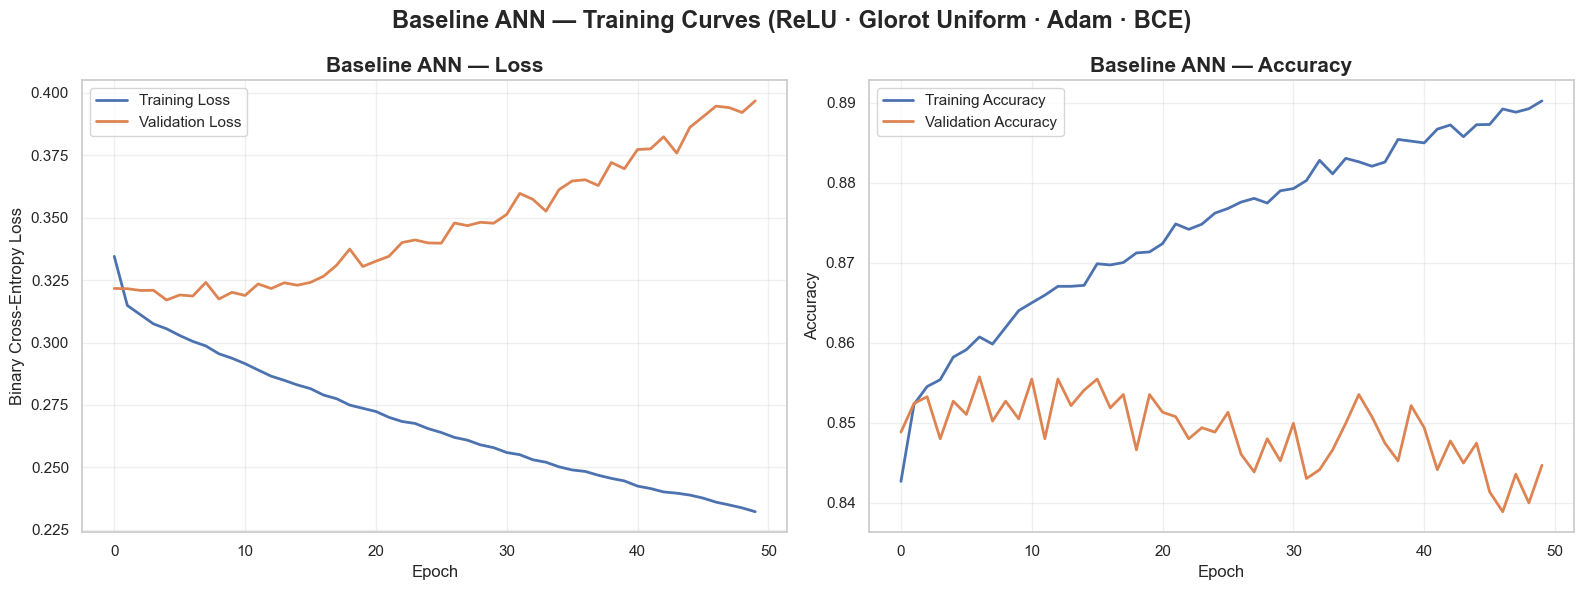

In [49]:
# Plot baseline training and validation curves

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

# -----------------------------
# Loss Plot
# -----------------------------

axes[0].plot(
    history_base.history["loss"],
    label="Training Loss",
    linewidth=2
)

axes[0].plot(
    history_base.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

axes[0].set_title(
    "Baseline ANN — Loss",
    fontsize=15,
    fontweight="bold"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Cross-Entropy Loss")

axes[0].legend()
axes[0].grid(True, alpha=0.3)


# -----------------------------
# Accuracy Plot
# -----------------------------

axes[1].plot(
    history_base.history["accuracy"],
    label="Training Accuracy",
    linewidth=2
)

axes[1].plot(
    history_base.history["val_accuracy"],
    label="Validation Accuracy",
    linewidth=2
)

axes[1].set_title(
    "Baseline ANN — Accuracy",
    fontsize=15,
    fontweight="bold"
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")

axes[1].legend()
axes[1].grid(True, alpha=0.3)


# Overall title
fig.suptitle(
    "Baseline ANN — Training Curves (ReLU · Glorot Uniform · Adam · BCE)",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Training Curve Interpretation

The training curves show how the baseline ANN learns during the 50 training epochs.

The loss curves show the Binary Cross-Entropy error during training and validation.

The accuracy curves show the proportion of correctly classified observations.

We compare the training and validation curves to identify:

- Whether the model is learning
- Whether validation performance improves with training
- Whether overfitting occurs
- Whether the training and validation curves remain reasonably close

The validation curves are particularly important because the final objective is good generalisation to unseen data.

## 2.4 Evaluate the Baseline ANN with Full Metrics

The trained baseline ANN will now be evaluated on the unseen test set.

We will:

1. Generate probability predictions.
2. Convert probabilities into class predictions using a 0.5 threshold.
3. Print the classification report.
4. Calculate Accuracy.
5. Calculate Precision for class 1.
6. Calculate Recall for class 1.
7. Calculate F1-score for class 1.
8. Plot the confusion matrix.

Because the Adult Income dataset is imbalanced, the class-1 F1-score is especially important.

# Generate probability predictions on test data


In [50]:
# Generate probability predictions on test data

y_pred_prob = model_base.predict(
    X_test,
    verbose=0
).flatten()

print("Probability predictions generated successfully!")

print()
print("First 10 predicted probabilities:")
print(y_pred_prob[:10])

Probability predictions generated successfully!

First 10 predicted probabilities:
[6.4202380e-01 1.4751507e-01 4.5758457e-04 5.8763552e-01 8.1929803e-02
 5.0698942e-01 1.6648163e-03 1.7411417e-01 2.5773883e-05 4.6637231e-01]


# Convert probabilities to binary class predictions


In [51]:
# Convert probabilities to binary class predictions

y_pred = (
    y_pred_prob > 0.5
).astype(int)

print("Binary predictions generated successfully!")

print()
print("First 20 predictions:")
print(y_pred[:20])

Binary predictions generated successfully!

First 20 predictions:
[1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0]


# Classification report


In [52]:
# Classification report

print("Classification Report — Baseline ANN")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "<=50K (Class 0)",
            ">50K (Class 1)"
        ]
    )
)

Classification Report — Baseline ANN
                 precision    recall  f1-score   support

<=50K (Class 0)       0.88      0.91      0.89      6803
 >50K (Class 1)       0.69      0.63      0.66      2242

       accuracy                           0.84      9045
      macro avg       0.79      0.77      0.78      9045
   weighted avg       0.84      0.84      0.84      9045



# Calculate baseline test metrics


In [53]:
# Calculate baseline test metrics

test_accuracy = accuracy_score(
    y_test,
    y_pred
)

precision_class1 = precision_score(
    y_test,
    y_pred,
    pos_label=1
)

recall_class1 = recall_score(
    y_test,
    y_pred,
    pos_label=1
)

f1_class1 = f1_score(
    y_test,
    y_pred,
    pos_label=1
)

print("Baseline ANN — Test Metrics")
print("=" * 60)

print(f"Accuracy          : {test_accuracy:.4f}")
print(f"Precision (Class 1): {precision_class1:.4f}")
print(f"Recall (Class 1)   : {recall_class1:.4f}")
print(f"F1-Score (Class 1) : {f1_class1:.4f}")

Baseline ANN — Test Metrics
Accuracy          : 0.8392
Precision (Class 1): 0.6931
Recall (Class 1)   : 0.6307
F1-Score (Class 1) : 0.6604


# Display metrics as percentages


In [54]:
# Display metrics as percentages

print("Baseline ANN — Test Performance")
print("=" * 60)

print(f"Accuracy           : {test_accuracy * 100:.2f}%")
print(f"Precision (Class 1): {precision_class1 * 100:.2f}%")
print(f"Recall (Class 1)   : {recall_class1 * 100:.2f}%")
print(f"F1-Score (Class 1) : {f1_class1 * 100:.2f}%")

Baseline ANN — Test Performance
Accuracy           : 83.92%
Precision (Class 1): 69.31%
Recall (Class 1)   : 63.07%
F1-Score (Class 1) : 66.04%


# Generate confusion matrix


In [55]:
# Generate confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[6177  626]
 [ 828 1414]]


# Plot confusion matrix heatmap


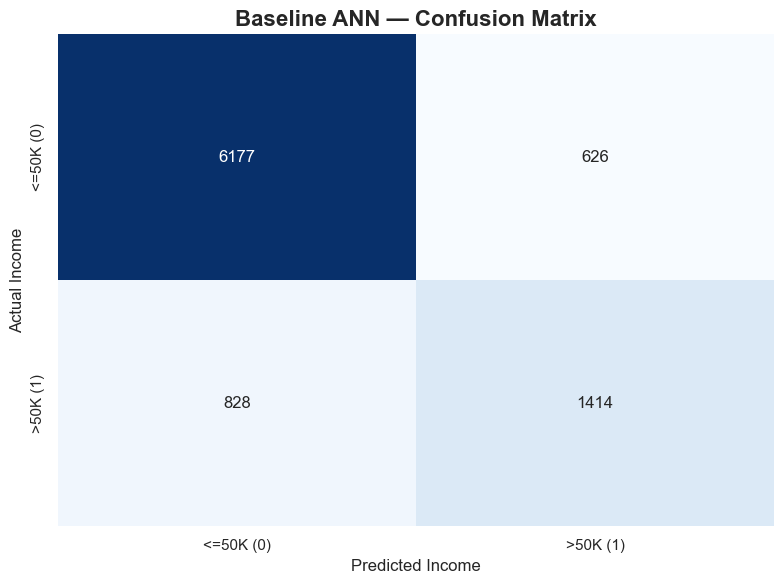

In [56]:
# Plot confusion matrix heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=[
        "<=50K (0)",
        ">50K (1)"
    ],
    yticklabels=[
        "<=50K (0)",
        ">50K (1)"
    ]
)

plt.title(
    "Baseline ANN — Confusion Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Predicted Income")
plt.ylabel("Actual Income")

plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation

The confusion matrix contains four types of predictions:

- True Negative (TN): Actual `<=50K`, predicted `<=50K`
- False Positive (FP): Actual `<=50K`, predicted `>50K`
- False Negative (FN): Actual `>50K`, predicted `<=50K`
- True Positive (TP): Actual `>50K`, predicted `>50K`

For this project, class 1 (`>50K`) is the minority class.

Therefore, False Negatives are particularly important because they represent people who actually earn above $50K but were predicted as belonging to the lower-income class.

Precision, Recall and F1-score for class 1 should therefore be considered alongside overall accuracy.

### Baseline ANN Metrics to Record

The following metrics should be carried forward to the final results table in Task 7:

| Metric | Baseline ANN |
|---|---:|
| Test Accuracy | 83.92% |
| Precision — Class 1 | 69.31% |
| Recall — Class 1 | 63.07% |
| F1-Score — Class 1 | 66.04% |

The actual values are obtained from the current training run and should not be manually entered before running the model.

## 2.5 WHY Tabular Data Suits ANN

The Adult Income dataset is structured tabular data containing numerical and categorical features.

After preprocessing:

- Numerical features are standardized.
- Categorical features are converted into one-hot encoded numerical columns.
- Each row represents one individual.
- Each input feature becomes an input neuron.

A fully connected Multi-Layer Perceptron is therefore suitable for this dataset.

The hidden layers can learn weighted combinations and non-linear relationships between features.

For example, the network can learn interactions such as:

- Age × Education
- Education × Occupation
- Hours Worked × Occupation
- Age × Hours Worked

These relationships may not be captured effectively by a simple linear model.

Unlike image data, which commonly uses CNNs, or sequential data, which may use RNNs/Transformers, structured tabular demographic and employment data is naturally suited to a fully connected MLP.

Therefore, the ANN is an appropriate model for the Adult Income classification problem.

# Store baseline results for later comparison


In [57]:
# Store baseline results for later comparison

baseline_results = {
    "Model": "Baseline ANN",
    "Activation": "ReLU",
    "Initializer": "Glorot Uniform",
    "Loss": "Binary Cross-Entropy",
    "BatchNorm": "No",
    "Optimizer": "Adam",
    "Test Accuracy": test_accuracy,
    "Precision (Class 1)": precision_class1,
    "Recall (Class 1)": recall_class1,
    "F1 (Class 1)": f1_class1
}

print("Baseline results stored successfully!")

display(
    pd.DataFrame([baseline_results])
)

Baseline results stored successfully!


,Model,Activation,Initializer,Loss,BatchNorm,Optimizer,Test Accuracy,Precision (Class 1),Recall (Class 1),F1 (Class 1)
0,Baseline ANN,ReLU,Glorot Uniform,Binary Cross-Entropy,No,Adam,0.839248,0.693137,0.630687,0.660439


# Task 2 — Final Summary

The baseline ANN has been successfully created, trained and evaluated.

### Baseline Architecture

Input
→ Dense(128, ReLU, Glorot Uniform)
→ Dense(64, ReLU, Glorot Uniform)
→ Dense(1, Sigmoid)

### Training Configuration

- Epochs: 50
- Batch Size: 64
- Validation Split: 10%
- Optimizer: Adam
- Loss: Binary Cross-Entropy

### Evaluation

The model was evaluated using:

- Accuracy
- Precision for class 1
- Recall for class 1
- F1-score for class 1
- Confusion Matrix

### Key Concept

Because the dataset is imbalanced, overall accuracy alone is not sufficient. Precision, Recall and F1-score for the minority class (`>50K`) are important metrics.

The baseline model will be used as the reference model for the experiments in Task 3 and the later tasks.

# Task 3: Activation Functions — Comparison Experiment

## Objective

Compare four activation functions in the hidden layers of the ANN:

1. ReLU
2. Tanh
3. Sigmoid
4. ELU

All other model configurations will remain unchanged so that the activation function is the only experimental variable.

### Common Configuration

- Hidden layers: 128 and 64 neurons
- Initializer: Glorot Uniform
- Optimizer: Adam
- Loss: Binary Cross-Entropy
- Epochs: 50
- Batch size: 64
- Validation split: 10%
- Output activation: Sigmoid

We will also perform:

- ReLU dead-neuron analysis
- Sigmoid gradient-flow analysis
- Final activation-function comparison

## 3.1 Build and Train Models with Different Activation Functions

A reusable ANN-building function will be used to create all four models.

Only the hidden-layer activation function changes. The output layer always uses sigmoid because the target is binary.

# Import the Keras layers module


In [58]:
# Import the Keras layers module

from tensorflow.keras import layers

print("Keras layers imported successfully!")

Keras layers imported successfully!


# Reusable ANN builder 


In [59]:
# Reusable ANN builder for Task 3 and later experiments

def build_ann(
    input_dim,
    hidden_units=[128, 64],
    activation="relu",
    initializer="glorot_uniform",
    use_batch_norm=False,
    optimizer="adam",
    loss="binary_crossentropy"
):
    model = keras.Sequential(name=f"ANN_{activation}")

    # Explicit input layer
    model.add(
        keras.Input(
            shape=(input_dim,),
            name="Input_Layer"
        )
    )

    # Hidden layers
    for layer_number, units in enumerate(hidden_units, start=1):

        model.add(
            layers.Dense(
                units=units,
                activation=activation,
                kernel_initializer=initializer,
                name=f"Hidden_Layer_{layer_number}"
            )
        )

        if use_batch_norm:
            model.add(
                layers.BatchNormalization(
                    name=f"BatchNorm_{layer_number}"
                )
            )

    # Output layer
    model.add(
        layers.Dense(
            units=1,
            activation="sigmoid",
            name="Output_Layer"
        )
    )

    # Compile model
    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=["accuracy"]
    )

    return model


print("Reusable build_ann() function created successfully!")

Reusable build_ann() function created successfully!


# Set random seeds for reproducible results


In [60]:
# Set random seeds for reproducible results

np.random.seed(42)
tf.random.set_seed(42)

print("Random seeds set successfully!")

Random seeds set successfully!


# Build four activation-function models


In [61]:
# Build four activation-function models

model_relu = build_ann(
    input_dim=X_train.shape[1],
    activation="relu"
)

model_tanh = build_ann(
    input_dim=X_train.shape[1],
    activation="tanh"
)

model_sigmoid = build_ann(
    input_dim=X_train.shape[1],
    activation="sigmoid"
)

model_elu = build_ann(
    input_dim=X_train.shape[1],
    activation="elu"
)

print("All four activation models created successfully!")

All four activation models created successfully!


# Display the model names and parameter counts


In [62]:
# Display the model names and parameter counts

activation_models = {
    "ReLU": model_relu,
    "Tanh": model_tanh,
    "Sigmoid": model_sigmoid,
    "ELU": model_elu
}

for activation_name, model in activation_models.items():
    print(
        f"{activation_name:8s} | "
        f"Parameters: {model.count_params():,}"
    )

ReLU     | Parameters: 18,689
Tanh     | Parameters: 18,689
Sigmoid  | Parameters: 18,689
ELU      | Parameters: 18,689


# Train ReLU model


In [63]:
# Train ReLU model

history_relu = model_relu.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

print("ReLU model training completed!")

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8434 - loss: 0.3359 - val_accuracy: 0.8491 - val_loss: 0.3228
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8534 - loss: 0.3147 - val_accuracy: 0.8502 - val_loss: 0.3211
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8550 - loss: 0.3110 - val_accuracy: 0.8502 - val_loss: 0.3202
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8560 - loss: 0.3081 - val_accuracy: 0.8502 - val_loss: 0.3200
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8572 - loss: 0.3056 - val_accuracy: 0.8496 - val_loss: 0.3204
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8584 - loss: 0.3032 - val_accuracy: 0.8513 - val_loss: 0.3206
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8601 - loss: 0.3007 - val_accuracy: 0.8510 - val_loss: 0.3213
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8609 - loss: 0.2984 - val_accuracy: 0.

# Train Tanh model


In [64]:
# Train Tanh model

history_tanh = model_tanh.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

print("Tanh model training completed!")

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8401 - loss: 0.3393 - val_accuracy: 0.8460 - val_loss: 0.3295
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8505 - loss: 0.3216 - val_accuracy: 0.8502 - val_loss: 0.3248
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8520 - loss: 0.3172 - val_accuracy: 0.8502 - val_loss: 0.3229
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8529 - loss: 0.3144 - val_accuracy: 0.8507 - val_loss: 0.3214
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8540 - loss: 0.3119 - val_accuracy: 0.8516 - val_loss: 0.3200
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8544 - loss: 0.3095 - val_accuracy: 0.8527 - val_loss: 0.3187
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8559 - loss: 0.3075 - val_accuracy: 0.8527 - val_loss: 0.3176
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8571 - loss: 0.3056 - val_accuracy: 0.

# Train Sigmoid hidden-activation model


In [65]:
# Train Sigmoid hidden-activation model

history_sigmoid = model_sigmoid.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

print("Sigmoid hidden-activation model training completed!")

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8168 - loss: 0.3869 - val_accuracy: 0.8452 - val_loss: 0.3356
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8476 - loss: 0.3294 - val_accuracy: 0.8458 - val_loss: 0.3318
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8481 - loss: 0.3271 - val_accuracy: 0.8466 - val_loss: 0.3307
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8481 - loss: 0.3259 - val_accuracy: 0.8466 - val_loss: 0.3296
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8487 - loss: 0.3248 - val_accuracy: 0.8480 - val_loss: 0.3283
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8492 - loss: 0.3235 - val_accuracy: 0.8491 - val_loss: 0.3269
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8498 - loss: 0.3220 - val_accuracy: 0.8494 - val_loss: 0.3255
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8505 - loss: 0.3206 - val_accuracy: 0.

# Train ELU model


In [66]:
# Train ELU model

history_elu = model_elu.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

print("ELU model training completed!")

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8436 - loss: 0.3363 - val_accuracy: 0.8483 - val_loss: 0.3260
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8514 - loss: 0.3201 - val_accuracy: 0.8452 - val_loss: 0.3245
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8519 - loss: 0.3172 - val_accuracy: 0.8485 - val_loss: 0.3239
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8521 - loss: 0.3158 - val_accuracy: 0.8505 - val_loss: 0.3233
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8523 - loss: 0.3146 - val_accuracy: 0.8510 - val_loss: 0.3226
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8531 - loss: 0.3136 - val_accuracy: 0.8502 - val_loss: 0.3217
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8536 - loss: 0.3124 - val_accuracy: 0.8527 - val_loss: 0.3206
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8543 - loss: 0.3112 - val_accuracy: 0.

## 3.2 Calculate Final Validation Accuracy and Class-1 F1-Score

Keras uses the final 10% of the training data as validation data when `validation_split=0.1` is used.

We will use this validation portion to calculate the class-1 F1-score for every activation function.

# Reconstruct the validation data used by validation_split=0.1


In [67]:
# Reconstruct the validation data used by validation_split=0.1

validation_size = int(len(X_train) * 0.1)

if hasattr(X_train, "iloc"):
    X_validation = X_train.iloc[-validation_size:]
    y_validation = y_train.iloc[-validation_size:]
else:
    X_validation = X_train[-validation_size:]
    y_validation = y_train[-validation_size:]

print("Validation feature shape:", X_validation.shape)
print("Validation target shape :", y_validation.shape)

Validation feature shape: (3617, 80)
Validation target shape : (3617,)


# Function to calculate class-1 F1-score


In [68]:
# Function to calculate class-1 F1-score

def calculate_validation_f1(model, X_val, y_val):

    probabilities = model.predict(
        X_val,
        verbose=0
    ).flatten()

    predictions = (
        probabilities > 0.5
    ).astype(int)

    return f1_score(
        y_val,
        predictions,
        pos_label=1,
        zero_division=0
    )

# Calculate final validation accuracy and class-1 F1-score


In [69]:
# Calculate final validation accuracy and class-1 F1-score

activation_histories = {
    "ReLU": history_relu,
    "Tanh": history_tanh,
    "Sigmoid": history_sigmoid,
    "ELU": history_elu
}

activation_f1_scores = {}

for activation_name, model in activation_models.items():

    activation_f1_scores[activation_name] = (
        calculate_validation_f1(
            model,
            X_validation,
            y_validation
        )
    )

    final_val_accuracy = (
        activation_histories[activation_name]
        .history["val_accuracy"][-1]
    )

    print(
        f"{activation_name:8s} | "
        f"Final Validation Accuracy: {final_val_accuracy:.4f} | "
        f"Class-1 F1: {activation_f1_scores[activation_name]:.4f}"
    )

ReLU     | Final Validation Accuracy: 0.8380 | Class-1 F1: 0.6314
Tanh     | Final Validation Accuracy: 0.8491 | Class-1 F1: 0.6587
Sigmoid  | Final Validation Accuracy: 0.8535 | Class-1 F1: 0.6708
ELU      | Final Validation Accuracy: 0.8552 | Class-1 F1: 0.6797


## 3.3 Activation Comparison — Four-Panel Plot

Each subplot displays:

- Training accuracy in red
- Validation accuracy in charcoal
- A dashed 75% majority-class baseline
- Final validation accuracy
- Class-1 F1-score

The 75% reference line is important because a model that always predicts the majority class can achieve approximately 75% accuracy without learning useful minority-class patterns.

# Create activation comparison plot


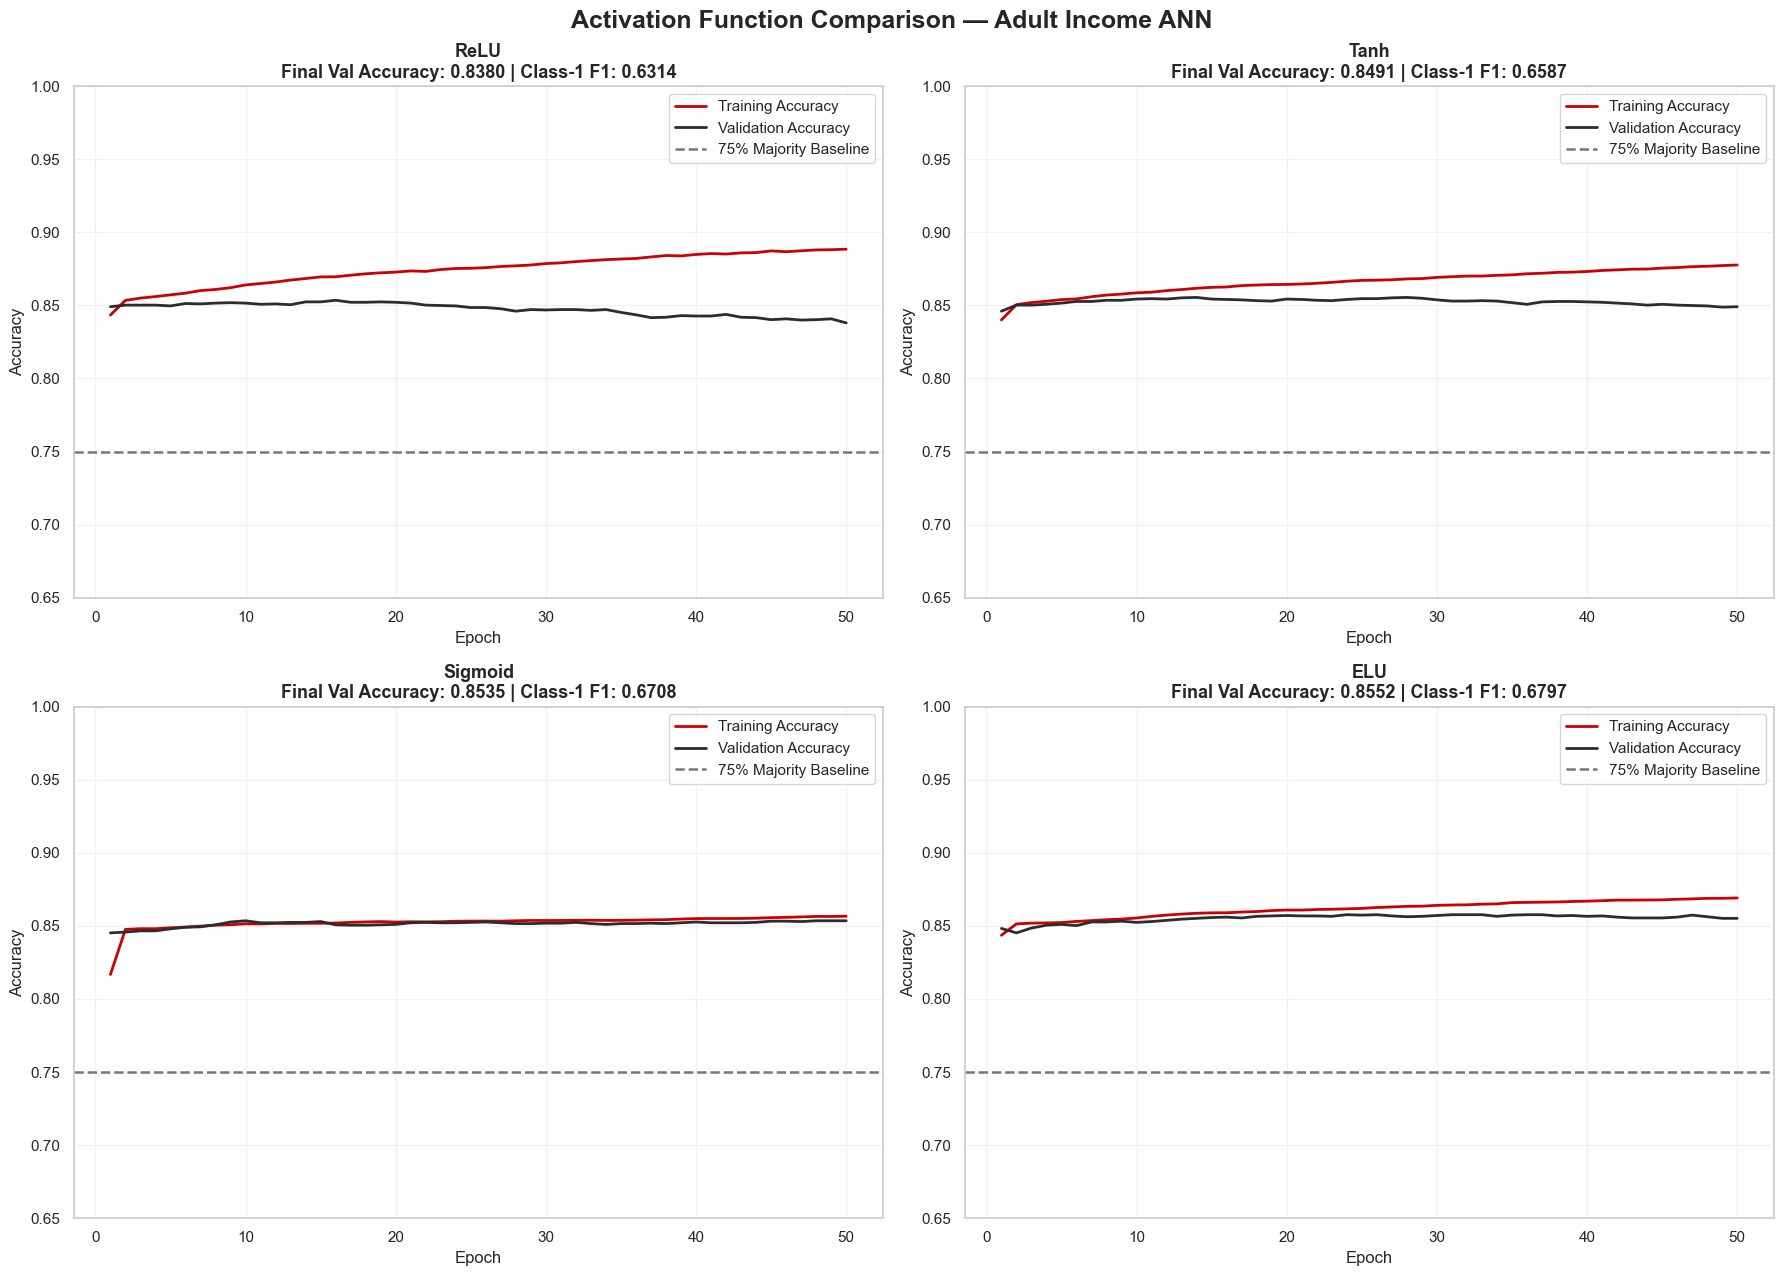

In [70]:
# Create activation comparison plot

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 13)
)

plot_information = [
    ("ReLU", history_relu),
    ("Tanh", history_tanh),
    ("Sigmoid", history_sigmoid),
    ("ELU", history_elu)
]

for axis, (activation_name, history) in zip(
    axes.flatten(),
    plot_information
):
    epochs = range(
        1,
        len(history.history["accuracy"]) + 1
    )

    final_val_accuracy = (
        history.history["val_accuracy"][-1]
    )

    final_f1 = activation_f1_scores[
        activation_name
    ]

    axis.plot(
        epochs,
        history.history["accuracy"],
        color="#CC0000",
        linewidth=2,
        label="Training Accuracy"
    )

    axis.plot(
        epochs,
        history.history["val_accuracy"],
        color="#2C2C2C",
        linewidth=2,
        label="Validation Accuracy"
    )

    axis.axhline(
        y=0.75,
        color="#777777",
        linestyle="--",
        linewidth=1.8,
        label="75% Majority Baseline"
    )

    axis.set_title(
        f"{activation_name}\n"
        f"Final Val Accuracy: {final_val_accuracy:.4f} | "
        f"Class-1 F1: {final_f1:.4f}",
        fontsize=13,
        fontweight="bold"
    )

    axis.set_xlabel("Epoch")
    axis.set_ylabel("Accuracy")
    axis.set_ylim(0.65, 1.0)
    axis.grid(True, alpha=0.25)
    axis.legend()

fig.suptitle(
    "Activation Function Comparison — Adult Income ANN",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## 3.4 Dead-Neuron Check — ReLU

A ReLU neuron outputs zero whenever its input is negative:

ReLU(x) = max(0, x)

If a neuron produces zero for all observations, it may become a dead neuron because no useful gradient passes through it.

We will extract the outputs of the first ReLU hidden layer for 500 test samples and calculate the fraction of zero activations.

# Create a sub-model for the first ReLU hidden layer


In [71]:
#  Create sub-model for first ReLU hidden layer

# Call the model once to ensure its graph is created
dummy_input = tf.zeros(
    (1, X_train.shape[1]),
    dtype=tf.float32
)

_ = model_relu(dummy_input)

# Get the first hidden layer
first_relu_layer = model_relu.get_layer(
    "Hidden_Layer_1"
)

# Create the intermediate model
relu_intermediate_model = keras.Model(
    inputs=model_relu.inputs,
    outputs=first_relu_layer.output
)

print("ReLU intermediate model created successfully!")

ReLU intermediate model created successfully!


# Select 500 test samples


In [72]:
# Select 500 test samples

if hasattr(X_test, "iloc"):
    X_test_sample = X_test.iloc[:500]
else:
    X_test_sample = X_test[:500]

# Extract first hidden-layer activations

relu_activations = relu_intermediate_model.predict(
    X_test_sample,
    verbose=0
)

print("Activation matrix shape:", relu_activations.shape)

Activation matrix shape: (500, 128)


# Calculate zero-activation fraction


In [73]:
# Calculate zero-activation fraction

dead_fraction = np.mean(
    relu_activations == 0
)

# Calculate completely dead neurons

dead_neurons = np.all(
    relu_activations == 0,
    axis=0
)

number_of_dead_neurons = dead_neurons.sum()

print("ReLU Dead-Neuron Analysis")
print("=" * 60)

print(
    f"Fraction of all zero activations: "
    f"{dead_fraction:.4f}"
)

print(
    f"Zero activation percentage      : "
    f"{dead_fraction * 100:.2f}%"
)

print(
    f"Completely dead neurons         : "
    f"{number_of_dead_neurons} out of "
    f"{relu_activations.shape[1]}"
)

ReLU Dead-Neuron Analysis
Fraction of all zero activations: 0.6152
Zero activation percentage      : 61.52%
Completely dead neurons         : 0 out of 128


# Calculate mean activation of each neuron


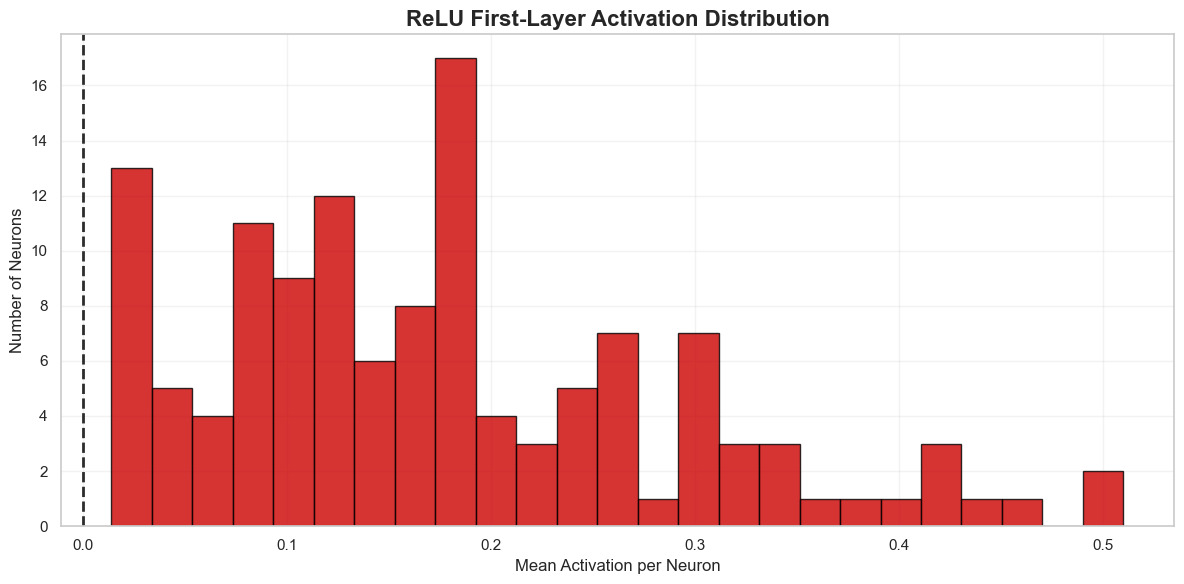

In [74]:
# Calculate mean activation of each neuron

mean_relu_activation = np.mean(
    relu_activations,
    axis=0
)

plt.figure(figsize=(12, 6))

plt.hist(
    mean_relu_activation,
    bins=25,
    color="#CC0000",
    edgecolor="black",
    alpha=0.80
)

plt.axvline(
    x=0,
    color="#2C2C2C",
    linestyle="--",
    linewidth=2
)

plt.title(
    "ReLU First-Layer Activation Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Mean Activation per Neuron")
plt.ylabel("Number of Neurons")
plt.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

### ReLU Dead-Neuron Interpretation

The `dead_fraction` represents the proportion of first-layer ReLU outputs equal to zero.

A zero output does not automatically mean that the neuron is permanently dead. A completely dead neuron produces zero for every observation.

ReLU can suffer from dead neurons because negative inputs produce zero outputs and zero gradients.

ELU reduces this problem by allowing small negative outputs:

ELU(x) = x, when x > 0

ELU(x) = α(eˣ − 1), when x <= 0

Because ELU retains a non-zero gradient for negative inputs, it keeps the gradient path alive and allows neurons to recover.

## 3.5 Gradient-Flow Check — Sigmoid Hidden Layers

The sigmoid derivative is:

σ'(x) = σ(x)(1 − σ(x))

Its maximum value is only 0.25.

When gradients pass backwards through multiple sigmoid layers, these small derivative values are repeatedly multiplied. As a result, gradients in earlier layers can become extremely small.

This is known as the vanishing-gradient problem.

# Prepare a single batch for gradient analysis


In [75]:
# Prepare a single batch for gradient analysis

batch_size_gradient = 64

if hasattr(X_train, "iloc"):
    X_gradient_batch = X_train.iloc[:batch_size_gradient]
    y_gradient_batch = y_train.iloc[:batch_size_gradient]
else:
    X_gradient_batch = X_train[:batch_size_gradient]
    y_gradient_batch = y_train[:batch_size_gradient]

# Convert to TensorFlow tensors

X_gradient_tensor = tf.convert_to_tensor(
    np.asarray(X_gradient_batch),
    dtype=tf.float32
)

y_gradient_tensor = tf.convert_to_tensor(
    np.asarray(y_gradient_batch).reshape(-1, 1),
    dtype=tf.float32
)

print("Gradient batch prepared successfully!")

Gradient batch prepared successfully!


# Compute gradients using GradientTape


In [76]:
# Compute gradients using GradientTape

binary_crossentropy = keras.losses.BinaryCrossentropy()

with tf.GradientTape() as tape:

    sigmoid_predictions = model_sigmoid(
        X_gradient_tensor,
        training=True
    )

    sigmoid_loss = binary_crossentropy(
        y_gradient_tensor,
        sigmoid_predictions
    )

sigmoid_gradients = tape.gradient(
    sigmoid_loss,
    model_sigmoid.trainable_variables
)

print("Sigmoid gradients calculated successfully!")
print("Batch loss:", float(sigmoid_loss))

Sigmoid gradients calculated successfully!
Batch loss: 0.38232144713401794


# Calculate mean gradient for each Dense layer


In [77]:
# Calculate mean gradient for each Dense layer

dense_layer_names = []
mean_gradient_values = []

# Match every trainable variable with its calculated gradient
gradient_map = {
    id(variable): gradient
    for variable, gradient in zip(
        model_sigmoid.trainable_variables,
        sigmoid_gradients
    )
}

for layer in model_sigmoid.layers:

    if isinstance(layer, layers.Dense):

        # Obtain the kernel gradient using object identity
        kernel_gradient = gradient_map.get(
            id(layer.kernel)
        )

        if kernel_gradient is not None:

            mean_absolute_gradient = float(
                tf.reduce_mean(
                    tf.abs(kernel_gradient)
                ).numpy()
            )

            dense_layer_names.append(
                layer.name
            )

            mean_gradient_values.append(
                mean_absolute_gradient
            )

# Create gradient table
gradient_table = pd.DataFrame({
    "Dense Layer": dense_layer_names,
    "Mean Absolute Gradient": mean_gradient_values
})

display(gradient_table)

,Dense Layer,Mean Absolute Gradient
0,Hidden_Layer_1,0.000219
1,Hidden_Layer_2,0.000245
2,Output_Layer,0.003688


# Plot sigmoid gradient magnitude by layer


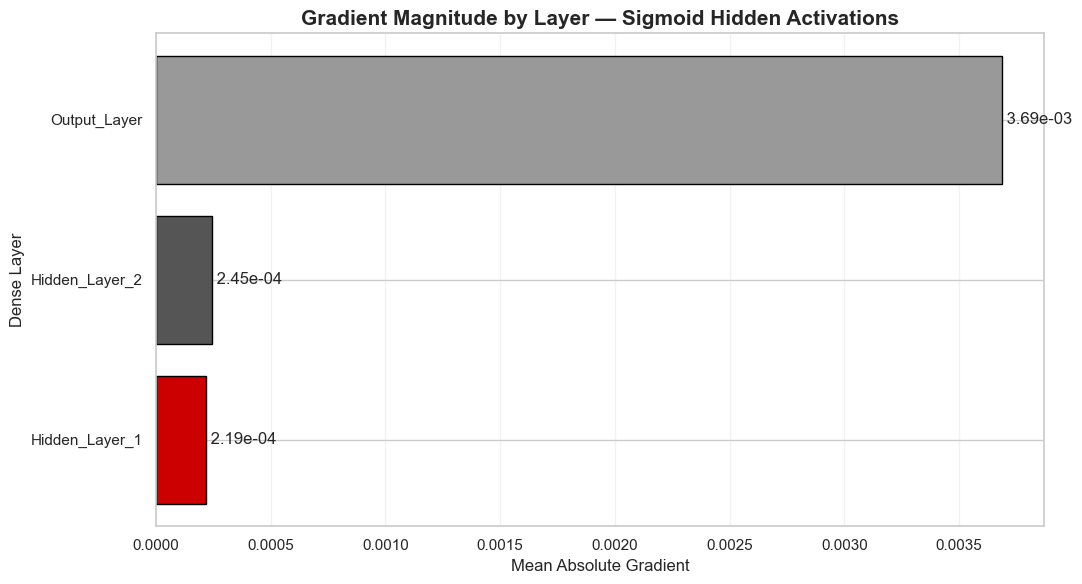

In [78]:
# Plot sigmoid gradient magnitude by layer

plt.figure(figsize=(11, 6))

bars = plt.barh(
    dense_layer_names,
    mean_gradient_values,
    color=[
        "#CC0000",
        "#555555",
        "#999999"
    ],
    edgecolor="black"
)

plt.title(
    "Gradient Magnitude by Layer — Sigmoid Hidden Activations",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Mean Absolute Gradient")
plt.ylabel("Dense Layer")
plt.grid(axis="x", alpha=0.25)

for bar, value in zip(
    bars,
    mean_gradient_values
):
    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {value:.2e}",
        va="center"
    )

plt.tight_layout()
plt.show()

### Sigmoid Gradient-Flow Interpretation

If the first hidden layer has a much smaller gradient magnitude than the output layer, the model is experiencing vanishing gradients.

This occurs because:

σ'(x) = σ(x)(1 − σ(x)) <= 0.25

During backpropagation, the gradient is multiplied by this derivative at every sigmoid hidden layer. Repeated multiplication causes the gradient to shrink as it moves towards the earlier layers.

Therefore:

- Sigmoid is suitable for the binary output layer.
- Sigmoid is usually not preferred in deep hidden layers.
- ReLU and ELU generally provide stronger gradient flow.

# Build activation-function results table


In [79]:
# Build activation-function results table

activation_results = pd.DataFrame({
    "Activation": [
        "ReLU",
        "Tanh",
        "Sigmoid (Hidden)",
        "ELU"
    ],
    "Formula": [
        "max(0, x)",
        "tanh(x)",
        "1 / (1 + exp(-x))",
        "x if x>0, alpha(exp(x)-1) otherwise"
    ],
    "Output Range": [
        "[0, infinity)",
        "[-1, 1]",
        "[0, 1]",
        "[-alpha, infinity)"
    ],
    "Zero-Centred": [
        "No",
        "Yes",
        "No",
        "Approximately"
    ],
    "Vanishing Gradient Risk": [
        "Low",
        "Medium",
        "High",
        "Low"
    ],
    "Dead Neuron Risk": [
        "Yes",
        "No",
        "No",
        "Very Low"
    ],
    "Final Validation Accuracy": [
        history_relu.history["val_accuracy"][-1],
        history_tanh.history["val_accuracy"][-1],
        history_sigmoid.history["val_accuracy"][-1],
        history_elu.history["val_accuracy"][-1]
    ],
    "Class-1 F1": [
        activation_f1_scores["ReLU"],
        activation_f1_scores["Tanh"],
        activation_f1_scores["Sigmoid"],
        activation_f1_scores["ELU"]
    ]
})

display(
    activation_results.style.format({
        "Final Validation Accuracy": "{:.4f}",
        "Class-1 F1": "{:.4f}"
    })
)

,Activation,Formula,Output Range,Zero-Centred,Vanishing Gradient Risk,Dead Neuron Risk,Final Validation Accuracy,Class-1 F1
0,ReLU,"max(0, x)","[0, infinity)",No,Low,Yes,0.8380,0.6314
1,Tanh,tanh(x),"[-1, 1]",Yes,Medium,No,0.8491,0.6587
2,Sigmoid (Hidden),1 / (1 + exp(-x)),"[0, 1]",No,High,No,0.8535,0.6708
3,ELU,"x if x>0, alpha(exp(x)-1) otherwise","[-alpha, infinity)",Approximately,Low,Very Low,0.8552,0.6797


# Identify the best activation using class-1 F1-score


In [80]:
# Identify the best activation using class-1 F1-score

best_activation_row = activation_results.loc[
    activation_results["Class-1 F1"].idxmax()
]

print("Best Activation Function")
print("=" * 60)

print(
    "Activation:",
    best_activation_row["Activation"]
)

print(
    f"Validation Accuracy: "
    f"{best_activation_row['Final Validation Accuracy']:.4f}"
)

print(
    f"Class-1 F1-Score: "
    f"{best_activation_row['Class-1 F1']:.4f}"
)

Best Activation Function
Activation: ELU
Validation Accuracy: 0.8552
Class-1 F1-Score: 0.6797


## Task 3 — Final Conclusion

ReLU, Tanh, Sigmoid and ELU hidden activations were trained under the same conditions.

The final recommendation should be based on both:

- Validation accuracy
- Class-1 F1-score

ReLU usually provides fast and effective training because it does not saturate for positive inputs. However, it can produce dead neurons.

ELU allows negative outputs and maintains a gradient for negative inputs, reducing the dead-neuron problem.

Tanh is zero-centred, but it can saturate for large positive or negative values.

Sigmoid is not recommended for hidden layers because its derivative is always at most 0.25, which increases the risk of vanishing gradients.

### Important Output-Layer Rule

Sigmoid remains the correct activation for the output layer regardless of which hidden activation performs best, because the problem is binary classification.

# Task 4: Weight Initialization Techniques

## Objective

Compare five weight-initialization techniques:

1. Glorot Uniform
2. Glorot Normal
3. He Uniform
4. He Normal
5. Zeros

All models will use ReLU hidden activations and the same architecture, optimizer, loss function and training configuration.

We will examine:

- Validation accuracy
- Convergence speed
- Failure of zero initialization
- Initial and trained weight distributions

## 4.1 Why Weight Initialization Matters

Neural networks trained using all-zero weights suffer from the symmetry problem.

When every neuron begins with identical weights:

- Every neuron produces the same output.
- Every neuron receives the same gradient.
- Every neuron makes the same update.
- The neurons remain identical throughout training.

Therefore, a wide hidden layer behaves like only one effective neuron.

### Xavier/Glorot Initialization

Glorot initialization uses approximately:

Var(W) = 2 / (fan_in + fan_out)

It attempts to keep the variance of activations and gradients stable between layers. It is particularly suitable for Tanh and Sigmoid activations.

### He Initialization

He initialization uses:

Var(W) = 2 / fan_in

ReLU sets approximately half of its activations to zero. The additional factor of 2 compensates for this loss and helps preserve activation variance.

Therefore, He initialization is generally preferred for ReLU networks.

## 4.2 Build Five Models with Different Initializers

Only the weight initializer changes in this experiment.

### Common Configuration

- Activation: ReLU
- Hidden layers: 128 and 64 neurons
- Optimizer: Adam
- Loss: Binary Cross-Entropy
- Epochs: 50
- Batch size: 64
- Validation split: 10%

# Create initializer configurations


In [81]:
# Create initializer configurations

initializer_configurations = {
    "Glorot Uniform": "glorot_uniform",
    "Glorot Normal": "glorot_normal",
    "He Uniform": "he_uniform",
    "He Normal": "he_normal",
    "Zeros": "zeros"
}

print("Initializer configurations created successfully!")

Initializer configurations created successfully!


# Reset random seeds


In [82]:
# Reset random seeds

np.random.seed(42)
tf.random.set_seed(42)

# Build all five initializer models before training

model_glorot_uniform = build_ann(
    input_dim=X_train.shape[1],
    activation="relu",
    initializer="glorot_uniform"
)

model_glorot_normal = build_ann(
    input_dim=X_train.shape[1],
    activation="relu",
    initializer="glorot_normal"
)

model_he_uniform = build_ann(
    input_dim=X_train.shape[1],
    activation="relu",
    initializer="he_uniform"
)

model_he_normal = build_ann(
    input_dim=X_train.shape[1],
    activation="relu",
    initializer="he_normal"
)

model_zeros = build_ann(
    input_dim=X_train.shape[1],
    activation="relu",
    initializer="zeros"
)

print("All five initializer models created successfully!")

All five initializer models created successfully!


# Store models in a dictionary


In [83]:
# Store models in a dictionary

initializer_models = {
    "Glorot Uniform": model_glorot_uniform,
    "Glorot Normal": model_glorot_normal,
    "He Uniform": model_he_uniform,
    "He Normal": model_he_normal,
    "Zeros": model_zeros
}

for initializer_name, model in initializer_models.items():
    print(
        f"{initializer_name:15s} | "
        f"Parameters: {model.count_params():,}"
    )

Glorot Uniform  | Parameters: 18,689
Glorot Normal   | Parameters: 18,689
He Uniform      | Parameters: 18,689
He Normal       | Parameters: 18,689
Zeros           | Parameters: 18,689


## 4.3 Store Initial Weight Distributions

The initial first-layer weights must be stored before model training.

We will store weights from:

- He Normal model
- Glorot Uniform model

After training, the new weights will be extracted again for comparison.

# Extract initial first-layer weights before training


In [84]:
# Extract initial first-layer weights before training

he_normal_weights_before = (
    model_he_normal
    .get_layer("Hidden_Layer_1")
    .get_weights()[0]
    .copy()
)

glorot_uniform_weights_before = (
    model_glorot_uniform
    .get_layer("Hidden_Layer_1")
    .get_weights()[0]
    .copy()
)

print(
    "He Normal initial weight shape:",
    he_normal_weights_before.shape
)

print(
    "Glorot Uniform initial weight shape:",
    glorot_uniform_weights_before.shape
)

He Normal initial weight shape: (80, 128)
Glorot Uniform initial weight shape: (80, 128)


# Display initial weight statistics


In [85]:
# Display initial weight statistics

initial_weight_statistics = pd.DataFrame({
    "Initializer": [
        "He Normal",
        "Glorot Uniform"
    ],
    "Mean": [
        he_normal_weights_before.mean(),
        glorot_uniform_weights_before.mean()
    ],
    "Standard Deviation": [
        he_normal_weights_before.std(),
        glorot_uniform_weights_before.std()
    ],
    "Minimum": [
        he_normal_weights_before.min(),
        glorot_uniform_weights_before.min()
    ],
    "Maximum": [
        he_normal_weights_before.max(),
        glorot_uniform_weights_before.max()
    ]
})

display(initial_weight_statistics)

,Initializer,Mean,Standard Deviation,Minimum,Maximum
0,He Normal,-0.001395,0.157403,-0.359151,0.359140
1,Glorot Uniform,0.000263,0.098304,-0.169839,0.169835


# Train Glorot Uniform model


In [86]:
# Train Glorot Uniform model

history_glorot_uniform = model_glorot_uniform.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

print("Glorot Uniform model training completed!")

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8394 - loss: 0.3404 - val_accuracy: 0.8505 - val_loss: 0.3216
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8524 - loss: 0.3149 - val_accuracy: 0.8513 - val_loss: 0.3203
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8543 - loss: 0.3115 - val_accuracy: 0.8521 - val_loss: 0.3196
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8559 - loss: 0.3087 - val_accuracy: 0.8532 - val_loss: 0.3193
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8570 - loss: 0.3062 - val_accuracy: 0.8519 - val_loss: 0.3191
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8578 - loss: 0.3037 - val_accuracy: 0.8519 - val_loss: 0.3188
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8598 - loss: 0.3013 - val_accuracy: 0.8510 - val_loss: 0.3191
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8616 - loss: 0.2989 - val_accuracy: 0.

# Train Glorot Normal model


In [87]:
# Train Glorot Normal model

history_glorot_normal = model_glorot_normal.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

print("Glorot Normal model training completed!")

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8441 - loss: 0.3351 - val_accuracy: 0.8507 - val_loss: 0.3215
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8532 - loss: 0.3145 - val_accuracy: 0.8513 - val_loss: 0.3192
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8556 - loss: 0.3107 - val_accuracy: 0.8535 - val_loss: 0.3188
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8561 - loss: 0.3076 - val_accuracy: 0.8510 - val_loss: 0.3183
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8585 - loss: 0.3048 - val_accuracy: 0.8524 - val_loss: 0.3179
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8594 - loss: 0.3023 - val_accuracy: 0.8532 - val_loss: 0.3177
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8602 - loss: 0.2998 - val_accuracy: 0.8543 - val_loss: 0.3173
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8611 - loss: 0.2975 - val_accuracy: 0.

# Train He Uniform model


In [88]:
# Train He Uniform model

history_he_uniform = model_he_uniform.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

print("He Uniform model training completed!")

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8434 - loss: 0.3371 - val_accuracy: 0.8485 - val_loss: 0.3226
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8529 - loss: 0.3151 - val_accuracy: 0.8480 - val_loss: 0.3205
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8544 - loss: 0.3106 - val_accuracy: 0.8494 - val_loss: 0.3197
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8565 - loss: 0.3074 - val_accuracy: 0.8485 - val_loss: 0.3199
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8585 - loss: 0.3044 - val_accuracy: 0.8499 - val_loss: 0.3203
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8591 - loss: 0.3016 - val_accuracy: 0.8502 - val_loss: 0.3205
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8609 - loss: 0.2989 - val_accuracy: 0.8502 - val_loss: 0.3209
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8621 - loss: 0.2963 - val_accuracy: 0.

# Train He Normal model


In [89]:
# Train He Normal model

history_he_normal = model_he_normal.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

print("He Normal model training completed!")

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8416 - loss: 0.3369 - val_accuracy: 0.8477 - val_loss: 0.3222
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8543 - loss: 0.3142 - val_accuracy: 0.8505 - val_loss: 0.3201
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8561 - loss: 0.3098 - val_accuracy: 0.8516 - val_loss: 0.3192
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8577 - loss: 0.3065 - val_accuracy: 0.8505 - val_loss: 0.3186
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8589 - loss: 0.3035 - val_accuracy: 0.8507 - val_loss: 0.3181
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8599 - loss: 0.3008 - val_accuracy: 0.8499 - val_loss: 0.3180
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8615 - loss: 0.2981 - val_accuracy: 0.8496 - val_loss: 0.3181
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8626 - loss: 0.2956 - val_accuracy: 0.

# Train Zeros-initialized model


In [90]:
# Train Zeros-initialized model

history_zeros = model_zeros.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

print("Zeros-initialized model training completed!")

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7521 - loss: 0.6437 - val_accuracy: 0.7526 - val_loss: 0.6059
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7521 - loss: 0.5867 - val_accuracy: 0.7526 - val_loss: 0.5724
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7521 - loss: 0.5667 - val_accuracy: 0.7526 - val_loss: 0.5622
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7521 - loss: 0.5612 - val_accuracy: 0.7526 - val_loss: 0.5598
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7521 - loss: 0.5602 - val_accuracy: 0.7526 - val_loss: 0.5595
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7521 - loss: 0.5600 - val_accuracy: 0.7526 - val_loss: 0.5594
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7521 - loss: 0.5600 - val_accuracy: 0.7526 - val_loss: 0.5594
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7521 - loss: 0.5600 - val_accuracy: 0.

## 4.4 Convergence-Speed Comparison

The validation accuracy curves of all five models will be displayed on one graph.

The graph includes:

- A horizontal 84% target benchmark
- A vertical marker showing the first epoch where each non-zero model crosses 82% validation accuracy

A model that reaches 82% validation accuracy earlier has faster convergence.

# Store all initializer histories


In [91]:
# Store all initializer histories

initializer_histories = {
    "Glorot Uniform": history_glorot_uniform,
    "Glorot Normal": history_glorot_normal,
    "He Uniform": history_he_uniform,
    "He Normal": history_he_normal,
    "Zeros": history_zeros
}

print("Initializer histories stored successfully!")

Initializer histories stored successfully!


# Function to find first epoch crossing an accuracy threshold


In [92]:
# Function to find first epoch crossing an accuracy threshold

def first_epoch_above(history, threshold=0.82):

    validation_accuracy = np.array(
        history.history["val_accuracy"]
    )

    crossing_indices = np.where(
        validation_accuracy >= threshold
    )[0]

    if len(crossing_indices) == 0:
        return None

    return int(crossing_indices[0] + 1)

# Calculate first epoch crossing 82% validation accuracy


In [93]:
# Calculate first epoch crossing 82% validation accuracy

convergence_information = {}

for initializer_name, history in initializer_histories.items():

    if initializer_name != "Zeros":

        convergence_information[initializer_name] = (
            first_epoch_above(
                history,
                threshold=0.82
            )
        )

convergence_table = pd.DataFrame({
    "Initializer": convergence_information.keys(),
    "First Epoch >= 82% Validation Accuracy":
        convergence_information.values()
})

display(convergence_table)

,Initializer,First Epoch >= 82% Validation Accuracy
0,Glorot Uniform,1
1,Glorot Normal,1
2,He Uniform,1
3,He Normal,1


# Plot validation accuracy for all initializers


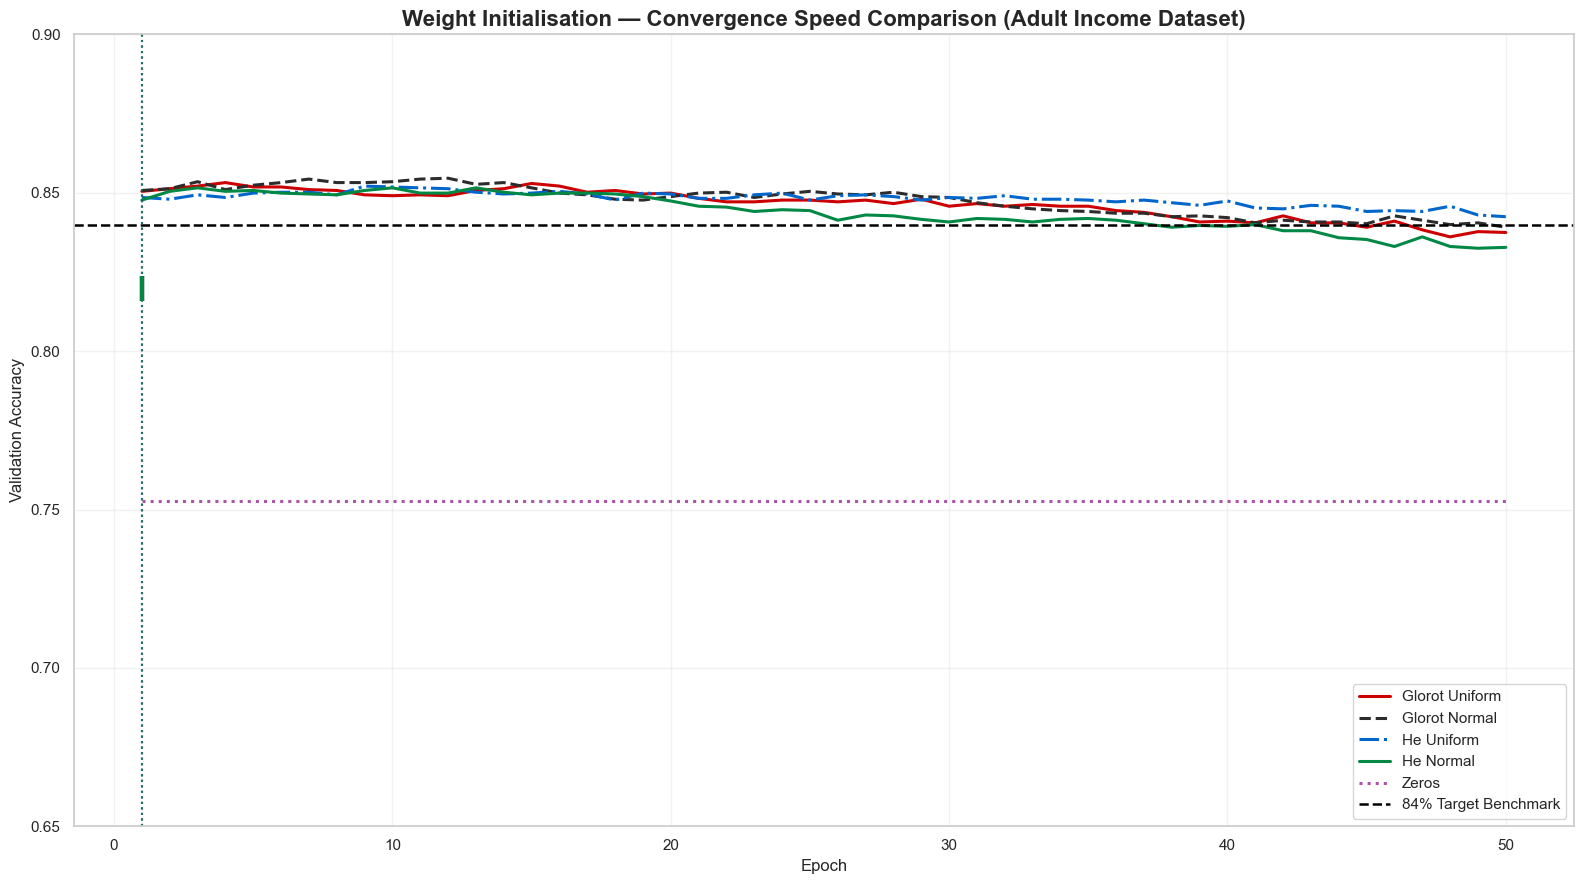

In [94]:
# Plot validation accuracy for all initializers

plt.figure(figsize=(16, 9))

initializer_styles = {
    "Glorot Uniform": {
        "color": "#CC0000",
        "linestyle": "-"
    },
    "Glorot Normal": {
        "color": "#2C2C2C",
        "linestyle": "--"
    },
    "He Uniform": {
        "color": "#0066CC",
        "linestyle": "-."
    },
    "He Normal": {
        "color": "#008844",
        "linestyle": "-"
    },
    "Zeros": {
        "color": "#AA55AA",
        "linestyle": ":"
    }
}

for initializer_name, history in initializer_histories.items():

    epochs = range(
        1,
        len(history.history["val_accuracy"]) + 1
    )

    style = initializer_styles[
        initializer_name
    ]

    plt.plot(
        epochs,
        history.history["val_accuracy"],
        label=initializer_name,
        color=style["color"],
        linestyle=style["linestyle"],
        linewidth=2.2
    )

# Target benchmark
plt.axhline(
    y=0.84,
    color="black",
    linestyle="--",
    linewidth=1.8,
    label="84% Target Benchmark"
)

# Mark first epoch crossing 82%
for initializer_name, crossing_epoch in (
    convergence_information.items()
):
    if crossing_epoch is not None:

        marker_color = initializer_styles[
            initializer_name
        ]["color"]

        plt.axvline(
            x=crossing_epoch,
            color=marker_color,
            linestyle=":",
            alpha=0.55
        )

        plt.plot(
            crossing_epoch,
            0.82,
            marker="|",
            markersize=18,
            markeredgewidth=3,
            color=marker_color
        )

plt.title(
    "Weight Initialisation — Convergence Speed Comparison "
    "(Adult Income Dataset)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.ylim(0.65, 0.90)
plt.grid(True, alpha=0.25)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

### Convergence-Speed Interpretation

The first epoch crossing 82% validation accuracy indicates convergence speed.

With ReLU hidden layers, He initialization is theoretically well matched because it compensates for ReLU setting negative activations to zero.

Glorot initialization can still perform well, but it was originally designed to preserve variance across activations such as Tanh and Sigmoid.

The zero-initialized model is expected to remain close to the majority-class baseline because its hidden neurons cannot break symmetry.

## 4.5 Zeros Initialization Failure Demonstration

The zero-initialized model will be examined separately.

Its training loss and validation accuracy are plotted together to show that the model cannot learn useful independent hidden-neuron representations.

# Plot zeros-model training loss and validation accuracy


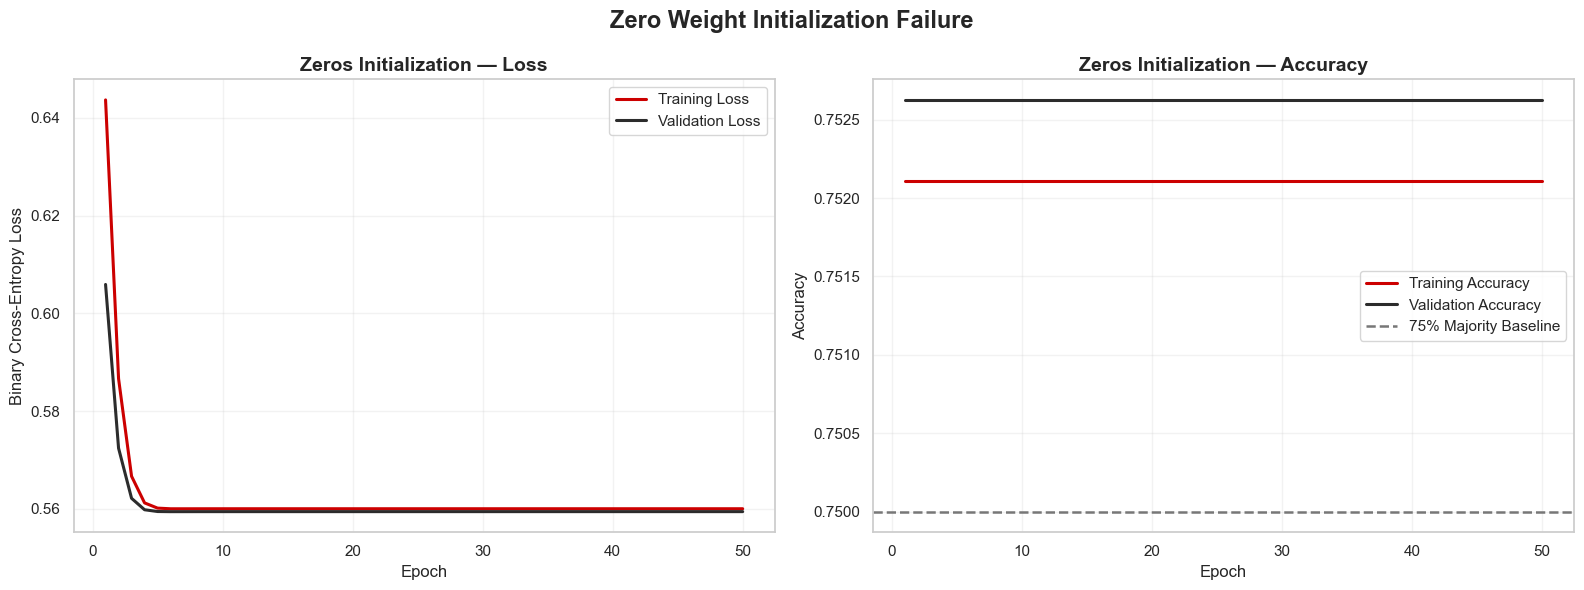

In [95]:
# Plot zeros-model training loss and validation accuracy

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

epochs_zeros = range(
    1,
    len(history_zeros.history["loss"]) + 1
)

# Training loss
axes[0].plot(
    epochs_zeros,
    history_zeros.history["loss"],
    color="#CC0000",
    linewidth=2.2,
    label="Training Loss"
)

axes[0].plot(
    epochs_zeros,
    history_zeros.history["val_loss"],
    color="#2C2C2C",
    linewidth=2.2,
    label="Validation Loss"
)

axes[0].set_title(
    "Zeros Initialization — Loss",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Cross-Entropy Loss")
axes[0].grid(True, alpha=0.25)
axes[0].legend()

# Validation accuracy
axes[1].plot(
    epochs_zeros,
    history_zeros.history["accuracy"],
    color="#CC0000",
    linewidth=2.2,
    label="Training Accuracy"
)

axes[1].plot(
    epochs_zeros,
    history_zeros.history["val_accuracy"],
    color="#2C2C2C",
    linewidth=2.2,
    label="Validation Accuracy"
)

axes[1].axhline(
    y=0.75,
    color="#777777",
    linestyle="--",
    linewidth=1.8,
    label="75% Majority Baseline"
)

axes[1].set_title(
    "Zeros Initialization — Accuracy",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True, alpha=0.25)
axes[1].legend()

fig.suptitle(
    "Zero Weight Initialization Failure",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# Evaluate prediction distribution of zero model


In [96]:
# Evaluate prediction distribution of zero model

zeros_probabilities = model_zeros.predict(
    X_test,
    verbose=0
).flatten()

zeros_predictions = (
    zeros_probabilities > 0.5
).astype(int)

unique_classes, prediction_counts = np.unique(
    zeros_predictions,
    return_counts=True
)

zeros_prediction_distribution = pd.DataFrame({
    "Predicted Class": unique_classes,
    "Count": prediction_counts
})

display(zeros_prediction_distribution)

print(
    "Mean predicted probability:",
    zeros_probabilities.mean()
)

,Predicted Class,Count
0,0,9045


Mean predicted probability: 0.24579336


### Why Zero Initialization Fails

When every hidden-layer weight starts at zero, all neurons receive identical inputs and produce identical outputs.

During backpropagation:

- They receive identical gradients.
- They update by identical amounts.
- They remain identical after every epoch.

The network therefore cannot learn different features in different neurons.

The model may output nearly the same probability for every record. Because approximately 75% of the dataset belongs to class 0, this can result in accuracy near the majority-class baseline even though the model has not learned meaningful patterns.

This demonstrates why weight initialization is a fundamental part of neural-network training.

## 4.6 Initial vs Trained Weight Distributions

We stored the initial first-layer weights of the He Normal and Glorot Uniform models before training.

We will now extract their trained weights and compare all four distributions:

1. He Normal before training
2. He Normal after training
3. Glorot Uniform before training
4. Glorot Uniform after training

# Extract trained first-layer weights


In [97]:
# Extract trained first-layer weights

he_normal_weights_after = (
    model_he_normal
    .get_layer("Hidden_Layer_1")
    .get_weights()[0]
    .copy()
)

glorot_uniform_weights_after = (
    model_glorot_uniform
    .get_layer("Hidden_Layer_1")
    .get_weights()[0]
    .copy()
)

print("Trained weights extracted successfully!")

Trained weights extracted successfully!


# Compare before and after weight statistics


In [98]:
# Compare before and after weight statistics

weight_distribution_statistics = pd.DataFrame({
    "Distribution": [
        "He Normal — Before",
        "He Normal — After",
        "Glorot Uniform — Before",
        "Glorot Uniform — After"
    ],
    "Mean": [
        he_normal_weights_before.mean(),
        he_normal_weights_after.mean(),
        glorot_uniform_weights_before.mean(),
        glorot_uniform_weights_after.mean()
    ],
    "Standard Deviation": [
        he_normal_weights_before.std(),
        he_normal_weights_after.std(),
        glorot_uniform_weights_before.std(),
        glorot_uniform_weights_after.std()
    ],
    "Minimum": [
        he_normal_weights_before.min(),
        he_normal_weights_after.min(),
        glorot_uniform_weights_before.min(),
        glorot_uniform_weights_after.min()
    ],
    "Maximum": [
        he_normal_weights_before.max(),
        he_normal_weights_after.max(),
        glorot_uniform_weights_before.max(),
        glorot_uniform_weights_after.max()
    ]
})

display(weight_distribution_statistics)

,Distribution,Mean,Standard Deviation,Minimum,Maximum
0,He Normal — Before,-0.001395,0.157403,-0.359151,0.359140
1,He Normal — After,0.004187,0.357223,-1.339056,1.549828
2,Glorot Uniform — Before,0.000263,0.098304,-0.169839,0.169835
3,Glorot Uniform — After,0.001987,0.320897,-1.292624,1.382267


# Plot initial and trained weight distributions


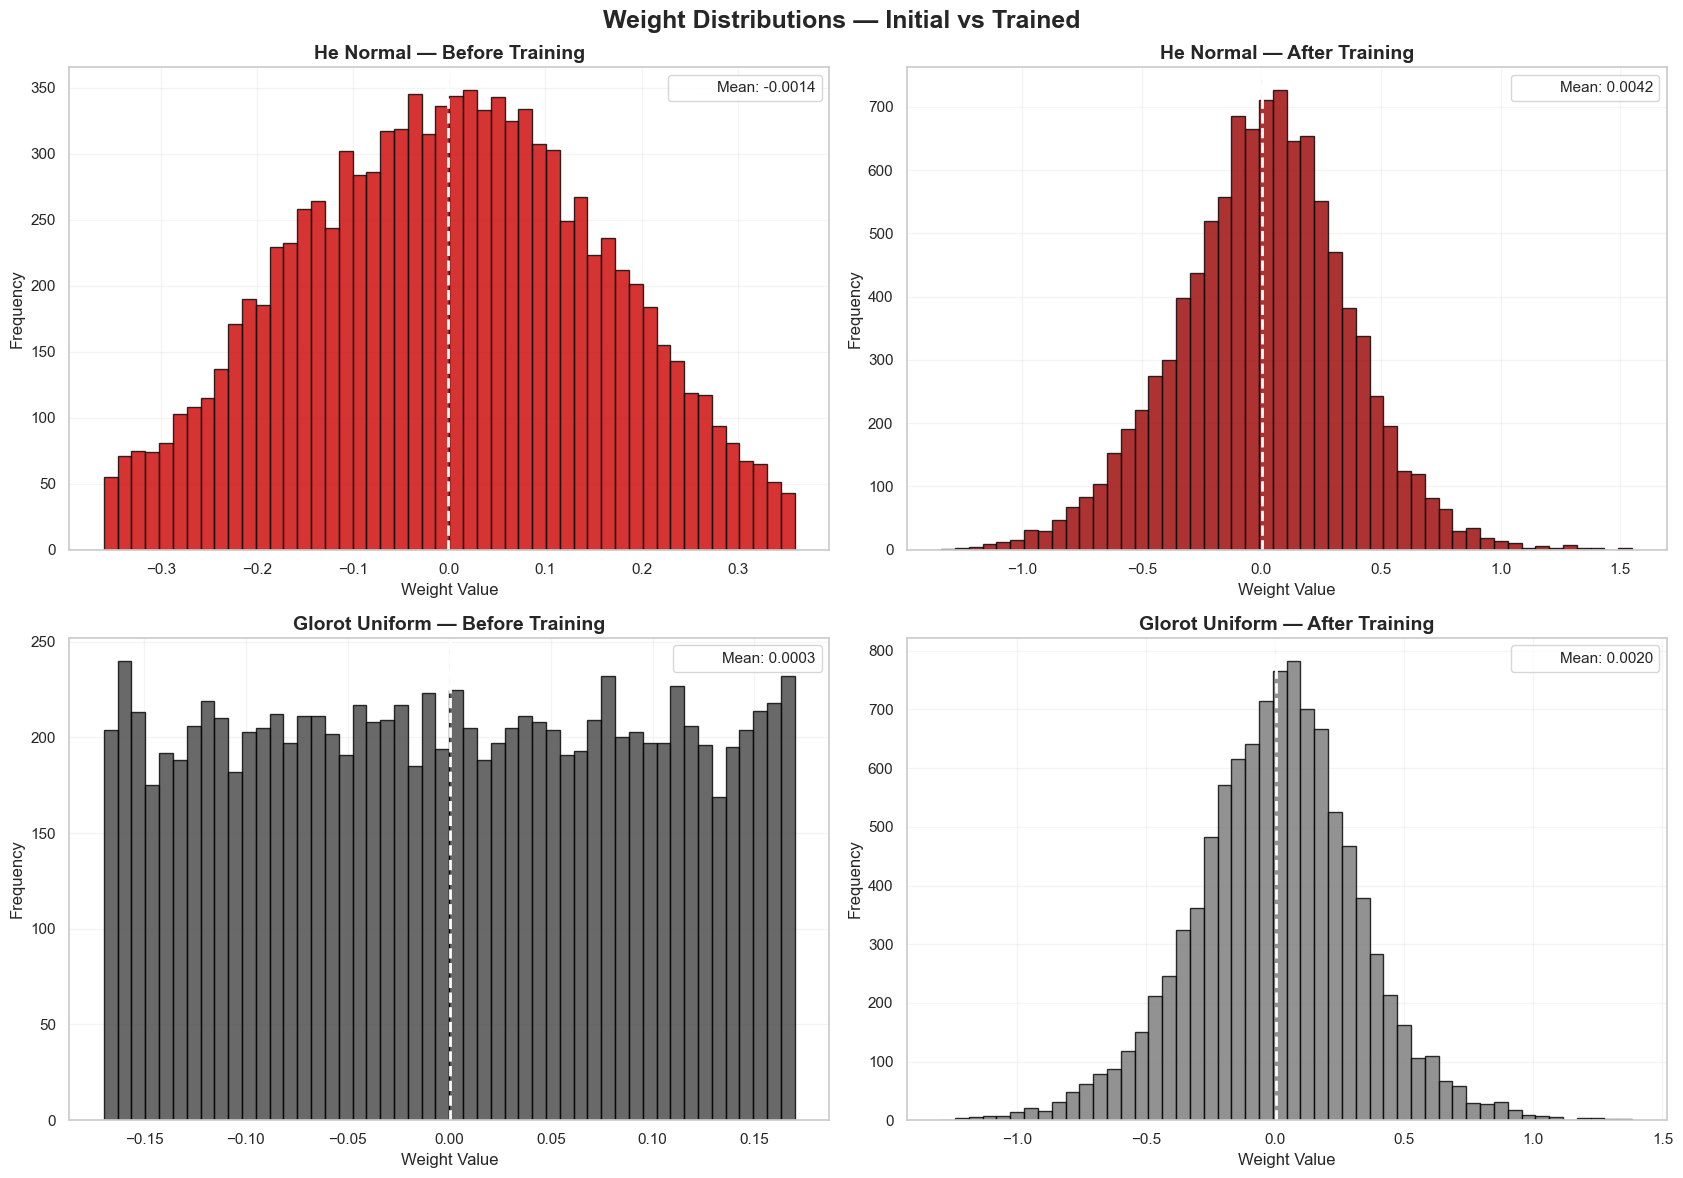

In [99]:
# Plot initial and trained weight distributions

fig, axes = plt.subplots(
    2,
    2,
    figsize=(17, 12)
)

distribution_data = [
    (
        axes[0, 0],
        he_normal_weights_before.flatten(),
        "He Normal — Before Training",
        "#CC0000"
    ),
    (
        axes[0, 1],
        he_normal_weights_after.flatten(),
        "He Normal — After Training",
        "#990000"
    ),
    (
        axes[1, 0],
        glorot_uniform_weights_before.flatten(),
        "Glorot Uniform — Before Training",
        "#444444"
    ),
    (
        axes[1, 1],
        glorot_uniform_weights_after.flatten(),
        "Glorot Uniform — After Training",
        "#777777"
    )
]

for axis, weights, title, color in distribution_data:

    axis.hist(
        weights,
        bins=50,
        color=color,
        edgecolor="black",
        alpha=0.80
    )

    axis.axvline(
        x=weights.mean(),
        color="white",
        linestyle="--",
        linewidth=2,
        label=f"Mean: {weights.mean():.4f}"
    )

    axis.set_title(
        title,
        fontsize=14,
        fontweight="bold"
    )

    axis.set_xlabel("Weight Value")
    axis.set_ylabel("Frequency")
    axis.grid(True, alpha=0.20)
    axis.legend()

fig.suptitle(
    "Weight Distributions — Initial vs Trained",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Weight-Distribution Interpretation

Before training, the distributions follow the pattern determined by their initializers.

- He Normal generally produces a wider distribution because it uses variance `2 / fan_in`.
- Glorot Uniform generally produces a narrower bounded distribution using the input and output sizes.

After training, backpropagation changes the weights to reduce the classification loss.

Therefore, the trained distributions may:

- Spread
- Shift
- Become less symmetric
- Develop larger positive or negative values

The initializer only determines the starting point. Backpropagation reshapes the weights during learning.

# Calculate final validation performance for all initializers


In [100]:
# Calculate final validation performance for all initializers

initializer_summary_rows = []

for initializer_name, history in initializer_histories.items():

    model = initializer_models[
        initializer_name
    ]

    val_f1 = calculate_validation_f1(
        model,
        X_validation,
        y_validation
    )

    initializer_summary_rows.append({
        "Initializer": initializer_name,
        "Final Training Accuracy":
            history.history["accuracy"][-1],
        "Final Validation Accuracy":
            history.history["val_accuracy"][-1],
        "Class-1 Validation F1": val_f1,
        "First Epoch >= 82%":
            first_epoch_above(
                history,
                threshold=0.82
            )
    })

initializer_results = pd.DataFrame(
    initializer_summary_rows
)

display(
    initializer_results.style.format({
        "Final Training Accuracy": "{:.4f}",
        "Final Validation Accuracy": "{:.4f}",
        "Class-1 Validation F1": "{:.4f}"
    })
)

,Initializer,Final Training Accuracy,Final Validation Accuracy,Class-1 Validation F1,First Epoch >= 82%
0,Glorot Uniform,0.8881,0.8375,0.6432,1.000000
1,Glorot Normal,0.8890,0.8391,0.6348,1.000000
2,He Uniform,0.8906,0.8425,0.6486,1.000000
3,He Normal,0.8914,0.8328,0.6248,1.000000
4,Zeros,0.7521,0.7526,0.0000,nan


# Select best initializer using class-1 validation F1-score


In [101]:
# Select best initializer using class-1 validation F1-score

best_initializer_row = initializer_results.loc[
    initializer_results[
        "Class-1 Validation F1"
    ].idxmax()
]

print("Best Weight Initializer")
print("=" * 60)

print(
    "Initializer:",
    best_initializer_row["Initializer"]
)

print(
    f"Final Validation Accuracy: "
    f"{best_initializer_row['Final Validation Accuracy']:.4f}"
)

print(
    f"Class-1 Validation F1: "
    f"{best_initializer_row['Class-1 Validation F1']:.4f}"
)

print(
    "First Epoch >= 82%:",
    best_initializer_row["First Epoch >= 82%"]
)

Best Weight Initializer
Initializer: He Uniform
Final Validation Accuracy: 0.8425
Class-1 Validation F1: 0.6486
First Epoch >= 82%: 1.0


# Task 4 — Final Summary

Five weight-initialization techniques were compared:

- Glorot Uniform
- Glorot Normal
- He Uniform
- He Normal
- Zeros

### Main Findings

He initialization is theoretically well suited to ReLU because it uses variance `2 / fan_in`, compensating for ReLU setting approximately half of its outputs to zero.

Glorot initialization is designed to preserve activation and gradient variance using both `fan_in` and `fan_out`. It is commonly associated with Tanh and Sigmoid networks, although it can still perform well with ReLU.

Zero initialization fails because all hidden neurons remain symmetric. They receive identical gradients and cannot learn different features.

### Final Recommendation

For the current ReLU-based Adult Income ANN, He Normal or He Uniform should generally be preferred.

The final decision should use the results generated in this run, especially:

- Validation accuracy
- Class-1 F1-score
- Convergence speed

The best initializer from the experiment will be used as a strong configuration in the later PR 2 tasks.

# Task 5: Loss Functions

## Objective

Compare different loss functions for the Adult Income binary-classification problem:

1. Binary Cross-Entropy
2. Mean Squared Error
3. Weighted Binary Cross-Entropy
4. Focal Loss

The comparison focuses on class 1 (`>50K`) because it is the minority class.

## 5.1 Binary Cross-Entropy — Correct Loss

The baseline ANN uses Binary Cross-Entropy:

L = -[y log(p) + (1-y) log(1-p)]

Where:

- `y` is the true class: 0 or 1
- `p` is the probability predicted by the sigmoid output

Binary Cross-Entropy heavily penalizes confident incorrect predictions.

For example, if the true class is 0 but the model predicts a probability close to 1, then `log(1-p)` approaches negative infinity and the loss becomes very large.

BCE is the negative log-likelihood of a Bernoulli distribution. It is therefore the natural loss function for binary classification.

# Confirm the baseline loss function


In [102]:
# Confirm the baseline loss function

print("Baseline model loss:", model_base.loss)

if model_base.loss == "binary_crossentropy":
    print("Confirmed: The baseline uses Binary Cross-Entropy.")
else:
    print("Check the baseline loss configuration.")

Baseline model loss: binary_crossentropy
Confirmed: The baseline uses Binary Cross-Entropy.


## 5.2 Per-Epoch Class-1 F1 Callback

Keras records loss and accuracy automatically, but it does not record the class-1 F1-score by default.

The following callback calculates validation Precision, Recall and F1-score after each epoch.

In [103]:
# Custom callback for validation class-1 metrics

class ValidationMetricsCallback(keras.callbacks.Callback):

    def __init__(self, X_val, y_val):
        super().__init__()

        self.X_val = np.asarray(
            X_val,
            dtype=np.float32
        )

        self.y_val = np.asarray(
            y_val
        ).reshape(-1)

        self.precision_scores = []
        self.recall_scores = []
        self.f1_scores = []

    def on_epoch_end(self, epoch, logs=None):

        probabilities = self.model.predict(
            self.X_val,
            verbose=0
        ).flatten()

        predictions = (
            probabilities > 0.5
        ).astype(int)

        precision = precision_score(
            self.y_val,
            predictions,
            zero_division=0
        )

        recall = recall_score(
            self.y_val,
            predictions,
            zero_division=0
        )

        f1 = f1_score(
            self.y_val,
            predictions,
            zero_division=0
        )

        self.precision_scores.append(precision)
        self.recall_scores.append(recall)
        self.f1_scores.append(f1)


print("ValidationMetricsCallback created successfully!")

ValidationMetricsCallback created successfully!


In [104]:
# Use the same validation portion as validation_split=0.1

validation_size = int(
    len(X_train) * 0.1
)

if hasattr(X_train, "iloc"):

    X_task5_train = X_train.iloc[
        :-validation_size
    ]

    y_task5_train = y_train.iloc[
        :-validation_size
    ]

    X_task5_val = X_train.iloc[
        -validation_size:
    ]

    y_task5_val = y_train.iloc[
        -validation_size:
    ]

else:

    X_task5_train = X_train[
        :-validation_size
    ]

    y_task5_train = y_train[
        :-validation_size
    ]

    X_task5_val = X_train[
        -validation_size:
    ]

    y_task5_val = y_train[
        -validation_size:
    ]

print("Task 5 training shape  :", X_task5_train.shape)
print("Task 5 validation shape:", X_task5_val.shape)

Task 5 training shape  : (32560, 80)
Task 5 validation shape: (3617, 80)


## 5.3 BCE vs MSE Experiment

Mean Squared Error treats the sigmoid output as a continuous regression value.

Its output-layer gradient contains an additional sigmoid derivative:

σ(x)(1-σ(x))

This derivative becomes very small when sigmoid saturates near 0 or 1.

For BCE with sigmoid, the simplified gradient is `(p-y)`, which provides a stronger learning signal for confident incorrect predictions.

In [105]:
# Build controlled BCE and MSE models

tf.keras.utils.set_random_seed(42)

model_bce_comparison = build_ann(
    input_dim=X_train.shape[1],
    activation="relu",
    initializer="he_normal",
    loss="binary_crossentropy"
)

tf.keras.utils.set_random_seed(42)

model_mse = build_ann(
    input_dim=X_train.shape[1],
    activation="relu",
    initializer="he_normal",
    loss="mean_squared_error"
)

print("BCE and MSE comparison models created!")

BCE and MSE comparison models created!


In [106]:
# Create callbacks

bce_metrics_callback = ValidationMetricsCallback(
    X_task5_val,
    y_task5_val
)

mse_metrics_callback = ValidationMetricsCallback(
    X_task5_val,
    y_task5_val
)

In [107]:
# Train BCE comparison model

history_bce_comparison = model_bce_comparison.fit(
    X_task5_train,
    y_task5_train,
    validation_data=(
        X_task5_val,
        y_task5_val
    ),
    epochs=50,
    batch_size=64,
    callbacks=[bce_metrics_callback],
    verbose=1
)

print("BCE comparison model trained!")

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8454 - loss: 0.3332 - val_accuracy: 0.8488 - val_loss: 0.3237
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8535 - loss: 0.3145 - val_accuracy: 0.8510 - val_loss: 0.3217
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8552 - loss: 0.3105 - val_accuracy: 0.8529 - val_loss: 0.3207
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8567 - loss: 0.3072 - val_accuracy: 0.8524 - val_loss: 0.3206
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8584 - loss: 0.3041 - val_accuracy: 0.8518 - val_loss: 0.3203
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8601 - loss: 0.3012 - val_accuracy: 0.8515 - val_loss: 0.3204
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8607 - loss: 0.2984 - val_accuracy: 0.8496 - val_loss: 0.3207
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8625 - loss: 0.2957 - val_accuracy: 0.

In [108]:
# Train MSE model

history_mse = model_mse.fit(
    X_task5_train,
    y_task5_train,
    validation_data=(
        X_task5_val,
        y_task5_val
    ),
    epochs=50,
    batch_size=64,
    callbacks=[mse_metrics_callback],
    verbose=1
)

print("MSE model trained!")

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8464 - loss: 0.1069 - val_accuracy: 0.8502 - val_loss: 0.1046
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8536 - loss: 0.1008 - val_accuracy: 0.8504 - val_loss: 0.1034
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8568 - loss: 0.0992 - val_accuracy: 0.8510 - val_loss: 0.1028
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8592 - loss: 0.0978 - val_accuracy: 0.8549 - val_loss: 0.1024
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8609 - loss: 0.0966 - val_accuracy: 0.8532 - val_loss: 0.1021
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8622 - loss: 0.0956 - val_accuracy: 0.8535 - val_loss: 0.1021
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8637 - loss: 0.0946 - val_accuracy: 0.8529 - val_loss: 0.1020
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8655 - loss: 0.0937 - val_accuracy: 0.

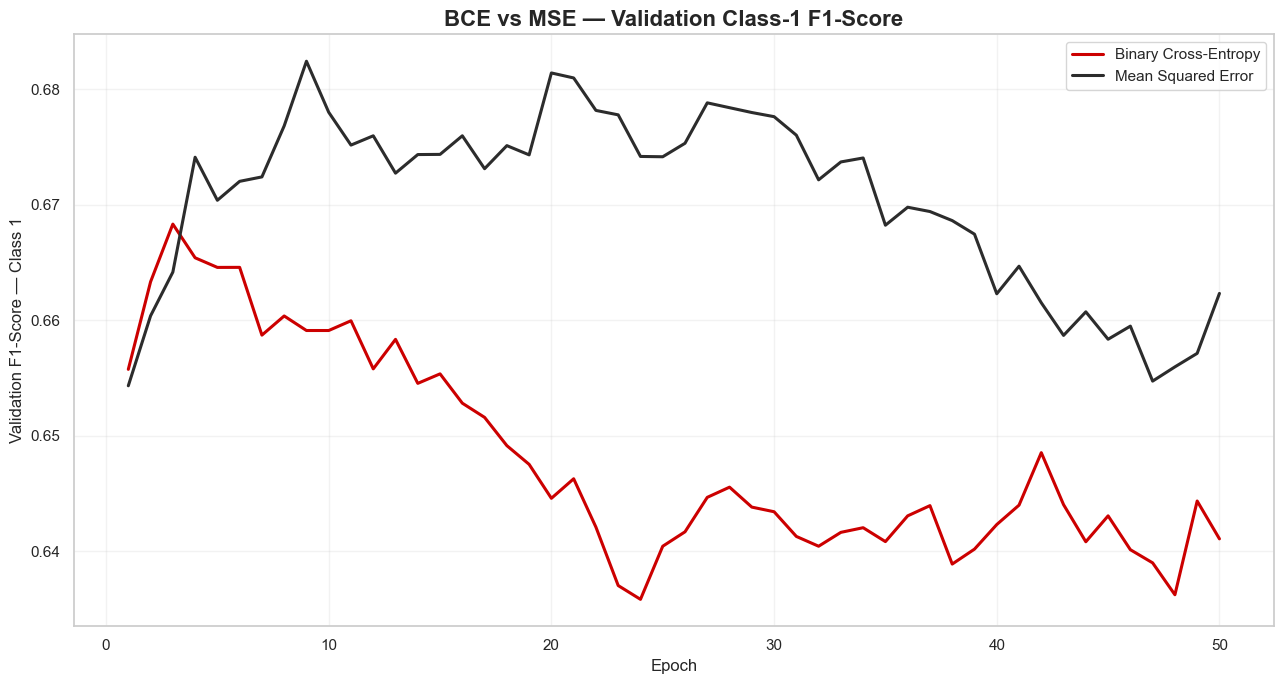

In [109]:
# Plot validation class-1 F1-score: BCE vs MSE

epochs = range(
    1,
    len(bce_metrics_callback.f1_scores) + 1
)

plt.figure(figsize=(13, 7))

plt.plot(
    epochs,
    bce_metrics_callback.f1_scores,
    color="#CC0000",
    linewidth=2.2,
    label="Binary Cross-Entropy"
)

plt.plot(
    epochs,
    mse_metrics_callback.f1_scores,
    color="#2C2C2C",
    linewidth=2.2,
    label="Mean Squared Error"
)

plt.title(
    "BCE vs MSE — Validation Class-1 F1-Score",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Epoch")
plt.ylabel("Validation F1-Score — Class 1")
plt.grid(True, alpha=0.25)
plt.legend()

plt.tight_layout()
plt.show()

## 5.4 Weighted Binary Cross-Entropy

The Adult Income dataset contains approximately:

- 75% class 0
- 25% class 1

Weighted BCE assigns a larger penalty to mistakes on the minority class.

This can improve class-1 Recall, although Precision may decrease.

In [110]:
# Import and calculate balanced class weights

from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=np.asarray(y_task5_train)
)

class_weight_dict = {
    0: float(weights[0]),
    1: float(weights[1])
}

print("Calculated class weights:")
print(class_weight_dict)

Calculated class weights:
{0: 0.664788272285516, 1: 2.0170982530045842}


In [111]:
# Build weighted BCE model

tf.keras.utils.set_random_seed(42)

model_wbce = build_ann(
    input_dim=X_train.shape[1],
    activation="relu",
    initializer="he_normal",
    loss="binary_crossentropy"
)

wbce_metrics_callback = ValidationMetricsCallback(
    X_task5_val,
    y_task5_val
)

print("Weighted BCE model created!")

Weighted BCE model created!


In [112]:
# Train weighted BCE model

history_wbce = model_wbce.fit(
    X_task5_train,
    y_task5_train,
    validation_data=(
        X_task5_val,
        y_task5_val
    ),
    epochs=50,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[wbce_metrics_callback],
    verbose=1
)

print("Weighted BCE model trained!")

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8009 - loss: 0.3913 - val_accuracy: 0.8087 - val_loss: 0.3828
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8110 - loss: 0.3708 - val_accuracy: 0.8092 - val_loss: 0.3840
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8130 - loss: 0.3655 - val_accuracy: 0.8090 - val_loss: 0.3823
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8151 - loss: 0.3613 - val_accuracy: 0.8073 - val_loss: 0.3822
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8163 - loss: 0.3577 - val_accuracy: 0.8076 - val_loss: 0.3812
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8182 - loss: 0.3542 - val_accuracy: 0.8084 - val_loss: 0.3810
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8196 - loss: 0.3508 - val_accuracy: 0.8070 - val_loss: 0.3811
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8219 - loss: 0.3475 - val_accuracy: 0.

In [113]:
# Reusable binary-model evaluation function

from sklearn.metrics import roc_auc_score, roc_curve

def evaluate_binary_model(model, X_data, y_data):

    probabilities = model.predict(
        X_data,
        verbose=0
    ).flatten()

    predictions = (
        probabilities > 0.5
    ).astype(int)

    return {
        "Accuracy": accuracy_score(
            y_data,
            predictions
        ),
        "Precision": precision_score(
            y_data,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_data,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_data,
            predictions,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_data,
            probabilities
        ),
        "Probabilities": probabilities,
        "Predictions": predictions
    }


print("Evaluation function created successfully!")

Evaluation function created successfully!


In [114]:
# Evaluate unweighted and weighted BCE models

bce_test_metrics = evaluate_binary_model(
    model_bce_comparison,
    X_test,
    y_test
)

wbce_test_metrics = evaluate_binary_model(
    model_wbce,
    X_test,
    y_test
)

bce_wbce_comparison = pd.DataFrame({
    "Metric": [
        "Precision — Class 1",
        "Recall — Class 1",
        "F1 — Class 1"
    ],
    "BCE": [
        bce_test_metrics["Precision"],
        bce_test_metrics["Recall"],
        bce_test_metrics["F1"]
    ],
    "Weighted BCE": [
        wbce_test_metrics["Precision"],
        wbce_test_metrics["Recall"],
        wbce_test_metrics["F1"]
    ]
})

display(
    bce_wbce_comparison.style.format({
        "BCE": "{:.4f}",
        "Weighted BCE": "{:.4f}"
    })
)

,Metric,BCE,Weighted BCE
0,Precision — Class 1,0.7003,0.5691
1,Recall — Class 1,0.5919,0.8104
2,F1 — Class 1,0.6415,0.6686


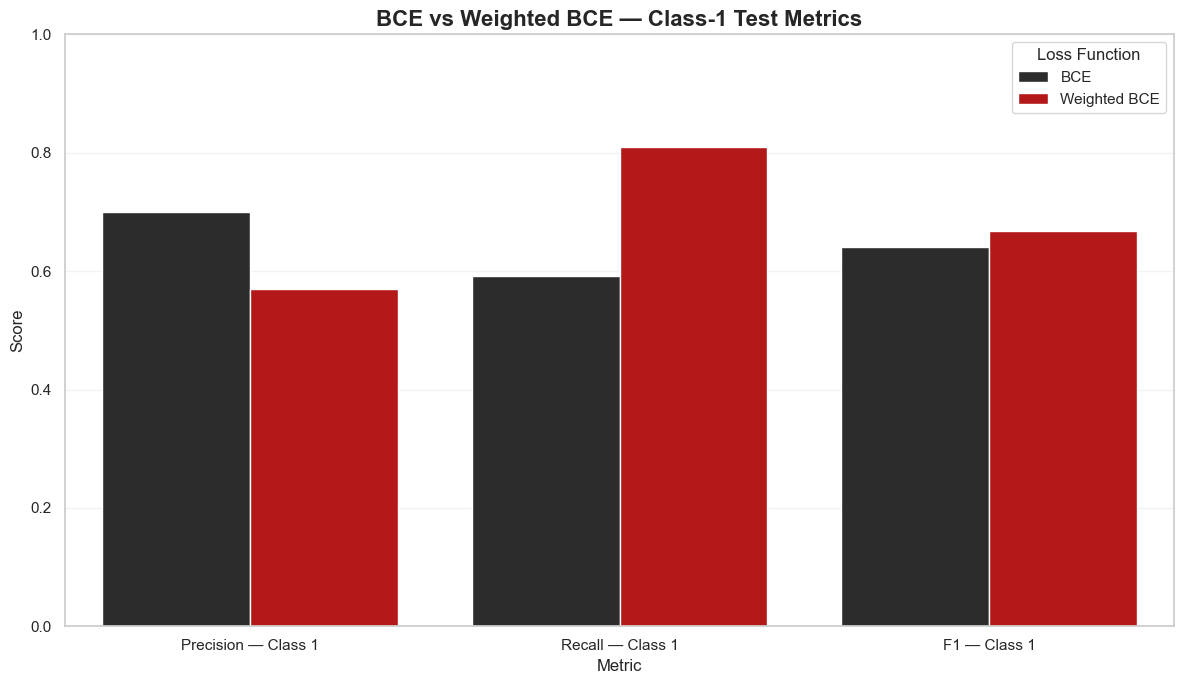

In [115]:
# Plot BCE vs Weighted BCE metrics

comparison_long = bce_wbce_comparison.melt(
    id_vars="Metric",
    var_name="Loss Function",
    value_name="Score"
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=comparison_long,
    x="Metric",
    y="Score",
    hue="Loss Function",
    palette=["#2C2C2C", "#CC0000"]
)

plt.title(
    "BCE vs Weighted BCE — Class-1 Test Metrics",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

### Weighted BCE Interpretation

Weighted BCE increases the loss contribution of minority-class observations.

It usually improves class-1 Recall because the model receives a larger penalty when it incorrectly predicts a high-income person as class 0.

This improvement may come at the cost of lower Precision because the model can predict class 1 more frequently.

Weighted BCE is useful when missing a true high-income person is more costly than producing a false-positive prediction.

## 5.5 Focal Loss

Focal Loss was introduced for classification problems with severe class imbalance.

It reduces the contribution of easy, correctly classified observations and focuses training on difficult or misclassified examples.

The focusing parameter `gamma` controls how strongly easy examples are down-weighted.

In [117]:
# Custom Focal Loss

def focal_loss(gamma=2.0, alpha=0.25):

    def loss(y_true, y_pred):

        y_true = tf.cast(
            y_true,
            tf.float32
        )

        y_pred = tf.clip_by_value(
            y_pred,
            1e-7,
            1.0 - 1e-7
        )

        bce = (
            -y_true * tf.math.log(y_pred)
            - (1.0 - y_true)
            * tf.math.log(1.0 - y_pred)
        )

        focal_weight = (
            alpha
            * y_true
            * tf.pow(1.0 - y_pred, gamma)
            +
            (1.0 - alpha)
            * (1.0 - y_true)
            * tf.pow(y_pred, gamma)
        )

        return tf.reduce_mean(
            focal_weight * bce
        )

    return loss


print("Custom Focal Loss created successfully!")

Custom Focal Loss created successfully!


In [118]:
# Build Focal Loss model

tf.keras.utils.set_random_seed(42)

model_focal = build_ann(
    input_dim=X_train.shape[1],
    activation="relu",
    initializer="he_normal",
    loss=focal_loss(
        gamma=2.0,
        alpha=0.25
    )
)

focal_metrics_callback = ValidationMetricsCallback(
    X_task5_val,
    y_task5_val
)

print("Focal Loss model created!")

Focal Loss model created!


In [119]:
# Train Focal Loss model

history_focal = model_focal.fit(
    X_task5_train,
    y_task5_train,
    validation_data=(
        X_task5_val,
        y_task5_val
    ),
    epochs=50,
    batch_size=64,
    callbacks=[focal_metrics_callback],
    verbose=1
)

print("Focal Loss model trained!")

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8202 - loss: 0.0345 - val_accuracy: 0.8175 - val_loss: 0.0337
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8280 - loss: 0.0326 - val_accuracy: 0.8186 - val_loss: 0.0335
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8307 - loss: 0.0320 - val_accuracy: 0.8200 - val_loss: 0.0334
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8325 - loss: 0.0316 - val_accuracy: 0.8200 - val_loss: 0.0333
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8344 - loss: 0.0312 - val_accuracy: 0.8208 - val_loss: 0.0332
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8359 - loss: 0.0308 - val_accuracy: 0.8225 - val_loss: 0.0332
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8370 - loss: 0.0305 - val_accuracy: 0.8228 - val_loss: 0.0332
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8394 - loss: 0.0302 - val_accuracy: 0.

In [120]:
# Evaluate MSE and Focal Loss models

mse_test_metrics = evaluate_binary_model(
    model_mse,
    X_test,
    y_test
)

focal_test_metrics = evaluate_binary_model(
    model_focal,
    X_test,
    y_test
)

loss_metrics_comparison = pd.DataFrame({
    "Model": [
        "BCE",
        "Weighted BCE",
        "MSE",
        "Focal Loss"
    ],
    "Precision — Class 1": [
        bce_test_metrics["Precision"],
        wbce_test_metrics["Precision"],
        mse_test_metrics["Precision"],
        focal_test_metrics["Precision"]
    ],
    "Recall — Class 1": [
        bce_test_metrics["Recall"],
        wbce_test_metrics["Recall"],
        mse_test_metrics["Recall"],
        focal_test_metrics["Recall"]
    ],
    "F1 — Class 1": [
        bce_test_metrics["F1"],
        wbce_test_metrics["F1"],
        mse_test_metrics["F1"],
        focal_test_metrics["F1"]
    ]
})

display(
    loss_metrics_comparison.style.format({
        "Precision — Class 1": "{:.4f}",
        "Recall — Class 1": "{:.4f}",
        "F1 — Class 1": "{:.4f}"
    }).highlight_max(
        subset=[
            "Recall — Class 1",
            "F1 — Class 1"
        ],
        color="#ffcccc"
    )
)

,Model,Precision — Class 1,Recall — Class 1,F1 — Class 1
0,BCE,0.7003,0.5919,0.6415
1,Weighted BCE,0.5691,0.8104,0.6686
2,MSE,0.6932,0.6521,0.6720
3,Focal Loss,0.7858,0.4188,0.5464


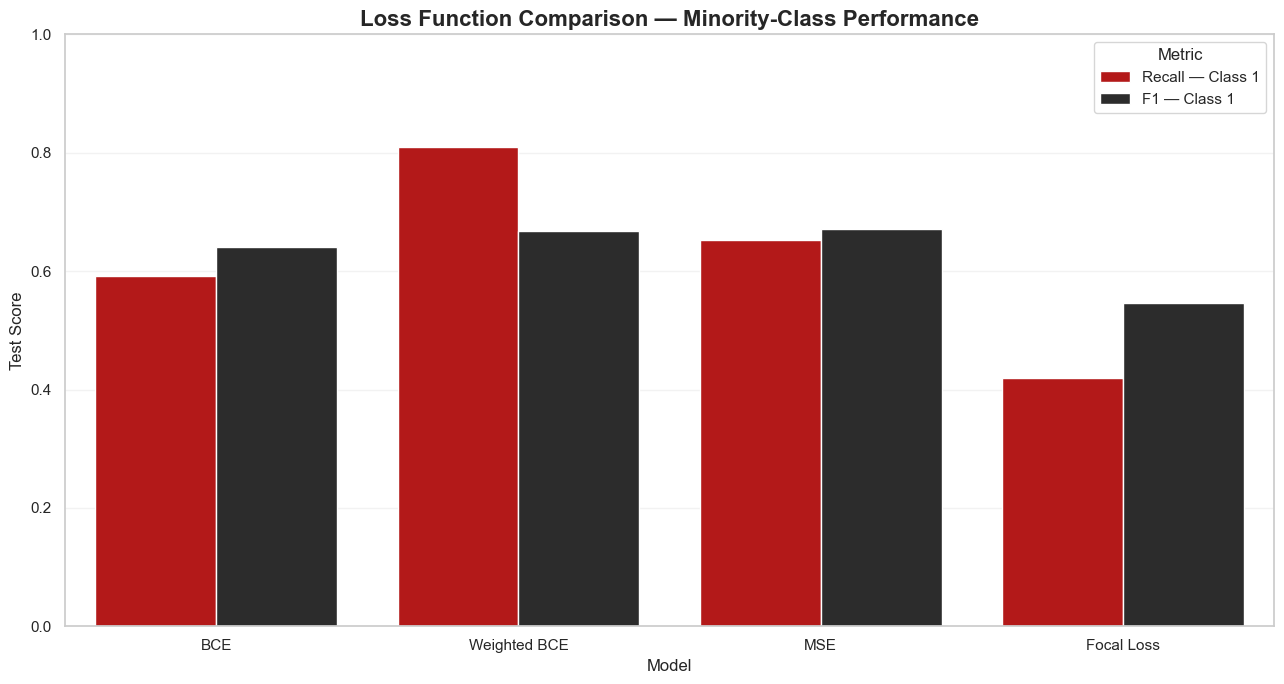

In [121]:
# Plot Recall and F1 comparison

loss_plot_data = loss_metrics_comparison.melt(
    id_vars="Model",
    value_vars=[
        "Recall — Class 1",
        "F1 — Class 1"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(13, 7))

sns.barplot(
    data=loss_plot_data,
    x="Model",
    y="Score",
    hue="Metric",
    palette=["#CC0000", "#2C2C2C"]
)

plt.title(
    "Loss Function Comparison — Minority-Class Performance",
    fontsize=16,
    fontweight="bold"
)

plt.ylim(0, 1)
plt.ylabel("Test Score")
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

In [122]:
# Complete loss-function summary

loss_summary = pd.DataFrame({
    "Loss Function": [
        "BCE",
        "Weighted BCE",
        "MSE (Classification)",
        "Focal Loss"
    ],
    "Simplified Formula": [
        "-[y log(p) + (1-y) log(1-p)]",
        "Class weight × BCE",
        "(y-p)^2",
        "Focal weight × BCE"
    ],
    "Best For": [
        "Standard binary classification",
        "Imbalanced binary classification",
        "Regression",
        "Hard examples and severe imbalance"
    ],
    "Imbalance Handling": [
        "No",
        "Yes — class weights",
        "No",
        "Yes — down-weights easy examples"
    ],
    "Class-1 F1 on Adult": [
        bce_test_metrics["F1"],
        wbce_test_metrics["F1"],
        mse_test_metrics["F1"],
        focal_test_metrics["F1"]
    ]
})

display(
    loss_summary.style.format({
        "Class-1 F1 on Adult": "{:.4f}"
    }).highlight_max(
        subset=["Class-1 F1 on Adult"],
        color="#ffcccc"
    )
)

,Loss Function,Simplified Formula,Best For,Imbalance Handling,Class-1 F1 on Adult
0,BCE,-[y log(p) + (1-y) log(1-p)],Standard binary classification,No,0.6415
1,Weighted BCE,Class weight × BCE,Imbalanced binary classification,Yes — class weights,0.6686
2,MSE (Classification),(y-p)^2,Regression,No,0.6720
3,Focal Loss,Focal weight × BCE,Hard examples and severe imbalance,Yes — down-weights easy examples,0.5464


In [123]:
# Determine the best loss function

best_loss_row = loss_summary.loc[
    loss_summary[
        "Class-1 F1 on Adult"
    ].idxmax()
]

print("Best Loss Function")
print("=" * 60)

print(
    "Loss:",
    best_loss_row["Loss Function"]
)

print(
    f"Class-1 Test F1: "
    f"{best_loss_row['Class-1 F1 on Adult']:.4f}"
)

Best Loss Function
Loss: MSE (Classification)
Class-1 Test F1: 0.6720


# Task 5 — Final Summary

Binary Cross-Entropy is the correct standard loss for binary classification because it directly models a Bernoulli probability.

MSE is not recommended because it treats classification as regression and can produce weak gradients when sigmoid saturates.

Weighted BCE increases the importance of the minority class and generally improves class-1 Recall, sometimes at the cost of Precision.

Focal Loss focuses learning on difficult examples by reducing the contribution of easy, correctly classified observations.

For production, select the loss with the strongest class-1 F1-score while also considering whether Recall or Precision is more important for the business problem.

# Task 6: Batch Normalization

## Objective

Build an ANN using Batch Normalization and compare it with the baseline model.

The canonical layer order is:

Dense (Linear) → Batch Normalization → Activation

We will also compare Batch Normalization before and after ReLU and inspect the learned gamma and beta parameters.

## 6.1 Why Batch Normalization?

During neural-network training, weight updates change the distribution of values received by later layers.

Batch Normalization standardizes pre-activation values within each mini-batch:

BN(x) = γ((x-μB) / √(σ²B+ε)) + β

Where:

- `μB` is the mini-batch mean
- `σ²B` is the mini-batch variance
- `γ` is a learned scale
- `β` is a learned shift

At inference time, Batch Normalization uses moving averages collected during training.

Potential benefits include:

- Faster convergence
- Reduced sensitivity to learning rate
- More stable gradients
- Mild regularization from noisy batch statistics

In [124]:
# Build canonical Batch Normalization model

model_bn = keras.Sequential(
    [
        layers.Input(
            shape=(X_train.shape[1],),
            name="Input_Layer"
        ),

        layers.Dense(
            128,
            activation=None,
            kernel_initializer="he_normal",
            name="Dense_1"
        ),

        layers.BatchNormalization(
            name="BatchNorm_1"
        ),

        layers.Activation(
            "relu",
            name="ReLU_1"
        ),

        layers.Dense(
            64,
            activation=None,
            kernel_initializer="he_normal",
            name="Dense_2"
        ),

        layers.BatchNormalization(
            name="BatchNorm_2"
        ),

        layers.Activation(
            "relu",
            name="ReLU_2"
        ),

        layers.Dense(
            1,
            activation="sigmoid",
            name="Output_Layer"
        )
    ],
    name="Canonical_BatchNorm_ANN"
)

model_bn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Canonical BatchNorm model created!")

Canonical BatchNorm model created!


In [125]:
# Display BatchNorm model architecture

model_bn.summary()

Model: "Canonical_BatchNorm_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Dense_1 (Dense)                 │ (None, 128)            │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_1                     │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ReLU_1 (Activation)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_2                     │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ReLU_2 (Activation)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,457 (76.00 KB)

 Trainable params: 19,073 (74.50 KB)

 Non-trainable params: 384 (1.50 KB)

### Batch Normalization Parameters

A Batch Normalization layer adds four parameters per neuron:

1. Gamma — trainable scale
2. Beta — trainable shift
3. Moving mean — non-trainable
4. Moving variance — non-trainable

Therefore:

- A 128-neuron BN layer adds `4 × 128 = 512` parameters.
- A 64-neuron BN layer adds `4 × 64 = 256` parameters.

Only gamma and beta are trainable.

In [126]:
# Train canonical BatchNorm model

history_bn = model_bn.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

print("BatchNorm model training completed!")

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8192 - loss: 0.3855 - val_accuracy: 0.8507 - val_loss: 0.3209
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8505 - loss: 0.3195 - val_accuracy: 0.8510 - val_loss: 0.3187
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8544 - loss: 0.3122 - val_accuracy: 0.8507 - val_loss: 0.3183
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8572 - loss: 0.3071 - val_accuracy: 0.8505 - val_loss: 0.3188
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8586 - loss: 0.3029 - val_accuracy: 0.8502 - val_loss: 0.3193
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8613 - loss: 0.2990 - val_accuracy: 0.8488 - val_loss: 0.3200
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8623 - loss: 0.2953 - val_accuracy: 0.8494 - val_loss: 0.3211
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8645 - loss: 0.2915 - val_accuracy: 0.

## 6.2 BatchNorm vs Baseline Training Dynamics

The following graphs compare:

- Training loss
- Validation loss
- Training accuracy
- Validation accuracy

A smaller training-validation gap indicates better generalization.

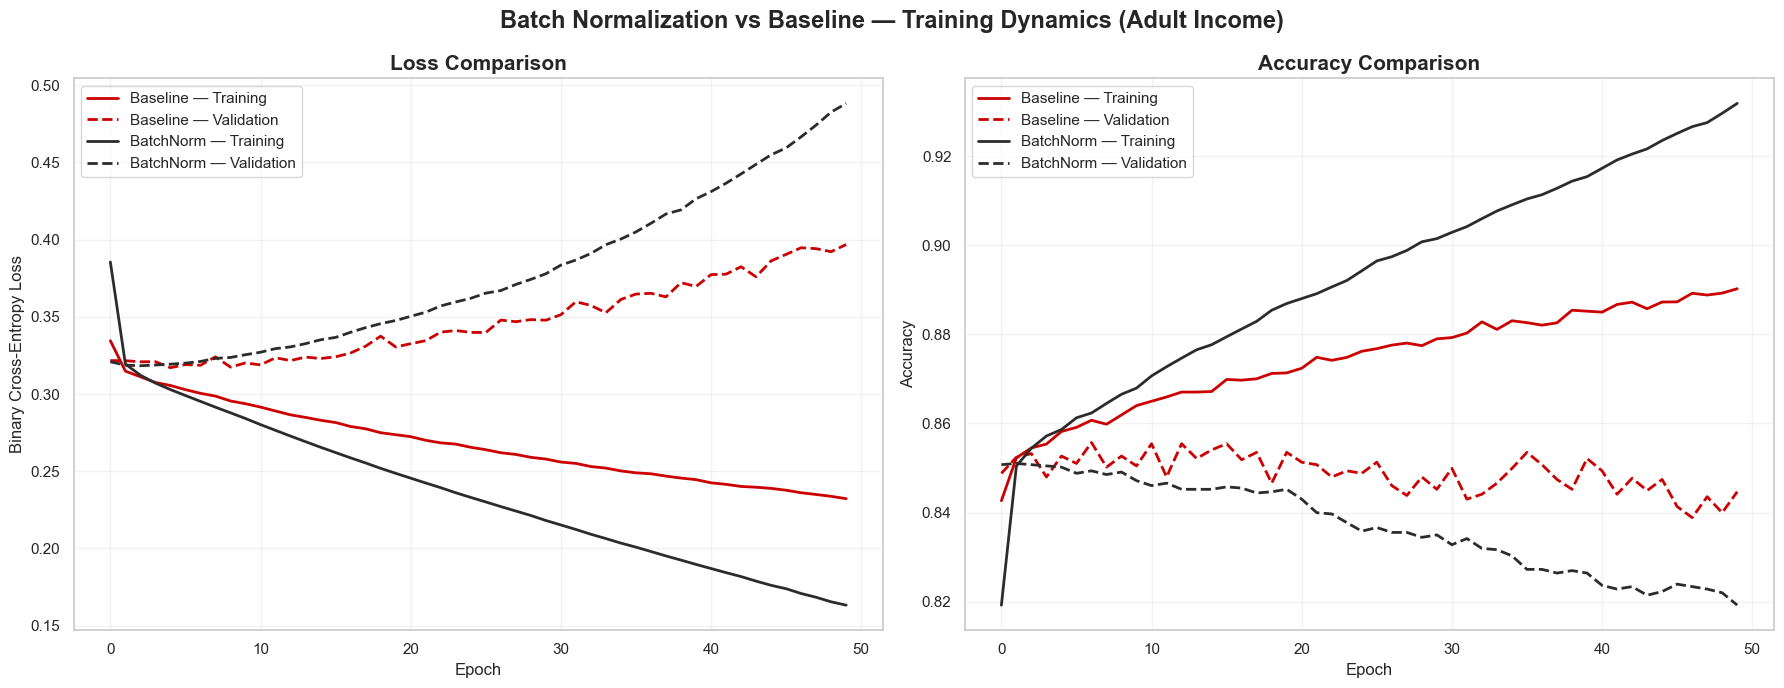

In [127]:
# Compare BatchNorm and baseline histories

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 7)
)

# Loss comparison
axes[0].plot(
    history_base.history["loss"],
    color="#CC0000",
    linestyle="-",
    linewidth=2,
    label="Baseline — Training"
)

axes[0].plot(
    history_base.history["val_loss"],
    color="#CC0000",
    linestyle="--",
    linewidth=2,
    label="Baseline — Validation"
)

axes[0].plot(
    history_bn.history["loss"],
    color="#2C2C2C",
    linestyle="-",
    linewidth=2,
    label="BatchNorm — Training"
)

axes[0].plot(
    history_bn.history["val_loss"],
    color="#2C2C2C",
    linestyle="--",
    linewidth=2,
    label="BatchNorm — Validation"
)

axes[0].set_title(
    "Loss Comparison",
    fontsize=15,
    fontweight="bold"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Cross-Entropy Loss")
axes[0].grid(True, alpha=0.25)
axes[0].legend()

# Accuracy comparison
axes[1].plot(
    history_base.history["accuracy"],
    color="#CC0000",
    linestyle="-",
    linewidth=2,
    label="Baseline — Training"
)

axes[1].plot(
    history_base.history["val_accuracy"],
    color="#CC0000",
    linestyle="--",
    linewidth=2,
    label="Baseline — Validation"
)

axes[1].plot(
    history_bn.history["accuracy"],
    color="#2C2C2C",
    linestyle="-",
    linewidth=2,
    label="BatchNorm — Training"
)

axes[1].plot(
    history_bn.history["val_accuracy"],
    color="#2C2C2C",
    linestyle="--",
    linewidth=2,
    label="BatchNorm — Validation"
)

axes[1].set_title(
    "Accuracy Comparison",
    fontsize=15,
    fontweight="bold"
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True, alpha=0.25)
axes[1].legend()

fig.suptitle(
    "Batch Normalization vs Baseline — "
    "Training Dynamics (Adult Income)",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [128]:
# Evaluate baseline and BatchNorm models

baseline_test_metrics = evaluate_binary_model(
    model_base,
    X_test,
    y_test
)

bn_test_metrics = evaluate_binary_model(
    model_bn,
    X_test,
    y_test
)

bn_comparison_table = pd.DataFrame({
    "Model": [
        "Baseline",
        "BatchNorm"
    ],
    "Test Accuracy": [
        baseline_test_metrics["Accuracy"],
        bn_test_metrics["Accuracy"]
    ],
    "Class-1 F1": [
        baseline_test_metrics["F1"],
        bn_test_metrics["F1"]
    ],
    "ROC-AUC": [
        baseline_test_metrics["ROC-AUC"],
        bn_test_metrics["ROC-AUC"]
    ]
})

display(
    bn_comparison_table.style.format({
        "Test Accuracy": "{:.4f}",
        "Class-1 F1": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

,Model,Test Accuracy,Class-1 F1,ROC-AUC
0,Baseline,0.8392,0.6604,0.8878
1,BatchNorm,0.8195,0.6168,0.8725


## 6.3 BatchNorm Position Experiment

Two architectures will be compared:

### Before Activation — Canonical

Dense → BatchNorm → ReLU

### After Activation

Dense → ReLU → BatchNorm

The original Batch Normalization paper places normalization before the activation. However, after-activation normalization can perform comparably on some datasets.

In [129]:
# Function for BatchNorm position experiment

def build_bn_position_model(position="before"):

    model = keras.Sequential()

    model.add(
        layers.Input(
            shape=(X_train.shape[1],)
        )
    )

    for units in [128, 64]:

        if position == "before":

            model.add(
                layers.Dense(
                    units,
                    activation=None,
                    kernel_initializer="he_normal"
                )
            )

            model.add(
                layers.BatchNormalization()
            )

            model.add(
                layers.Activation("relu")
            )

        elif position == "after":

            model.add(
                layers.Dense(
                    units,
                    activation="relu",
                    kernel_initializer="he_normal"
                )
            )

            model.add(
                layers.BatchNormalization()
            )

    model.add(
        layers.Dense(
            1,
            activation="sigmoid"
        )
    )

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


print("BatchNorm position function created!")

BatchNorm position function created!


In [130]:
# Build position models

tf.keras.utils.set_random_seed(42)

model_bn_before = build_bn_position_model(
    position="before"
)

tf.keras.utils.set_random_seed(42)

model_bn_after = build_bn_position_model(
    position="after"
)

print("Both BatchNorm position models created!")

Both BatchNorm position models created!


In [131]:
# Train BatchNorm-before-activation model

history_bn_before = model_bn_before.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

print("BatchNorm-before model trained!")

Epoch 1/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8391 - loss: 0.3445 - val_accuracy: 0.8438 - val_loss: 0.3228
Epoch 2/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8523 - loss: 0.3175 - val_accuracy: 0.8474 - val_loss: 0.3213
Epoch 3/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8552 - loss: 0.3110 - val_accuracy: 0.8499 - val_loss: 0.3210
Epoch 4/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8582 - loss: 0.3061 - val_accuracy: 0.8488 - val_loss: 0.3217
Epoch 5/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8600 - loss: 0.3017 - val_accuracy: 0.8488 - val_loss: 0.3220
Epoch 6/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8617 - loss: 0.2977 - val_accuracy: 0.8513 - val_loss: 0.3236
Epoch 7/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8642 - loss: 0.2937 - val_accuracy: 0.8477 - val_loss: 0.3258
Epoch 8/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8651 - loss: 0.2899 - val_accuracy: 0.

In [132]:
# Train BatchNorm-after-activation model

history_bn_after = model_bn_after.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

print("BatchNorm-after model trained!")

Epoch 1/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8313 - loss: 0.3709 - val_accuracy: 0.8469 - val_loss: 0.3260
Epoch 2/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8521 - loss: 0.3184 - val_accuracy: 0.8505 - val_loss: 0.3219
Epoch 3/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8563 - loss: 0.3096 - val_accuracy: 0.8524 - val_loss: 0.3215
Epoch 4/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8592 - loss: 0.3033 - val_accuracy: 0.8491 - val_loss: 0.3216
Epoch 5/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8627 - loss: 0.2978 - val_accuracy: 0.8494 - val_loss: 0.3228
Epoch 6/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8658 - loss: 0.2925 - val_accuracy: 0.8480 - val_loss: 0.3239
Epoch 7/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8676 - loss: 0.2870 - val_accuracy: 0.8480 - val_loss: 0.3258
Epoch 8/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8703 - loss: 0.2818 - val_accuracy: 0.

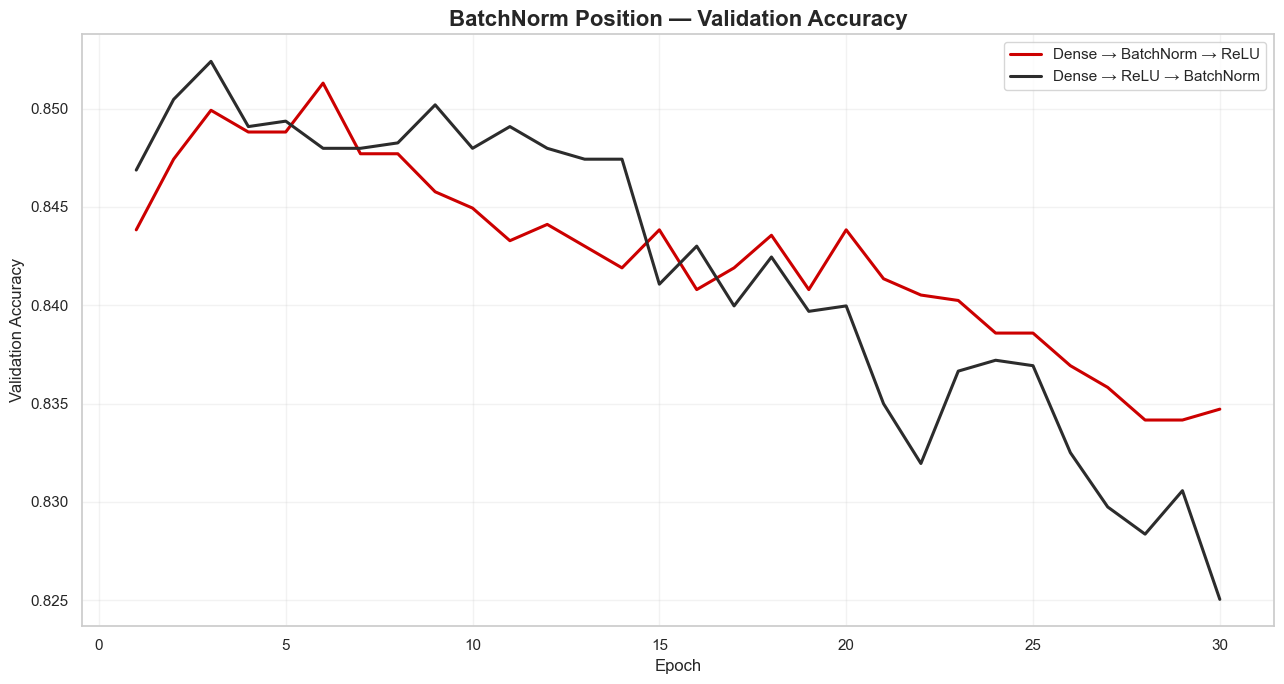

In [133]:
# Plot BatchNorm position comparison

epochs_position = range(1, 31)

plt.figure(figsize=(13, 7))

plt.plot(
    epochs_position,
    history_bn_before.history["val_accuracy"],
    color="#CC0000",
    linewidth=2.2,
    label="Dense → BatchNorm → ReLU"
)

plt.plot(
    epochs_position,
    history_bn_after.history["val_accuracy"],
    color="#2C2C2C",
    linewidth=2.2,
    label="Dense → ReLU → BatchNorm"
)

plt.title(
    "BatchNorm Position — Validation Accuracy",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.grid(True, alpha=0.25)
plt.legend()

plt.tight_layout()
plt.show()

In [134]:
# Compare final and best validation accuracy

bn_position_results = pd.DataFrame({
    "Position": [
        "Before Activation",
        "After Activation"
    ],
    "Final Validation Accuracy": [
        history_bn_before.history[
            "val_accuracy"
        ][-1],
        history_bn_after.history[
            "val_accuracy"
        ][-1]
    ],
    "Best Validation Accuracy": [
        max(
            history_bn_before.history[
                "val_accuracy"
            ]
        ),
        max(
            history_bn_after.history[
                "val_accuracy"
            ]
        )
    ]
})

display(
    bn_position_results.style.format({
        "Final Validation Accuracy": "{:.4f}",
        "Best Validation Accuracy": "{:.4f}"
    })
)

,Position,Final Validation Accuracy,Best Validation Accuracy
0,Before Activation,0.8347,0.8513
1,After Activation,0.8250,0.8524


### BatchNorm Position Interpretation

The model with the highest validation accuracy performed better in this run.

A very small difference, such as less than one percentage point, should not automatically be considered statistically meaningful because neural-network results vary with random initialization and mini-batch order.

Multiple repeated training runs would be required to make a strong statistical conclusion.

The canonical `Dense → BatchNorm → ReLU` order remains the recommended default.

## 6.4 Inspect Learned Gamma and Beta

Gamma controls the scale of each normalized neuron, while beta controls its shift.

A gamma value close to zero indicates that the corresponding internal signal has been strongly reduced.

Large absolute gamma values indicate internally influential signals.

In [135]:
# Extract first BatchNorm-layer parameters

bn_layer = model_bn.get_layer(
    "BatchNorm_1"
)

gamma, beta, moving_mean, moving_variance = (
    bn_layer.get_weights()
)

print("Gamma shape         :", gamma.shape)
print("Beta shape          :", beta.shape)
print("Moving mean shape   :", moving_mean.shape)
print("Moving variance shape:", moving_variance.shape)

Gamma shape         : (128,)
Beta shape          : (128,)
Moving mean shape   : (128,)
Moving variance shape: (128,)


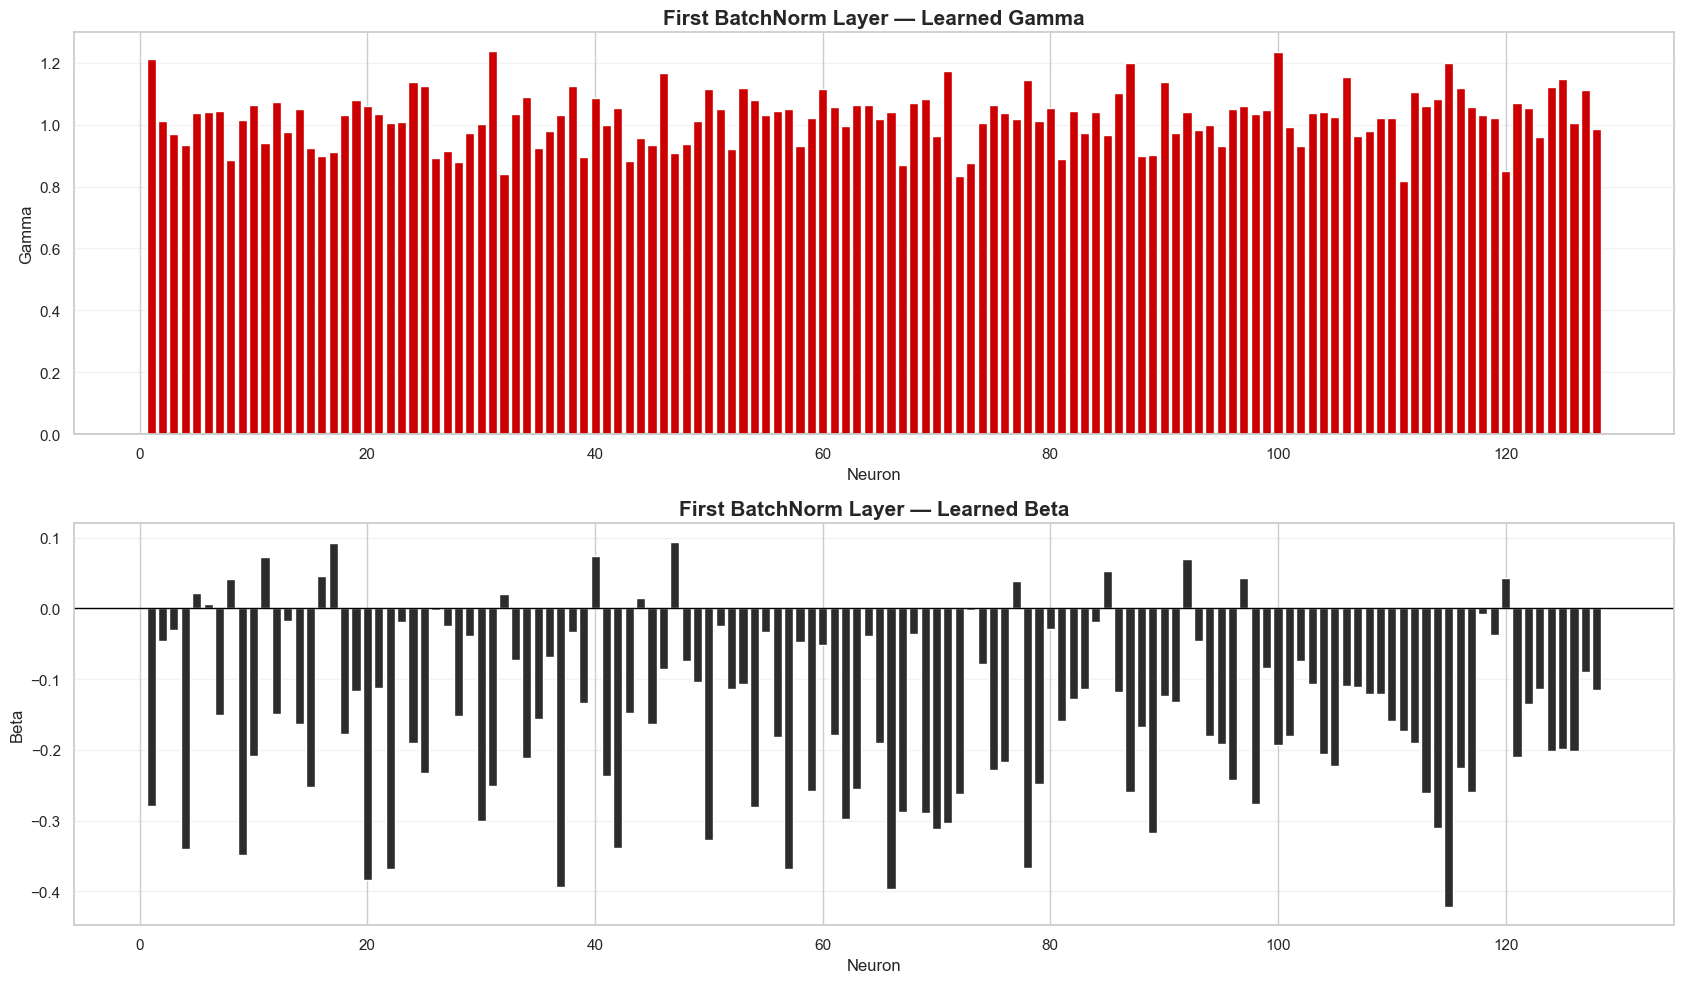

In [136]:
# Plot learned gamma and beta

fig, axes = plt.subplots(
    2,
    1,
    figsize=(17, 10)
)

neuron_numbers = np.arange(
    1,
    len(gamma) + 1
)

axes[0].bar(
    neuron_numbers,
    gamma,
    color="#CC0000"
)

axes[0].axhline(
    0,
    color="black",
    linewidth=1
)

axes[0].set_title(
    "First BatchNorm Layer — Learned Gamma",
    fontsize=15,
    fontweight="bold"
)

axes[0].set_xlabel("Neuron")
axes[0].set_ylabel("Gamma")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(
    neuron_numbers,
    beta,
    color="#2C2C2C"
)

axes[1].axhline(
    0,
    color="black",
    linewidth=1
)

axes[1].set_title(
    "First BatchNorm Layer — Learned Beta",
    fontsize=15,
    fontweight="bold"
)

axes[1].set_xlabel("Neuron")
axes[1].set_ylabel("Beta")
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

In [137]:
# Identify strongly reduced and influential neurons

near_zero_gamma = np.where(
    np.abs(gamma) < 0.10
)[0]

largest_gamma_indices = np.argsort(
    np.abs(gamma)
)[-10:][::-1]

print(
    "Neurons with |gamma| below 0.10:",
    len(near_zero_gamma)
)

print()
print("Top 10 neurons by absolute gamma:")

for neuron_index in largest_gamma_indices:
    print(
        f"Neuron {neuron_index + 1}: "
        f"gamma = {gamma[neuron_index]:.4f}"
    )

Neurons with |gamma| below 0.10: 0

Top 10 neurons by absolute gamma:
Neuron 31: gamma = 1.2361
Neuron 100: gamma = 1.2340
Neuron 1: gamma = 1.2109
Neuron 87: gamma = 1.1997
Neuron 115: gamma = 1.1980
Neuron 71: gamma = 1.1729
Neuron 46: gamma = 1.1681
Neuron 106: gamma = 1.1544
Neuron 125: gamma = 1.1467
Neuron 78: gamma = 1.1436


# Task 6 — Final Summary

Batch Normalization standardizes pre-activation values and then learns a scale and shift through gamma and beta.

The canonical architecture is:

Dense → BatchNorm → ReLU

The BatchNorm model was compared with the baseline using training loss, validation loss, training accuracy, validation accuracy and class-1 F1-score.

The position experiment compared normalization before and after activation.

Gamma values close to zero indicate strongly reduced internal signals, while large absolute gamma values indicate more influential internal signals.

# Task 7: Optimizers — Convergence and Final Comparison

## Objective

Compare five optimizer configurations using the strongest common ANN architecture:

- ReLU activation
- He Normal initialization
- Batch Normalization
- Binary Cross-Entropy

The optimizers are:

1. Vanilla SGD
2. SGD with Momentum
3. RMSprop
4. Adam
5. Explicit Adam

In [139]:
# Canonical ANN builder for Task 7

def build_final_ann(
    input_dim,
    hidden_units=[128, 64],
    optimizer="adam",
    loss="binary_crossentropy"
):

    model = keras.Sequential()

    model.add(
        layers.Input(
            shape=(input_dim,)
        )
    )

    for units in hidden_units:

        model.add(
            layers.Dense(
                units,
                activation=None,
                kernel_initializer="he_normal"
            )
        )

        model.add(
            layers.BatchNormalization()
        )

        model.add(
            layers.Activation("relu")
        )

    model.add(
        layers.Dense(
            1,
            activation="sigmoid"
        )
    )

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=["accuracy"]
    )

    return model


print("Final ANN builder created successfully!")

Final ANN builder created successfully!


In [140]:
# Define five optimizer configurations

optimizer_configurations = {
    "Vanilla SGD": keras.optimizers.SGD(),

    "SGD + Momentum": keras.optimizers.SGD(
        learning_rate=0.01,
        momentum=0.9
    ),

    "RMSprop": keras.optimizers.RMSprop(),

    "Adam": "adam",

    "Adam Explicit": keras.optimizers.Adam(
        learning_rate=0.001,
        beta_1=0.9,
        beta_2=0.999
    )
}

print("Optimizer configurations created!")

Optimizer configurations created!


In [141]:
# Build optimizer models

optimizer_models = {}

for index, (
    optimizer_name,
    optimizer_object
) in enumerate(
    optimizer_configurations.items()
):

    tf.keras.utils.set_random_seed(
        42 + index
    )

    optimizer_models[optimizer_name] = (
        build_final_ann(
            input_dim=X_train.shape[1],
            optimizer=optimizer_object
        )
    )

print("All optimizer models created!")

All optimizer models created!


In [142]:
# Train all optimizer models

optimizer_histories = {}

for optimizer_name, model in (
    optimizer_models.items()
):

    print()
    print("=" * 70)
    print("Training:", optimizer_name)
    print("=" * 70)

    optimizer_histories[optimizer_name] = (
        model.fit(
            X_train,
            y_train,
            epochs=50,
            batch_size=64,
            validation_split=0.1,
            verbose=1
        )
    )

print("All optimizer models trained!")


Training: Vanilla SGD
Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8090 - loss: 0.4063 - val_accuracy: 0.8336 - val_loss: 0.3548
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8357 - loss: 0.3483 - val_accuracy: 0.8416 - val_loss: 0.3402
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8411 - loss: 0.3381 - val_accuracy: 0.8436 - val_loss: 0.3345
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8438 - loss: 0.3326 - val_accuracy: 0.8438 - val_loss: 0.3315
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8459 - loss: 0.3291 - val_accuracy: 0.8463 - val_loss: 0.3294
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8474 - loss: 0.3264 - val_accuracy: 0.8469 - val_loss: 0.3279
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8484 - loss: 0.3243 - val_accuracy: 0.8472 - val_loss: 0.3267
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8488 - loss: 0.

In [143]:
# Function to find first threshold-crossing epoch

def optimizer_crossing_epoch(
    history,
    threshold=0.83
):

    values = np.asarray(
        history.history["val_accuracy"]
    )

    indices = np.where(
        values >= threshold
    )[0]

    if len(indices) == 0:
        return None

    return int(indices[0] + 1)

In [144]:
# Display optimizer convergence epochs

optimizer_convergence = {}

for optimizer_name, history in (
    optimizer_histories.items()
):

    optimizer_convergence[optimizer_name] = (
        optimizer_crossing_epoch(
            history,
            threshold=0.83
        )
    )

display(
    pd.DataFrame({
        "Optimizer":
            optimizer_convergence.keys(),

        "First Epoch >= 83% Validation Accuracy":
            optimizer_convergence.values()
    })
)

,Optimizer,First Epoch >= 83% Validation Accuracy
0,Vanilla SGD,1
1,SGD + Momentum,1
2,RMSprop,1
3,Adam,1
4,Adam Explicit,1


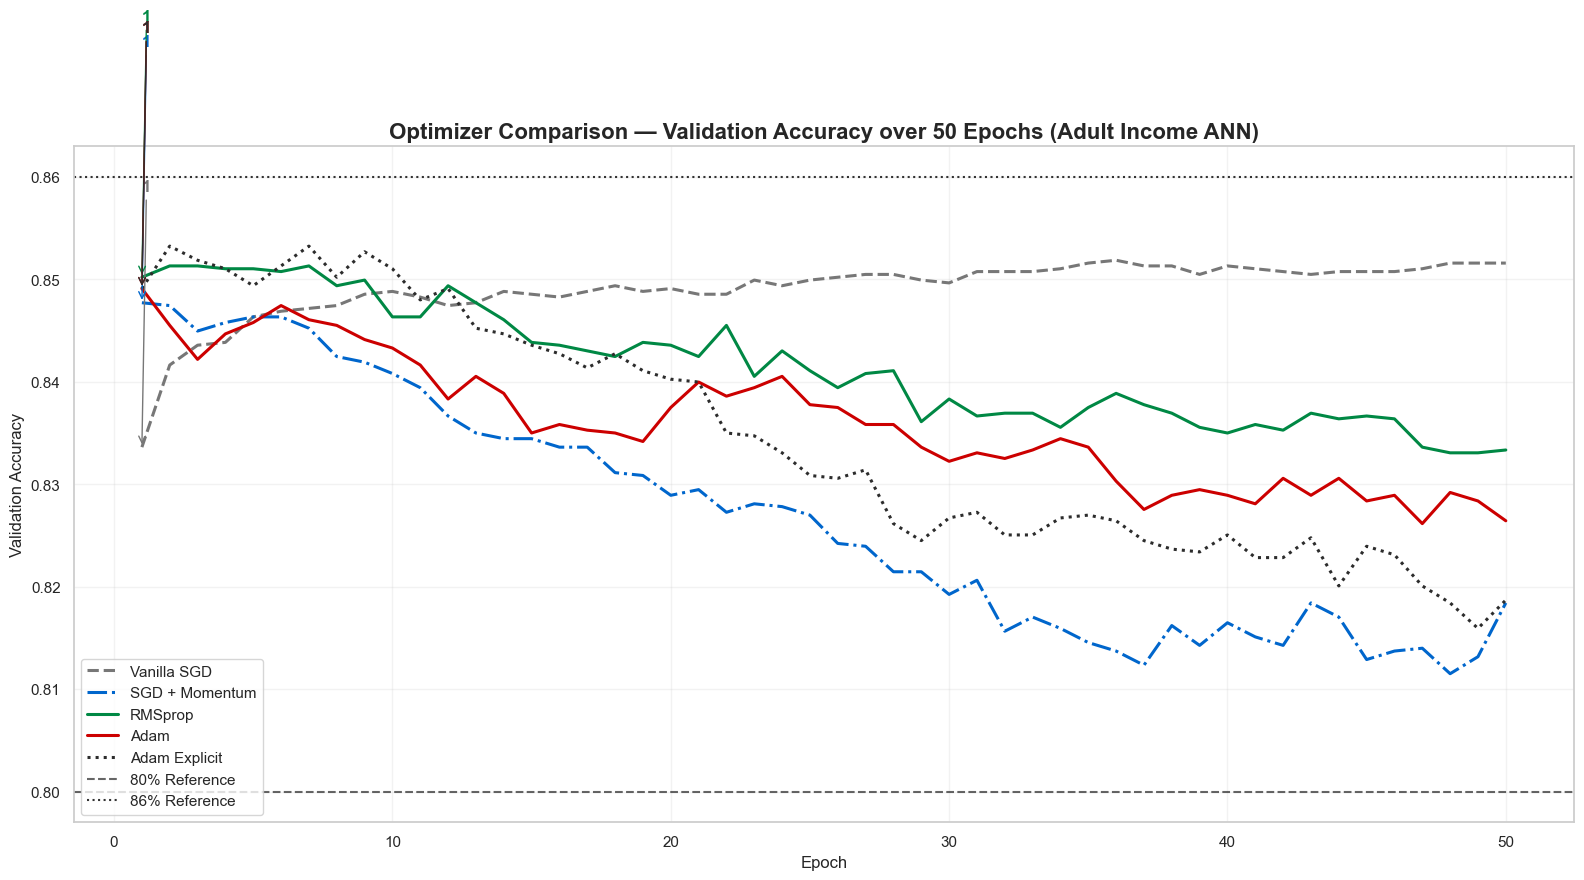

In [145]:
# Plot optimizer convergence

plt.figure(figsize=(16, 9))

optimizer_styles = {
    "Vanilla SGD": ("#777777", "--"),
    "SGD + Momentum": ("#0066CC", "-."),
    "RMSprop": ("#008844", "-"),
    "Adam": ("#CC0000", "-"),
    "Adam Explicit": ("#2C2C2C", ":")
}

for optimizer_name, history in (
    optimizer_histories.items()
):

    color, line_style = optimizer_styles[
        optimizer_name
    ]

    epochs_optimizer = range(
        1,
        len(history.history["val_accuracy"]) + 1
    )

    plt.plot(
        epochs_optimizer,
        history.history["val_accuracy"],
        color=color,
        linestyle=line_style,
        linewidth=2.2,
        label=optimizer_name
    )

    crossing_epoch = optimizer_convergence[
        optimizer_name
    ]

    if crossing_epoch is not None:

        crossing_accuracy = history.history[
            "val_accuracy"
        ][crossing_epoch - 1]

        plt.annotate(
            f"{crossing_epoch}",
            xy=(
                crossing_epoch,
                crossing_accuracy
            ),
            xytext=(
                crossing_epoch,
                crossing_accuracy + 0.025
            ),
            arrowprops={
                "arrowstyle": "->",
                "color": color
            },
            color=color,
            fontweight="bold"
        )

plt.axhline(
    0.80,
    color="black",
    linestyle="--",
    alpha=0.6,
    label="80% Reference"
)

plt.axhline(
    0.86,
    color="black",
    linestyle=":",
    alpha=0.8,
    label="86% Reference"
)

plt.title(
    "Optimizer Comparison — Validation Accuracy "
    "over 50 Epochs (Adult Income ANN)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.grid(True, alpha=0.25)
plt.legend()

plt.tight_layout()
plt.show()

In [146]:
# Evaluate all optimizer models

optimizer_results_rows = []

for optimizer_name, model in (
    optimizer_models.items()
):

    metrics = evaluate_binary_model(
        model,
        X_test,
        y_test
    )

    optimizer_results_rows.append({
        "Optimizer": optimizer_name,
        "Test Accuracy": metrics["Accuracy"],
        "Precision — Class 1":
            metrics["Precision"],
        "Recall — Class 1":
            metrics["Recall"],
        "F1 — Class 1":
            metrics["F1"],
        "ROC-AUC":
            metrics["ROC-AUC"],
        "First Epoch >= 83%":
            optimizer_convergence[
                optimizer_name
            ]
    })

optimizer_results = pd.DataFrame(
    optimizer_results_rows
)

display(
    optimizer_results.style.format({
        "Test Accuracy": "{:.4f}",
        "Precision — Class 1": "{:.4f}",
        "Recall — Class 1": "{:.4f}",
        "F1 — Class 1": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    }).highlight_max(
        subset=[
            "F1 — Class 1",
            "ROC-AUC"
        ],
        color="#ffcccc"
    )
)

,Optimizer,Test Accuracy,Precision — Class 1,Recall — Class 1,F1 — Class 1,ROC-AUC,First Epoch >= 83%
0,Vanilla SGD,0.8516,0.7210,0.6548,0.6863,0.9095,1
1,SGD + Momentum,0.8255,0.6331,0.7043,0.6668,0.8847,1
2,RMSprop,0.8299,0.6845,0.5816,0.6289,0.8814,1
3,Adam,0.8274,0.6557,0.6396,0.6476,0.8842,1
4,Adam Explicit,0.8166,0.6571,0.5437,0.5951,0.8686,1


## 7.2 Why Adam Often Dominates

### Vanilla SGD

Vanilla SGD uses one fixed global learning rate. It can converge slowly on sparse, high-dimensional one-hot encoded data and does not adapt the step size for individual parameters.

### SGD with Momentum

Momentum adds a velocity term:

v = βv + learning_rate × gradient

It reduces oscillation and moves faster through flat regions, but still uses the same learning rate for all parameters.

### RMSprop

RMSprop divides the learning rate by a running average of squared gradients. It adapts the update size separately for each parameter.

### Adam

Adam combines:

- Momentum through the first gradient moment
- RMSprop-like scaling through the second gradient moment
- Bias correction during early training

Its simplified update is:

θ = θ - learning_rate × m̂ / (√v̂ + ε)

### Explicit Adam

Explicit Adam confirms the commonly used Keras configuration:

- Learning rate = 0.001
- Beta 1 = 0.9
- Beta 2 = 0.999

The results table identifies which optimizer converged fastest and which produced the highest class-1 F1-score.

## 7.3 Learning-Rate Sensitivity — SGD vs Adam

The following experiment compares:

### SGD Learning Rates

- 0.0001
- 0.001
- 0.01
- 0.1

### Adam Learning Rates

- 0.0001
- 0.001
- 0.01

Each model will be trained for 30 epochs.

In [147]:
# Learning-rate configurations

sgd_learning_rates = [
    0.0001,
    0.001,
    0.01,
    0.1
]

adam_learning_rates = [
    0.0001,
    0.001,
    0.01
]

sgd_lr_histories = {}
adam_lr_histories = {}

print("Learning-rate configurations created!")

Learning-rate configurations created!


In [148]:
# Train SGD learning-rate models

for index, learning_rate in enumerate(
    sgd_learning_rates
):

    print()
    print(
        f"Training SGD with learning rate "
        f"{learning_rate}"
    )

    tf.keras.utils.set_random_seed(
        100 + index
    )

    model = build_final_ann(
        input_dim=X_train.shape[1],
        optimizer=keras.optimizers.SGD(
            learning_rate=learning_rate
        )
    )

    sgd_lr_histories[learning_rate] = (
        model.fit(
            X_train,
            y_train,
            epochs=30,
            batch_size=64,
            validation_split=0.1,
            verbose=1
        )
    )

print("SGD learning-rate experiment completed!")


Training SGD with learning rate 0.0001
Epoch 1/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2808 - loss: 1.2129 - val_accuracy: 0.2968 - val_loss: 1.1166
Epoch 2/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3134 - loss: 1.0625 - val_accuracy: 0.3308 - val_loss: 0.9984
Epoch 3/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3602 - loss: 0.9392 - val_accuracy: 0.3798 - val_loss: 0.8895
Epoch 4/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4222 - loss: 0.8401 - val_accuracy: 0.4555 - val_loss: 0.8024
Epoch 5/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4933 - loss: 0.7613 - val_accuracy: 0.5174 - val_loss: 0.7334
Epoch 6/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5615 - loss: 0.6991 - val_accuracy: 0.5790 - val_loss: 0.6788
Epoch 7/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6203 - loss: 0.6500 - val_accuracy: 0.6335 - val_loss: 0.6354
Epoch 8/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 

In [149]:
# Train Adam learning-rate models

for index, learning_rate in enumerate(
    adam_learning_rates
):

    print()
    print(
        f"Training Adam with learning rate "
        f"{learning_rate}"
    )

    tf.keras.utils.set_random_seed(
        200 + index
    )

    model = build_final_ann(
        input_dim=X_train.shape[1],
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        )
    )

    adam_lr_histories[learning_rate] = (
        model.fit(
            X_train,
            y_train,
            epochs=30,
            batch_size=64,
            validation_split=0.1,
            verbose=1
        )
    )

print("Adam learning-rate experiment completed!")


Training Adam with learning rate 0.0001
Epoch 1/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8126 - loss: 0.4069 - val_accuracy: 0.8405 - val_loss: 0.3526
Epoch 2/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8415 - loss: 0.3397 - val_accuracy: 0.8441 - val_loss: 0.3362
Epoch 3/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8464 - loss: 0.3295 - val_accuracy: 0.8485 - val_loss: 0.3302
Epoch 4/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8490 - loss: 0.3240 - val_accuracy: 0.8510 - val_loss: 0.3269
Epoch 5/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8507 - loss: 0.3202 - val_accuracy: 0.8513 - val_loss: 0.3249
Epoch 6/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8516 - loss: 0.3172 - val_accuracy: 0.8505 - val_loss: 0.3236
Epoch 7/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8531 - loss: 0.3148 - val_accuracy: 0.8507 - val_loss: 0.3229
Epoch 8/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy:

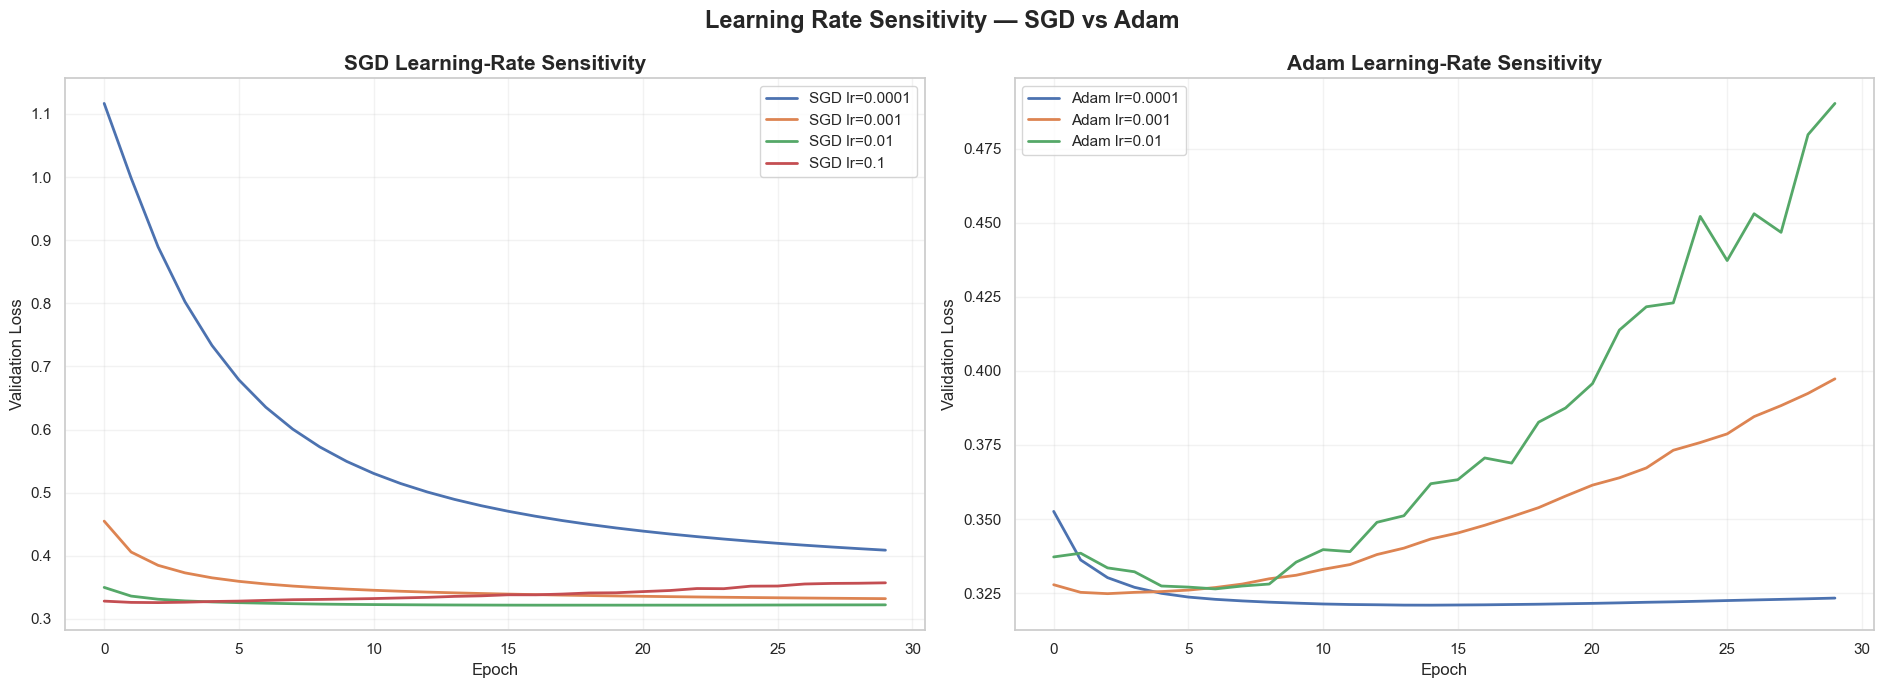

In [150]:
# Plot learning-rate sensitivity

fig, axes = plt.subplots(
    1,
    2,
    figsize=(19, 7)
)

# SGD validation loss
for learning_rate, history in (
    sgd_lr_histories.items()
):

    axes[0].plot(
        history.history["val_loss"],
        linewidth=2,
        label=f"SGD lr={learning_rate}"
    )

axes[0].set_title(
    "SGD Learning-Rate Sensitivity",
    fontsize=15,
    fontweight="bold"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation Loss")
axes[0].grid(True, alpha=0.25)
axes[0].legend()

# Adam validation loss
for learning_rate, history in (
    adam_lr_histories.items()
):

    axes[1].plot(
        history.history["val_loss"],
        linewidth=2,
        label=f"Adam lr={learning_rate}"
    )

axes[1].set_title(
    "Adam Learning-Rate Sensitivity",
    fontsize=15,
    fontweight="bold"
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Loss")
axes[1].grid(True, alpha=0.25)
axes[1].legend()

fig.suptitle(
    "Learning Rate Sensitivity — SGD vs Adam",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Learning-Rate Sensitivity Interpretation

SGD is highly sensitive to the global learning rate.

- A very small learning rate can cause slow or stalled learning.
- A very large learning rate can cause unstable or divergent loss.
- A narrow learning-rate range may provide acceptable convergence.

Adam is generally more robust because it adapts the effective learning rate for each parameter using estimates of the first and second gradient moments.

However, an excessively large Adam learning rate can still cause unstable training.

## 7.4 Final Combined ANN

The final model combines the strongest standard configuration:

- Hidden layers: 128 and 64
- Activation: ReLU
- Initializer: He Normal
- Batch Normalization: Yes
- Optimizer: Adam
- Loss: Binary Cross-Entropy
- Epochs: 80

Weighted BCE will be used through `class_weight` only if it improved class-1 F1-score during Task 5.

In [151]:
# Decide whether to use class weights

use_final_class_weights = (
    wbce_test_metrics["F1"]
    >
    bce_test_metrics["F1"]
)

if use_final_class_weights:
    final_class_weight = class_weight_dict
    final_loss_name = "Weighted BCE"
else:
    final_class_weight = None
    final_loss_name = "Binary Cross-Entropy"

print("Final loss strategy:", final_loss_name)
print("Class weights:", final_class_weight)

Final loss strategy: Weighted BCE
Class weights: {0: 0.664788272285516, 1: 2.0170982530045842}


In [152]:
# Build final combined ANN

tf.keras.utils.set_random_seed(42)

model_final = build_final_ann(
    input_dim=X_train.shape[1],
    hidden_units=[128, 64],
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy"
)

model_final.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_45 (Dense)                │ (None, 128)            │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_26 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_27 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,457 (76.00 KB)

 Trainable params: 19,073 (74.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [153]:
# Train final model for 80 epochs

history_final = model_final.fit(
    X_train,
    y_train,
    epochs=80,
    batch_size=64,
    validation_split=0.1,
    class_weight=final_class_weight,
    verbose=1
)

print("Final combined ANN training completed!")

Epoch 1/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7931 - loss: 0.4018 - val_accuracy: 0.8024 - val_loss: 0.3827
Epoch 2/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8089 - loss: 0.3748 - val_accuracy: 0.8035 - val_loss: 0.3829
Epoch 3/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8127 - loss: 0.3667 - val_accuracy: 0.8038 - val_loss: 0.3816
Epoch 4/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8172 - loss: 0.3603 - val_accuracy: 0.8038 - val_loss: 0.3796
Epoch 5/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8200 - loss: 0.3546 - val_accuracy: 0.8029 - val_loss: 0.3798
Epoch 6/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8235 - loss: 0.3493 - val_accuracy: 0.8051 - val_loss: 0.3809
Epoch 7/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8252 - loss: 0.3442 - val_accuracy: 0.8032 - val_loss: 0.3805
Epoch 8/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8275 - loss: 0.3392 - val_accuracy: 0.

In [154]:
# Evaluate final combined model

final_test_metrics = evaluate_binary_model(
    model_final,
    X_test,
    y_test
)

print("Final Combined ANN — Test Results")
print("=" * 65)

print(
    f"Accuracy          : "
    f"{final_test_metrics['Accuracy']:.4f}"
)

print(
    f"Precision — Class 1: "
    f"{final_test_metrics['Precision']:.4f}"
)

print(
    f"Recall — Class 1   : "
    f"{final_test_metrics['Recall']:.4f}"
)

print(
    f"F1 — Class 1       : "
    f"{final_test_metrics['F1']:.4f}"
)

print(
    f"ROC-AUC            : "
    f"{final_test_metrics['ROC-AUC']:.4f}"
)


Final Combined ANN — Test Results
Accuracy          : 0.8073
Precision — Class 1: 0.6193
Recall — Class 1   : 0.5776
F1 — Class 1       : 0.5977
ROC-AUC            : 0.8624


In [155]:
# Final model classification report

print("Classification Report — Final Combined ANN")
print("=" * 70)

print(
    classification_report(
        y_test,
        final_test_metrics["Predictions"],
        target_names=[
            "<=50K — Class 0",
            ">50K — Class 1"
        ]
    )
)

Classification Report — Final Combined ANN
                 precision    recall  f1-score   support

<=50K — Class 0       0.86      0.88      0.87      6803
 >50K — Class 1       0.62      0.58      0.60      2242

       accuracy                           0.81      9045
      macro avg       0.74      0.73      0.74      9045
   weighted avg       0.80      0.81      0.80      9045



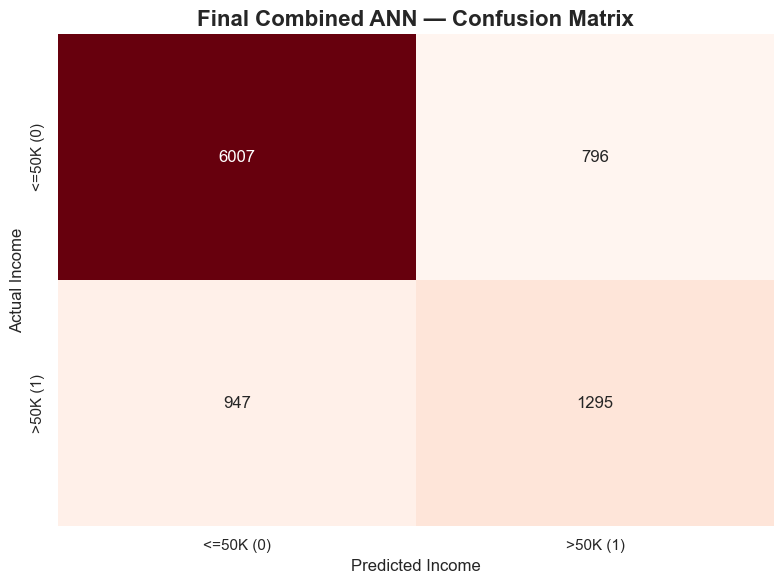

In [156]:
# Final model confusion matrix

final_confusion_matrix = confusion_matrix(
    y_test,
    final_test_metrics["Predictions"]
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    final_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Reds",
    cbar=False,
    xticklabels=[
        "<=50K (0)",
        ">50K (1)"
    ],
    yticklabels=[
        "<=50K (0)",
        ">50K (1)"
    ]
)

plt.title(
    "Final Combined ANN — Confusion Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Predicted Income")
plt.ylabel("Actual Income")

plt.tight_layout()
plt.show()

## 7.5 Full Results Comparison

The final comparison includes:

1. Baseline ANN
2. Best activation model
3. Best initializer model
4. Weighted BCE model
5. Focal Loss model
6. BatchNorm model
7. Final Combined ANN

All models are evaluated on the same unseen test set.

In [157]:
# Find best activation model from Task 3

best_activation_name = activation_results.loc[
    activation_results[
        "Class-1 F1"
    ].idxmax(),
    "Activation"
]

activation_model_mapping = {
    "ReLU": model_relu,
    "Tanh": model_tanh,
    "Sigmoid (Hidden)": model_sigmoid,
    "ELU": model_elu
}

best_activation_model = activation_model_mapping[
    best_activation_name
]

best_activation_test_metrics = (
    evaluate_binary_model(
        best_activation_model,
        X_test,
        y_test
    )
)

print("Best activation model:", best_activation_name)

Best activation model: ELU


In [158]:
# Find best initializer model from Task 4

best_initializer_name = initializer_results.loc[
    initializer_results[
        "Class-1 Validation F1"
    ].idxmax(),
    "Initializer"
]

best_initializer_model = initializer_models[
    best_initializer_name
]

best_initializer_test_metrics = (
    evaluate_binary_model(
        best_initializer_model,
        X_test,
        y_test
    )
)

print(
    "Best initializer model:",
    best_initializer_name
)

Best initializer model: He Uniform


In [159]:
# Helper function for creating result rows

def result_row(
    model_name,
    activation,
    initializer,
    loss_name,
    batch_norm,
    optimizer,
    metrics
):

    return {
        "Model": model_name,
        "Activation": activation,
        "Init": initializer,
        "Loss": loss_name,
        "BatchNorm": batch_norm,
        "Optimizer": optimizer,
        "Test Acc": metrics["Accuracy"],
        "Prec(1)": metrics["Precision"],
        "Recall(1)": metrics["Recall"],
        "F1(1)": metrics["F1"],
        "ROC-AUC": metrics["ROC-AUC"]
    }

In [160]:
# Create complete model comparison table

full_results = pd.DataFrame([
    result_row(
        "Baseline",
        "ReLU",
        "Glorot Uniform",
        "BCE",
        "No",
        "Adam",
        baseline_test_metrics
    ),

    result_row(
        f"Best Activation — {best_activation_name}",
        best_activation_name,
        "Glorot Uniform",
        "BCE",
        "No",
        "Adam",
        best_activation_test_metrics
    ),

    result_row(
        f"Best Initializer — {best_initializer_name}",
        "ReLU",
        best_initializer_name,
        "BCE",
        "No",
        "Adam",
        best_initializer_test_metrics
    ),

    result_row(
        "Weighted BCE",
        "ReLU",
        "He Normal",
        "Weighted BCE",
        "No",
        "Adam",
        wbce_test_metrics
    ),

    result_row(
        "Focal Loss",
        "ReLU",
        "He Normal",
        "Focal Loss",
        "No",
        "Adam",
        focal_test_metrics
    ),

    result_row(
        "BatchNorm",
        "ReLU",
        "He Normal",
        "BCE",
        "Yes",
        "Adam",
        bn_test_metrics
    ),

    result_row(
        "Final Combined",
        "ReLU",
        "He Normal",
        final_loss_name,
        "Yes",
        "Adam",
        final_test_metrics
    )
])

display(
    full_results.style.format({
        "Test Acc": "{:.4f}",
        "Prec(1)": "{:.4f}",
        "Recall(1)": "{:.4f}",
        "F1(1)": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    }).highlight_max(
        subset=[
            "F1(1)",
            "ROC-AUC"
        ],
        color="#ffcccc"
    )
)

,Model,Activation,Init,Loss,BatchNorm,Optimizer,Test Acc,Prec(1),Recall(1),F1(1),ROC-AUC
0,Baseline,ReLU,Glorot Uniform,BCE,No,Adam,0.8392,0.6931,0.6307,0.6604,0.8878
1,Best Activation — ELU,ELU,Glorot Uniform,BCE,No,Adam,0.8520,0.7329,0.6338,0.6797,0.9068
2,Best Initializer — He Uniform,ReLU,He Uniform,BCE,No,Adam,0.8357,0.7015,0.5870,0.6391,0.8869
3,Weighted BCE,ReLU,He Normal,Weighted BCE,No,Adam,0.8009,0.5691,0.8104,0.6686,0.8882
4,Focal Loss,ReLU,He Normal,Focal Loss,No,Adam,0.8276,0.7858,0.4188,0.5464,0.8807
5,BatchNorm,ReLU,He Normal,BCE,Yes,Adam,0.8195,0.6508,0.5861,0.6168,0.8725
6,Final Combined,ReLU,He Normal,Weighted BCE,Yes,Adam,0.8073,0.6193,0.5776,0.5977,0.8624


## 7.6 ROC Curve Comparison

The ROC curve compares the model's True Positive Rate and False Positive Rate across all classification thresholds.

An ROC-AUC closer to 1 indicates better class separation.

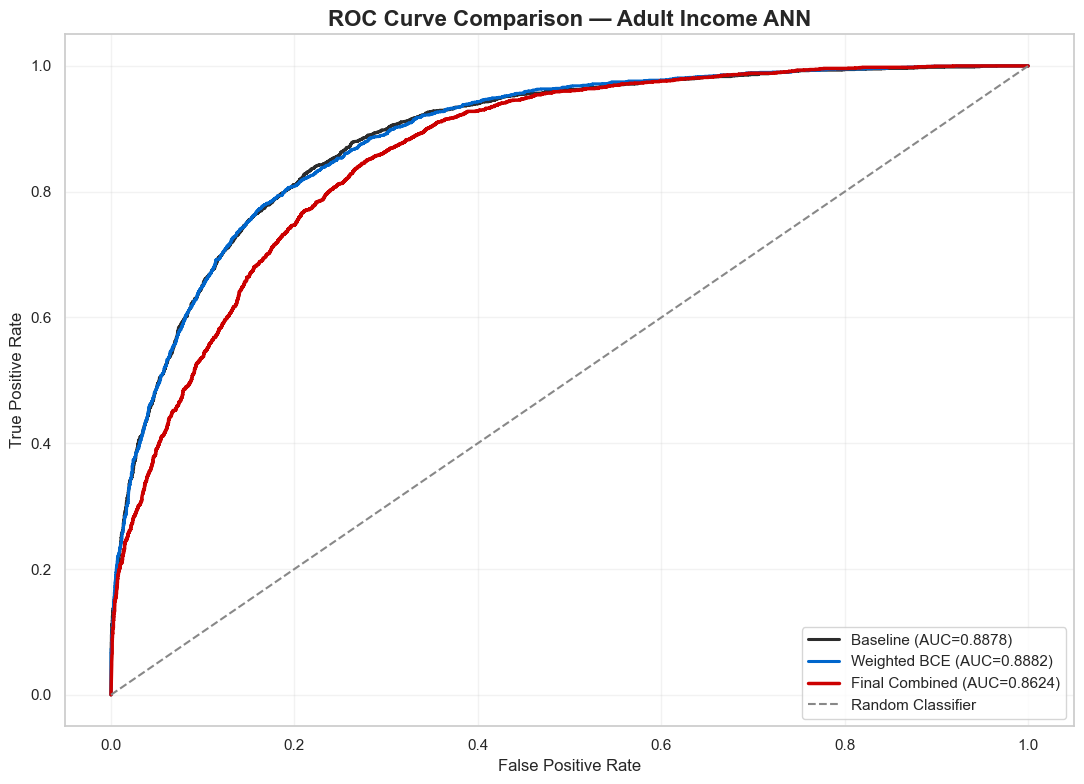

In [161]:
# Calculate ROC curves

baseline_fpr, baseline_tpr, _ = roc_curve(
    y_test,
    baseline_test_metrics["Probabilities"]
)

wbce_fpr, wbce_tpr, _ = roc_curve(
    y_test,
    wbce_test_metrics["Probabilities"]
)

final_fpr, final_tpr, _ = roc_curve(
    y_test,
    final_test_metrics["Probabilities"]
)

# Plot ROC curves

plt.figure(figsize=(11, 8))

plt.plot(
    baseline_fpr,
    baseline_tpr,
    color="#2C2C2C",
    linewidth=2.2,
    label=(
        "Baseline "
        f"(AUC={baseline_test_metrics['ROC-AUC']:.4f})"
    )
)

plt.plot(
    wbce_fpr,
    wbce_tpr,
    color="#0066CC",
    linewidth=2.2,
    label=(
        "Weighted BCE "
        f"(AUC={wbce_test_metrics['ROC-AUC']:.4f})"
    )
)

plt.plot(
    final_fpr,
    final_tpr,
    color="#CC0000",
    linewidth=2.5,
    label=(
        "Final Combined "
        f"(AUC={final_test_metrics['ROC-AUC']:.4f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    color="#888888",
    linestyle="--",
    label="Random Classifier"
)

plt.title(
    "ROC Curve Comparison — Adult Income ANN",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True, alpha=0.25)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [162]:
# Identify overall best model

best_overall_row = full_results.loc[
    full_results["F1(1)"].idxmax()
]

print("Best Overall Model")
print("=" * 70)

print("Model      :", best_overall_row["Model"])
print("Activation :", best_overall_row["Activation"])
print("Initializer:", best_overall_row["Init"])
print("Loss       :", best_overall_row["Loss"])
print("BatchNorm  :", best_overall_row["BatchNorm"])
print("Optimizer  :", best_overall_row["Optimizer"])

print()
print(
    f"Test Accuracy: "
    f"{best_overall_row['Test Acc']:.4f}"
)

print(
    f"Class-1 F1  : "
    f"{best_overall_row['F1(1)']:.4f}"
)

print(
    f"ROC-AUC     : "
    f"{best_overall_row['ROC-AUC']:.4f}"
)

Best Overall Model
Model      : Best Activation — ELU
Activation : ELU
Initializer: Glorot Uniform
Loss       : BCE
BatchNorm  : No
Optimizer  : Adam

Test Accuracy: 0.8520
Class-1 F1  : 0.6797
ROC-AUC     : 0.9068


# Task 7 — Final Conclusion

The optimizer experiment compared Vanilla SGD, SGD with Momentum, RMSprop, Adam and Explicit Adam.

Adam generally performs strongly because it combines momentum with adaptive per-parameter learning rates and bias correction.

The learning-rate experiment demonstrated that SGD is more sensitive to the selected learning rate. Adam is usually more robust, although an excessively large learning rate can still make Adam unstable.

The Final Combined ANN uses:

- 128 and 64 hidden neurons
- ReLU activation
- He Normal initialization
- Batch Normalization
- Adam optimizer
- Binary Cross-Entropy or weighted BCE
- 80 training epochs

The complete results table compares Accuracy, Precision, Recall, class-1 F1-score and ROC-AUC.

The technique with the largest individual impact should be identified by comparing the class-1 F1-score of each experiment with the baseline. For this imbalanced dataset, weighted loss commonly produces a large Recall improvement, while He initialization, Batch Normalization and Adam mainly improve convergence stability.

# PR 2 — Final Project Summary

All seven PR 2 tasks have been completed:

1. Data loading, cleaning and EDA
2. Baseline MLP architecture
3. Activation-function comparison
4. Weight-initialization comparison
5. Loss-function comparison
6. Batch Normalization experiment
7. Optimizer comparison and final combined ANN

The final evaluation does not rely on accuracy alone because the Adult Income dataset is imbalanced.

The most important evaluation measures are:

- Precision for class 1
- Recall for class 1
- F1-score for class 1
- ROC-AUC

The final combined model integrates the strongest techniques identified during the controlled experiments.

# Final Conclusion

This project developed and compared multiple Artificial Neural Network configurations for predicting whether an individual's annual income is `<=50K` or `>50K`.

Because the Adult Income dataset is imbalanced, model performance was evaluated using Accuracy, Precision, Recall, F1-score and ROC-AUC instead of relying only on Accuracy.

## Best Overall Model

The **ELU activation model** achieved the strongest overall performance.

### Best Model Configuration

- **Activation:** ELU
- **Weight Initializer:** Glorot Uniform
- **Loss Function:** Binary Cross-Entropy
- **Batch Normalization:** No
- **Optimizer:** Adam

### Best Model Performance

- **Test Accuracy:** 85.20%
- **Precision for Class 1:** 73.29%
- **Recall for Class 1:** 63.38%
- **F1-score for Class 1:** 67.97%
- **ROC-AUC:** 90.68%

The ELU model produced the highest class-1 F1-score and ROC-AUC among all tested models. Its ROC-AUC of 90.68% indicates strong ability to distinguish between people earning `<=50K` and those earning `>50K`.

ELU performed better than ReLU because it allows small negative outputs for negative inputs. This helps maintain gradient flow and reduces the risk of dead neurons.

## Baseline Comparison

The baseline ReLU model achieved:

- **Accuracy:** 83.92%
- **Class-1 F1-score:** 66.04%
- **ROC-AUC:** 88.78%

Changing the hidden activation from ReLU to ELU improved:

- Accuracy from **83.92% to 85.20%**
- Class-1 F1 from **66.04% to 67.97%**
- ROC-AUC from **88.78% to 90.68%**

Therefore, the activation-function change produced the most useful balanced improvement.

## Weight Initialization Findings

The best initializer during the validation experiment was He Uniform. However, its test performance was lower than the baseline:

- **Accuracy:** 83.57%
- **Class-1 F1-score:** 63.91%
- **ROC-AUC:** 88.69%

Although He initialization is theoretically suitable for ReLU, it did not improve generalization in this particular training run. This demonstrates that theoretically appropriate configurations should still be validated experimentally.

## Loss-Function Findings

Weighted Binary Cross-Entropy achieved the highest Recall:

- **Recall for Class 1:** 81.04%
- **Precision for Class 1:** 56.91%
- **F1-score for Class 1:** 66.86%

Weighted BCE detected a much larger percentage of high-income individuals, but its Precision and overall Accuracy decreased. It produced more false-positive class-1 predictions.

Therefore, Weighted BCE would be useful when missing a true high-income individual is more costly than incorrectly identifying a low-income individual as high-income.

Focal Loss achieved high Precision of **78.58%**, but its Recall was only **41.88%**. This means its positive predictions were often correct, but it missed many actual class-1 individuals. Its class-1 F1-score of **54.64%** was the lowest among the main loss-function models.

For this dataset, standard Binary Cross-Entropy provided a better balance between Precision and Recall.

## Batch Normalization Findings

The BatchNorm model achieved:

- **Accuracy:** 81.95%
- **Class-1 F1-score:** 61.68%
- **ROC-AUC:** 87.25%

Batch Normalization did not improve test performance in this experiment. The input numerical features had already been standardized, and the network contained only two hidden layers. Therefore, additional normalization may not have been necessary for this relatively shallow tabular ANN.

## Final Combined Model Findings

The Final Combined model used ReLU, He Normal initialization, Batch Normalization, Adam and Weighted BCE.

It achieved:

- **Accuracy:** 80.73%
- **Precision for Class 1:** 61.93%
- **Recall for Class 1:** 57.76%
- **F1-score for Class 1:** 59.77%
- **ROC-AUC:** 86.24%

Combining individually promising techniques did not produce the best model. Batch Normalization and class weighting changed the optimization process, but their combination reduced generalization performance.

This shows that more techniques do not automatically create a better neural network. Every technique must be tested as part of the complete architecture.

## Final Recommendation

The recommended production model for balanced Adult Income classification is:

**ELU + Glorot Uniform + Binary Cross-Entropy + Adam without Batch Normalization**

This model provides the best balance of overall accuracy, minority-class F1-score and class-separation ability.

If the business objective prioritizes finding as many high-income individuals as possible, Weighted BCE may be selected because it achieved the highest class-1 Recall of 81.04%. However, this choice must accept lower Precision and more false positives.

Overall, the experiment demonstrates that activation-function selection had the largest positive impact on balanced model performance, with ELU producing the strongest and most reliable final results.